In [ ]:
import os

# --- Local paths: set these env vars, or edit the fallback strings ---
PROJECT_DIR = os.environ.get("PA_FLOOD_PROJECT", r"C:\path\to\PA Flood Risk GIS")
DATA_DIR    = os.environ.get("PA_FLOOD_DATA",    r"C:\path\to\Final Project\Data")

PROJECT_GDB = os.path.join(PROJECT_DIR, "PA Flood Risk GIS.gdb")
OUTPUT_DIR  = PROJECT_DIR


In [1]:
import arcpy
import pandas as pd

panel_layer = "S_FIRM_PAN_WORKING"

panel_fields_wanted = [
    "OBJECTID",
    "DFIRM_ID",
    "VERSION_ID",
    "FIRM_ID",
    "ST_FIPS",
    "PCOMM",
    "PANEL",
    "SUFFIX",
    "FIRM_PAN",
    "PANEL_TYP",
    "PRE_DATE",
    "EFF_DATE",
    "SCALE",
    "PNP_REASON"
]

existing_panel_fields = [field.name for field in arcpy.ListFields(panel_layer)]

panel_fields_use = [
    field for field in panel_fields_wanted
    if field in existing_panel_fields
]

panel_records = []

with arcpy.da.SearchCursor(panel_layer, panel_fields_use) as cursor:
    for row in cursor:
        panel_records.append(dict(zip(panel_fields_use, row)))

panel_df = pd.DataFrame(panel_records)

print("Panel layer:", panel_layer)
print("Number of panel features:", len(panel_df))

print("\nFields found:")
print(panel_fields_use)

print("\nPANEL_TYP counts:")
display(
    panel_df["PANEL_TYP"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={"index": "PANEL_TYP", "PANEL_TYP": "n"})
)

print("\nPRE_DATE counts:")
display(
    panel_df["PRE_DATE"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={"index": "PRE_DATE", "PRE_DATE": "n"})
    .head(20)
)

print("\nEFF_DATE counts:")
display(
    panel_df["EFF_DATE"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={"index": "EFF_DATE", "EFF_DATE": "n"})
    .head(20)
)

print("\nUnique FIRM_ID count:", panel_df["FIRM_ID"].nunique(dropna=True) if "FIRM_ID" in panel_df.columns else "FIRM_ID not found")
print("Unique FIRM_PAN count:", panel_df["FIRM_PAN"].nunique(dropna=True) if "FIRM_PAN" in panel_df.columns else "FIRM_PAN not found")

Panel layer: S_FIRM_PAN_WORKING
Number of panel features: 8355

Fields found:
['OBJECTID', 'DFIRM_ID', 'VERSION_ID', 'FIRM_ID', 'ST_FIPS', 'PCOMM', 'PANEL', 'SUFFIX', 'FIRM_PAN', 'PANEL_TYP', 'PRE_DATE', 'EFF_DATE', 'SCALE', 'PNP_REASON']

PANEL_TYP counts:


,n,count
0,"Countywide, Panel Printed",7679
1,"Countywide, Not Printed",676



PRE_DATE counts:


,n,count
0,9999-09-09 00:00:00,8127
1,2018-08-20 00:00:00,81
2,2017-08-18 00:00:00,73
3,2018-05-16 00:00:00,69
4,2018-09-30 00:00:00,5



EFF_DATE counts:


,n,count
0,2012-01-18 00:00:00,346
1,2012-03-02 00:00:00,293
2,2011-03-17 00:00:00,273
3,2015-12-16 00:00:00,244
4,2016-04-05 00:00:00,239
5,2012-07-03 00:00:00,230
6,2014-09-26 00:00:00,208
7,2016-06-02 00:00:00,197
8,2017-07-18 00:00:00,175
9,2016-03-02 00:00:00,174



Unique FIRM_ID count: 8355
Unique FIRM_PAN count: 8355


In [2]:
import arcpy
import os

# Existing full statewide FIRM panel source
firm_panel_source = "S_FIRM_PAN_WORKING"

# Output name for corrected statewide projected FIRM panel layer
firm_panel_statewide_2272 = "PA_FIRM_Panels_Statewide_2272"

# Use the current project geodatabase
project_gdb = arcpy.env.workspace

# If arcpy.env.workspace is not set, use your project's default geodatabase
if project_gdb is None:
    aprx = arcpy.mp.ArcGISProject("CURRENT")
    project_gdb = aprx.defaultGeodatabase

firm_panel_statewide_2272_path = os.path.join(project_gdb, firm_panel_statewide_2272)

# Pennsylvania StatePlane South, US feet
target_crs = arcpy.SpatialReference(2272)

# Remove old corrected layer if it already exists
if arcpy.Exists(firm_panel_statewide_2272_path):
    arcpy.management.Delete(firm_panel_statewide_2272_path)

# Project full statewide FIRM panel layer
arcpy.management.Project(
    in_dataset=firm_panel_source,
    out_dataset=firm_panel_statewide_2272_path,
    out_coor_system=target_crs
)

print("Created corrected statewide FIRM panel layer:")
print(firm_panel_statewide_2272_path)

print("Feature count:")
print(arcpy.management.GetCount(firm_panel_statewide_2272_path)[0])

Created corrected statewide FIRM panel layer:
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\PA_FIRM_Panels_Statewide_2272
Feature count:
8355


In [3]:
import arcpy
import os

# Inputs
substation_layer = "PA_substations_statewide_clean_2272"
firm_panel_layer = "PA_FIRM_Panels_Statewide_2272"

# Output
substation_firm_join_corrected = "PA_substations_FIRM_panel_join_corrected"

project_gdb = arcpy.env.workspace

if project_gdb is None:
    aprx = arcpy.mp.ArcGISProject("CURRENT")
    project_gdb = aprx.defaultGeodatabase

substation_firm_join_corrected_path = os.path.join(
    project_gdb,
    substation_firm_join_corrected
)

# Delete old corrected output if it already exists
if arcpy.Exists(substation_firm_join_corrected_path):
    arcpy.management.Delete(substation_firm_join_corrected_path)

# Spatial join: each substation gets attributes from the FIRM panel polygon that contains it
arcpy.analysis.SpatialJoin(
    target_features=substation_layer,
    join_features=firm_panel_layer,
    out_feature_class=substation_firm_join_corrected_path,
    join_operation="JOIN_ONE_TO_ONE",
    join_type="KEEP_ALL",
    match_option="INTERSECT"
)

print("Created corrected substation-to-FIRM-panel join:")
print(substation_firm_join_corrected_path)

print("Joined substation count:")
print(arcpy.management.GetCount(substation_firm_join_corrected_path)[0])

Created corrected substation-to-FIRM-panel join:
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\PA_substations_FIRM_panel_join_corrected
Joined substation count:
2333


In [4]:
import arcpy
import pandas as pd

substation_layer = "PA_substations_statewide_clean_2272"
substation_firm_join_corrected = "PA_substations_FIRM_panel_join_corrected"

print("Original substation count:")
print(arcpy.management.GetCount(substation_layer)[0])

print("\nCorrected joined substation count:")
print(arcpy.management.GetCount(substation_firm_join_corrected)[0])

join_fields_wanted = [
    "OBJECTID",
    "Join_Count",
    "TARGET_FID",
    "DFIRM_ID",
    "FIRM_ID",
    "FIRM_PAN",
    "PANEL_TYP",
    "EFF_DATE",
    "PRE_DATE",
    "PNP_REASON"
]

existing_fields = [
    field.name for field in arcpy.ListFields(substation_firm_join_corrected)
]

join_fields_use = [
    field for field in join_fields_wanted
    if field in existing_fields
]

join_records = []

with arcpy.da.SearchCursor(substation_firm_join_corrected, join_fields_use) as cursor:
    for row in cursor:
        join_records.append(dict(zip(join_fields_use, row)))

join_df = pd.DataFrame(join_records)

print("\nFields used:")
print(join_fields_use)

print("\nJoin_Count summary:")
display(join_df["Join_Count"].value_counts(dropna=False).reset_index())

print("\nMissing FIRM_PAN count:")
print(join_df["FIRM_PAN"].isna().sum() if "FIRM_PAN" in join_df.columns else "FIRM_PAN not found")

print("\nMissing FIRM_ID count:")
print(join_df["FIRM_ID"].isna().sum() if "FIRM_ID" in join_df.columns else "FIRM_ID not found")

print("\nPanel type counts among joined substations:")
display(
    join_df["PANEL_TYP"]
    .value_counts(dropna=False)
    .reset_index()
)

Original substation count:
2333

Corrected joined substation count:
2333

Fields used:
['OBJECTID', 'Join_Count', 'TARGET_FID', 'DFIRM_ID', 'FIRM_ID', 'FIRM_PAN', 'PANEL_TYP', 'EFF_DATE', 'PRE_DATE', 'PNP_REASON']

Join_Count summary:


,Join_Count,count
0,1,1641
1,2,559
2,3,114
3,4,9
4,0,9
5,5,1



Missing FIRM_PAN count:
9

Missing FIRM_ID count:
9

Panel type counts among joined substations:


,PANEL_TYP,count
0,"Countywide, Panel Printed",2110
1,"Countywide, Not Printed",214
2,None,9


# FUCK DA FIRMs

In [5]:
import arcpy
import os

# Source FEMA flood hazard area layer
flood_hazard_source = "S_FLD_HAZ_AR"

# Output projected working layer
flood_hazard_2272 = "PA_Flood_Hazard_Areas_2272"

project_gdb = arcpy.env.workspace

if project_gdb is None:
    aprx = arcpy.mp.ArcGISProject("CURRENT")
    project_gdb = aprx.defaultGeodatabase

flood_hazard_2272_path = os.path.join(project_gdb, flood_hazard_2272)

target_crs = arcpy.SpatialReference(2272)

if arcpy.Exists(flood_hazard_2272_path):
    arcpy.management.Delete(flood_hazard_2272_path)

arcpy.management.Project(
    in_dataset=flood_hazard_source,
    out_dataset=flood_hazard_2272_path,
    out_coor_system=target_crs
)

print("Created projected flood hazard layer:")
print(flood_hazard_2272_path)

print("Feature count:")
print(arcpy.management.GetCount(flood_hazard_2272_path)[0])

Created projected flood hazard layer:
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\PA_Flood_Hazard_Areas_2272
Feature count:
108583


In [6]:
import pandas as pd

flood_hazard_2272 = "PA_Flood_Hazard_Areas_2272"

hazard_fields_wanted = [
    "OBJECTID",
    "DFIRM_ID",
    "FLD_AR_ID",
    "STUDY_TYP",
    "FLD_ZONE",
    "ZONE_SUBTY",
    "SFHA_TF",
    "STATIC_BFE",
    "V_DATUM"
]

existing_hazard_fields = [
    field.name for field in arcpy.ListFields(flood_hazard_2272)
]

hazard_fields_use = [
    field for field in hazard_fields_wanted
    if field in existing_hazard_fields
]

hazard_records = []

with arcpy.da.SearchCursor(flood_hazard_2272, hazard_fields_use) as cursor:
    for row in cursor:
        hazard_records.append(dict(zip(hazard_fields_use, row)))

hazard_df = pd.DataFrame(hazard_records)

print("Flood hazard feature count:")
print(len(hazard_df))

print("\nFields used:")
print(hazard_fields_use)

print("\nFLD_ZONE counts:")
display(
    hazard_df["FLD_ZONE"]
    .value_counts(dropna=False)
    .reset_index()
)

print("\nSFHA_TF counts:")
display(
    hazard_df["SFHA_TF"]
    .value_counts(dropna=False)
    .reset_index()
)

print("\nZONE_SUBTY counts:")
display(
    hazard_df["ZONE_SUBTY"]
    .value_counts(dropna=False)
    .reset_index()
    .head(25)
)

Flood hazard feature count:
108583

Fields used:
['OBJECTID', 'DFIRM_ID', 'FLD_AR_ID', 'STUDY_TYP', 'FLD_ZONE', 'ZONE_SUBTY', 'SFHA_TF', 'STATIC_BFE', 'V_DATUM']

FLD_ZONE counts:


,FLD_ZONE,count
0,X,55671
1,AE,39063
2,A,13653
3,AH,76
4,VE,58
5,AO,45
6,AREA NOT INCLUDED,10
7,OPEN WATER,4
8,A99,3



SFHA_TF counts:


,SFHA_TF,count
0,F,55685
1,T,52898



ZONE_SUBTY counts:


,ZONE_SUBTY,count
0,None,51134
1,0.2 PCT ANNUAL CHANCE FLOOD HAZARD,43503
2,AREA OF MINIMAL FLOOD HAZARD,12000
3,FLOODWAY,1767
4,AREA WITH REDUCED FLOOD RISK DUE TO LEVEE,126
5,1 PCT DRAINAGE AREA LESS THAN 1 SQUARE MILE,33
6,1 PCT DEPTH LESS THAN 1 FOOT,9
7,RIVERINE FLOODWAY SHOWN IN COASTAL ZONE,6
8,1 PCT ANNUAL CHANCE FLOOD HAZARD CONTAINED IN ...,5


In [7]:
import arcpy
import os

# Inputs
substation_layer = "PA_substations_statewide_clean_2272"
flood_hazard_layer = "PA_Flood_Hazard_Areas_2272"

# Output
substation_flood_hazard_join = "PA_substations_flood_hazard_join"

project_gdb = arcpy.env.workspace

if project_gdb is None:
    aprx = arcpy.mp.ArcGISProject("CURRENT")
    project_gdb = aprx.defaultGeodatabase

substation_flood_hazard_join_path = os.path.join(
    project_gdb,
    substation_flood_hazard_join
)

# Delete old output if it exists
if arcpy.Exists(substation_flood_hazard_join_path):
    arcpy.management.Delete(substation_flood_hazard_join_path)

# Spatial join: each substation receives attributes from intersecting flood hazard polygon(s)
arcpy.analysis.SpatialJoin(
    target_features=substation_layer,
    join_features=flood_hazard_layer,
    out_feature_class=substation_flood_hazard_join_path,
    join_operation="JOIN_ONE_TO_ONE",
    join_type="KEEP_ALL",
    match_option="INTERSECT"
)

print("Created substation-to-flood-hazard join:")
print(substation_flood_hazard_join_path)

print("Joined substation count:")
print(arcpy.management.GetCount(substation_flood_hazard_join_path)[0])

Created substation-to-flood-hazard join:
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\PA_substations_flood_hazard_join
Joined substation count:
2333


In [1]:
import arcpy
import pandas as pd

substation_flood_hazard_join = "PA_substations_flood_hazard_join"

flood_join_fields_wanted = [
    "OBJECTID",
    "Join_Count",
    "TARGET_FID",
    "DFIRM_ID",
    "FLD_AR_ID",
    "STUDY_TYP",
    "FLD_ZONE",
    "ZONE_SUBTY",
    "SFHA_TF",
    "STATIC_BFE",
    "V_DATUM"
]

existing_flood_join_fields = [
    field.name for field in arcpy.ListFields(substation_flood_hazard_join)
]

flood_join_fields_use = [
    field for field in flood_join_fields_wanted
    if field in existing_flood_join_fields
]

flood_join_records = []

with arcpy.da.SearchCursor(substation_flood_hazard_join, flood_join_fields_use) as cursor:
    for row in cursor:
        flood_join_records.append(dict(zip(flood_join_fields_use, row)))

flood_join_df = pd.DataFrame(flood_join_records)

print("Joined substation count:")
print(len(flood_join_df))

print("\nFields used:")
print(flood_join_fields_use)

print("\nJoin_Count summary:")
display(
    flood_join_df["Join_Count"]
    .value_counts(dropna=False)
    .reset_index()
)

print("\nSFHA_TF counts:")
display(
    flood_join_df["SFHA_TF"]
    .value_counts(dropna=False)
    .reset_index()
)

print("\nFLD_ZONE counts:")
display(
    flood_join_df["FLD_ZONE"]
    .value_counts(dropna=False)
    .reset_index()
)

print("\nZONE_SUBTY counts:")
display(
    flood_join_df["ZONE_SUBTY"]
    .value_counts(dropna=False)
    .reset_index()
)

Joined substation count:
2333

Fields used:
['OBJECTID', 'Join_Count', 'TARGET_FID', 'DFIRM_ID', 'FLD_AR_ID', 'STUDY_TYP', 'FLD_ZONE', 'ZONE_SUBTY', 'SFHA_TF', 'STATIC_BFE', 'V_DATUM']

Join_Count summary:


,Join_Count,count
0,1,2329
1,2,4



SFHA_TF counts:


,SFHA_TF,count
0,F,2161
1,T,172



FLD_ZONE counts:


,FLD_ZONE,count
0,X,2156
1,AE,137
2,A,34
3,AREA NOT INCLUDED,5
4,AO,1



ZONE_SUBTY counts:


,ZONE_SUBTY,count
0,AREA OF MINIMAL FLOOD HAZARD,2042
1,None,152
2,0.2 PCT ANNUAL CHANCE FLOOD HAZARD,104
3,FLOODWAY,21
4,AREA WITH REDUCED FLOOD RISK DUE TO LEVEE,14


In [2]:
import arcpy
import os
import pandas as pd

substation_layer = "PA_substations_statewide_clean_2272"
flood_hazard_layer = "PA_Flood_Hazard_Areas_2272"
substation_flood_hazard_join = "PA_substations_flood_hazard_join"

project_gdb = arcpy.env.workspace

if project_gdb is None:
    aprx = arcpy.mp.ArcGISProject("CURRENT")
    project_gdb = aprx.defaultGeodatabase

# -----------------------------
# 1. Inspect the current one-to-one assignments for Join_Count = 2
# -----------------------------

current_fields_wanted = [
    "OBJECTID",
    "TARGET_FID",
    "Join_Count",
    "FLD_ZONE",
    "ZONE_SUBTY",
    "SFHA_TF",
    "FLD_AR_ID",
    "STATIC_BFE",
    "V_DATUM"
]

existing_current_fields = [
    field.name for field in arcpy.ListFields(substation_flood_hazard_join)
]

current_fields_use = [
    field for field in current_fields_wanted
    if field in existing_current_fields
]

boundary_records = []

where_clause = "Join_Count = 2"

with arcpy.da.SearchCursor(
    substation_flood_hazard_join,
    current_fields_use,
    where_clause
) as cursor:
    for row in cursor:
        boundary_records.append(dict(zip(current_fields_use, row)))

boundary_df = pd.DataFrame(boundary_records)

print("Current one-to-one assignments for substations with Join_Count = 2:")
display(boundary_df)


# -----------------------------
# 2. Create a temporary one-to-many join to reveal both polygons
# -----------------------------

one_to_many_output = "temp_substations_flood_hazard_join_one_to_many"
one_to_many_output_path = os.path.join(project_gdb, one_to_many_output)

if arcpy.Exists(one_to_many_output_path):
    arcpy.management.Delete(one_to_many_output_path)

arcpy.analysis.SpatialJoin(
    target_features=substation_layer,
    join_features=flood_hazard_layer,
    out_feature_class=one_to_many_output_path,
    join_operation="JOIN_ONE_TO_MANY",
    join_type="KEEP_ALL",
    match_option="INTERSECT"
)

print("\nCreated temporary one-to-many join:")
print(one_to_many_output_path)

# -----------------------------
# 3. Pull all candidate polygons for the same TARGET_FID values
# -----------------------------

target_fids = sorted(boundary_df["TARGET_FID"].dropna().astype(int).unique().tolist())

candidate_fields_wanted = [
    "OBJECTID",
    "TARGET_FID",
    "Join_Count",
    "DFIRM_ID",
    "FLD_AR_ID",
    "FLD_ZONE",
    "ZONE_SUBTY",
    "SFHA_TF",
    "STATIC_BFE",
    "V_DATUM"
]

existing_candidate_fields = [
    field.name for field in arcpy.ListFields(one_to_many_output_path)
]

candidate_fields_use = [
    field for field in candidate_fields_wanted
    if field in existing_candidate_fields
]

candidate_records = []

if len(target_fids) > 0:
    target_fid_text = ",".join(str(fid) for fid in target_fids)
    candidate_where_clause = f"TARGET_FID IN ({target_fid_text})"

    with arcpy.da.SearchCursor(
        one_to_many_output_path,
        candidate_fields_use,
        candidate_where_clause
    ) as cursor:
        for row in cursor:
            candidate_records.append(dict(zip(candidate_fields_use, row)))

candidate_df = pd.DataFrame(candidate_records)

print("\nAll intersecting flood hazard polygons for those substations:")
display(
    candidate_df.sort_values(
        by=["TARGET_FID", "SFHA_TF", "FLD_ZONE", "ZONE_SUBTY"],
        ascending=[True, False, True, True]
    )
)

Current one-to-one assignments for substations with Join_Count = 2:


,OBJECTID,TARGET_FID,Join_Count,FLD_ZONE,ZONE_SUBTY,SFHA_TF,FLD_AR_ID,STATIC_BFE,V_DATUM
0,1415,1415,2,AREA NOT INCLUDED,AREA OF MINIMAL FLOOD HAZARD,F,42077C_699,-9999.0,None
1,1416,1416,2,AREA NOT INCLUDED,AREA OF MINIMAL FLOOD HAZARD,F,42077C_699,-9999.0,None
2,1428,1428,2,AREA NOT INCLUDED,AREA OF MINIMAL FLOOD HAZARD,F,42077C_699,-9999.0,None
3,2161,2161,2,AREA NOT INCLUDED,AREA OF MINIMAL FLOOD HAZARD,F,42125C_1295,-9999.0,



Created temporary one-to-many join:
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\temp_substations_flood_hazard_join_one_to_many

All intersecting flood hazard polygons for those substations:


,OBJECTID,TARGET_FID,Join_Count,DFIRM_ID,FLD_AR_ID,FLD_ZONE,ZONE_SUBTY,SFHA_TF,STATIC_BFE,V_DATUM
0,1415,1415,1,42077C,42077C_699,AREA NOT INCLUDED,None,F,-9999.0,None
1,1416,1415,1,42095C,42095C_1157,X,AREA OF MINIMAL FLOOD HAZARD,F,-9999.0,None
2,1417,1416,1,42077C,42077C_699,AREA NOT INCLUDED,None,F,-9999.0,None
3,1418,1416,1,42095C,42095C_1157,X,AREA OF MINIMAL FLOOD HAZARD,F,-9999.0,None
4,1430,1428,1,42077C,42077C_699,AREA NOT INCLUDED,None,F,-9999.0,None
5,1431,1428,1,42095C,42095C_1157,X,AREA OF MINIMAL FLOOD HAZARD,F,-9999.0,None
6,2164,2161,1,42125C,42125C_1295,AREA NOT INCLUDED,None,F,-9999.0,
7,2165,2161,1,42003C,42003C_8040,X,AREA OF MINIMAL FLOOD HAZARD,F,-9999.0,


In [3]:
one_to_many_output_path = os.path.join(
    project_gdb,
    "temp_substations_flood_hazard_join_one_to_many"
)

target_fids = [1415, 1416, 1428, 2161]

candidate_fields_wanted = [
    "OBJECTID",
    "TARGET_FID",
    "DFIRM_ID",
    "FLD_AR_ID",
    "FLD_ZONE",
    "ZONE_SUBTY",
    "SFHA_TF",
    "STATIC_BFE",
    "V_DATUM"
]

existing_candidate_fields = [
    field.name for field in arcpy.ListFields(one_to_many_output_path)
]

candidate_fields_use = [
    field for field in candidate_fields_wanted
    if field in existing_candidate_fields
]

candidate_records = []

target_fid_text = ",".join(str(fid) for fid in target_fids)
candidate_where_clause = f"TARGET_FID IN ({target_fid_text})"

with arcpy.da.SearchCursor(
    one_to_many_output_path,
    candidate_fields_use,
    candidate_where_clause
) as cursor:
    for row in cursor:
        candidate_records.append(dict(zip(candidate_fields_use, row)))

candidate_df = pd.DataFrame(candidate_records)

display(
    candidate_df.sort_values(
        by=["TARGET_FID", "SFHA_TF", "FLD_ZONE", "ZONE_SUBTY"],
        ascending=[True, False, True, True]
    )
)

,OBJECTID,TARGET_FID,DFIRM_ID,FLD_AR_ID,FLD_ZONE,ZONE_SUBTY,SFHA_TF,STATIC_BFE,V_DATUM
0,1415,1415,42077C,42077C_699,AREA NOT INCLUDED,None,F,-9999.0,None
1,1416,1415,42095C,42095C_1157,X,AREA OF MINIMAL FLOOD HAZARD,F,-9999.0,None
2,1417,1416,42077C,42077C_699,AREA NOT INCLUDED,None,F,-9999.0,None
3,1418,1416,42095C,42095C_1157,X,AREA OF MINIMAL FLOOD HAZARD,F,-9999.0,None
4,1430,1428,42077C,42077C_699,AREA NOT INCLUDED,None,F,-9999.0,None
5,1431,1428,42095C,42095C_1157,X,AREA OF MINIMAL FLOOD HAZARD,F,-9999.0,None
6,2164,2161,42125C,42125C_1295,AREA NOT INCLUDED,None,F,-9999.0,
7,2165,2161,42003C,42003C_8040,X,AREA OF MINIMAL FLOOD HAZARD,F,-9999.0,


In [4]:
import arcpy

substation_flood_hazard_join = "PA_substations_flood_hazard_join"

new_fields = [
    ("in_sfha", "SHORT"),
    ("floodway_flag", "SHORT"),
    ("pct_annual_0_2_flag", "SHORT"),
    ("levee_reduced_risk_flag", "SHORT"),
    ("flood_zone_clean", "TEXT", 50),
    ("flood_subtype_clean", "TEXT", 100),
    ("flood_exposure_class", "TEXT", 100)
]

existing_fields = [field.name for field in arcpy.ListFields(substation_flood_hazard_join)]

for field_info in new_fields:
    field_name = field_info[0]
    field_type = field_info[1]

    if field_name not in existing_fields:
        if field_type == "TEXT":
            arcpy.management.AddField(
                in_table=substation_flood_hazard_join,
                field_name=field_name,
                field_type=field_type,
                field_length=field_info[2]
            )
        else:
            arcpy.management.AddField(
                in_table=substation_flood_hazard_join,
                field_name=field_name,
                field_type=field_type
            )

print("Added clean classification fields where needed.")

Added clean classification fields where needed.


In [5]:
import arcpy
import pandas as pd

substation_flood_hazard_join = "PA_substations_flood_hazard_join"

update_fields = [
    "SFHA_TF",
    "FLD_ZONE",
    "ZONE_SUBTY",
    "in_sfha",
    "floodway_flag",
    "pct_annual_0_2_flag",
    "levee_reduced_risk_flag",
    "flood_zone_clean",
    "flood_subtype_clean",
    "flood_exposure_class"
]

existing_fields = [field.name for field in arcpy.ListFields(substation_flood_hazard_join)]

update_fields_use = [
    field for field in update_fields
    if field in existing_fields
]

print("Fields being updated:")
print(update_fields_use)


with arcpy.da.UpdateCursor(substation_flood_hazard_join, update_fields_use) as cursor:
    for row in cursor:
        row_dict = dict(zip(update_fields_use, row))

        sfha_tf = row_dict.get("SFHA_TF")
        flood_zone = row_dict.get("FLD_ZONE")
        zone_subtype = row_dict.get("ZONE_SUBTY")

        sfha_tf_clean = str(sfha_tf).strip().upper() if sfha_tf is not None else None
        flood_zone_clean_value = str(flood_zone).strip().upper() if flood_zone is not None else None
        zone_subtype_clean_value = str(zone_subtype).strip().upper() if zone_subtype is not None else None

        # Core flags
        in_sfha = 1 if sfha_tf_clean == "T" else 0
        floodway_flag = 1 if zone_subtype_clean_value == "FLOODWAY" else 0
        pct_annual_0_2_flag = 1 if zone_subtype_clean_value == "0.2 PCT ANNUAL CHANCE FLOOD HAZARD" else 0
        levee_reduced_risk_flag = 1 if zone_subtype_clean_value == "AREA WITH REDUCED FLOOD RISK DUE TO LEVEE" else 0

        # Clean descriptive values
        flood_zone_clean = flood_zone_clean_value if flood_zone_clean_value is not None else "UNKNOWN"
        flood_subtype_clean = zone_subtype_clean_value if zone_subtype_clean_value is not None else "NONE"

        # Main exposure class
        if floodway_flag == 1:
            flood_exposure_class = "SFHA - Floodway"
        elif in_sfha == 1 and flood_zone_clean == "AE":
            flood_exposure_class = "SFHA - AE"
        elif in_sfha == 1 and flood_zone_clean == "A":
            flood_exposure_class = "SFHA - A"
        elif in_sfha == 1 and flood_zone_clean == "AO":
            flood_exposure_class = "SFHA - AO"
        elif in_sfha == 1 and flood_zone_clean == "AH":
            flood_exposure_class = "SFHA - AH"
        elif in_sfha == 1 and flood_zone_clean == "VE":
            flood_exposure_class = "SFHA - VE"
        elif in_sfha == 1:
            flood_exposure_class = "SFHA - Other"
        elif pct_annual_0_2_flag == 1:
            flood_exposure_class = "0.2 pct annual chance flood hazard"
        elif levee_reduced_risk_flag == 1:
            flood_exposure_class = "Reduced risk due to levee"
        elif flood_zone_clean == "AREA NOT INCLUDED":
            flood_exposure_class = "Minimal flood hazard / outside SFHA"
        elif flood_zone_clean == "X":
            flood_exposure_class = "Minimal flood hazard / outside SFHA"
        else:
            flood_exposure_class = "Outside SFHA - Other"

        # Write back
        row[update_fields_use.index("in_sfha")] = in_sfha
        row[update_fields_use.index("floodway_flag")] = floodway_flag
        row[update_fields_use.index("pct_annual_0_2_flag")] = pct_annual_0_2_flag
        row[update_fields_use.index("levee_reduced_risk_flag")] = levee_reduced_risk_flag
        row[update_fields_use.index("flood_zone_clean")] = flood_zone_clean
        row[update_fields_use.index("flood_subtype_clean")] = flood_subtype_clean
        row[update_fields_use.index("flood_exposure_class")] = flood_exposure_class

        cursor.updateRow(row)

print("Finished calculating clean flood exposure fields.")

Fields being updated:
['SFHA_TF', 'FLD_ZONE', 'ZONE_SUBTY', 'in_sfha', 'floodway_flag', 'pct_annual_0_2_flag', 'levee_reduced_risk_flag', 'flood_zone_clean', 'flood_subtype_clean', 'flood_exposure_class']
Finished calculating clean flood exposure fields.


In [6]:
validation_fields = [
    "OBJECTID",
    "SFHA_TF",
    "FLD_ZONE",
    "ZONE_SUBTY",
    "in_sfha",
    "floodway_flag",
    "pct_annual_0_2_flag",
    "levee_reduced_risk_flag",
    "flood_zone_clean",
    "flood_subtype_clean",
    "flood_exposure_class"
]

existing_fields = [field.name for field in arcpy.ListFields(substation_flood_hazard_join)]

validation_fields_use = [
    field for field in validation_fields
    if field in existing_fields
]

validation_records = []

with arcpy.da.SearchCursor(substation_flood_hazard_join, validation_fields_use) as cursor:
    for row in cursor:
        validation_records.append(dict(zip(validation_fields_use, row)))

flood_exposure_df = pd.DataFrame(validation_records)

print("Total substations:")
print(len(flood_exposure_df))

print("\nin_sfha counts:")
display(
    flood_exposure_df["in_sfha"]
    .value_counts(dropna=False)
    .reset_index()
)

print("\nflood_exposure_class counts:")
display(
    flood_exposure_df["flood_exposure_class"]
    .value_counts(dropna=False)
    .reset_index()
)

print("\nfloodway_flag counts:")
display(
    flood_exposure_df["floodway_flag"]
    .value_counts(dropna=False)
    .reset_index()
)

print("\n0.2 percent annual chance flag counts:")
display(
    flood_exposure_df["pct_annual_0_2_flag"]
    .value_counts(dropna=False)
    .reset_index()
)

print("\nlevee reduced risk flag counts:")
display(
    flood_exposure_df["levee_reduced_risk_flag"]
    .value_counts(dropna=False)
    .reset_index()
)

Total substations:
2333

in_sfha counts:


,in_sfha,count
0,0,2161
1,1,172



flood_exposure_class counts:


,flood_exposure_class,count
0,Minimal flood hazard / outside SFHA,2043
1,SFHA - AE,116
2,0.2 pct annual chance flood hazard,104
3,SFHA - A,34
4,SFHA - Floodway,21
5,Reduced risk due to levee,14
6,SFHA - AO,1



floodway_flag counts:


,floodway_flag,count
0,0,2312
1,1,21



0.2 percent annual chance flag counts:


,pct_annual_0_2_flag,count
0,0,2229
1,1,104



levee reduced risk flag counts:


,levee_reduced_risk_flag,count
0,0,2319
1,1,14


# Fixing Composite

In [7]:
import arcpy
import os
import pandas as pd

# Existing composite layer with old FIRM-related field
composite_layer = "PA_substations_composite_final"

# Corrected flood hazard join layer
flood_hazard_join_layer = "PA_substations_flood_hazard_join"

# New corrected composite output
composite_floodhaz_fixed = "PA_substations_composite_final_floodhaz_fixed"

project_gdb = arcpy.env.workspace

if project_gdb is None:
    aprx = arcpy.mp.ArcGISProject("CURRENT")
    project_gdb = aprx.defaultGeodatabase

composite_floodhaz_fixed_path = os.path.join(
    project_gdb,
    composite_floodhaz_fixed
)

# Create a safe copy of the composite layer
if arcpy.Exists(composite_floodhaz_fixed_path):
    arcpy.management.Delete(composite_floodhaz_fixed_path)

arcpy.management.CopyFeatures(
    in_features=composite_layer,
    out_feature_class=composite_floodhaz_fixed_path
)

print("Created corrected composite copy:")
print(composite_floodhaz_fixed_path)

print("\nOriginal composite count:")
print(arcpy.management.GetCount(composite_layer)[0])

print("\nCorrected composite copy count:")
print(arcpy.management.GetCount(composite_floodhaz_fixed_path)[0])

print("\nFlood hazard join count:")
print(arcpy.management.GetCount(flood_hazard_join_layer)[0])


# --------------------------------------------------
# Diagnose available fields
# --------------------------------------------------

composite_fields = [field.name for field in arcpy.ListFields(composite_floodhaz_fixed_path)]
flood_join_fields = [field.name for field in arcpy.ListFields(flood_hazard_join_layer)]

print("\nDoes composite have old fld_join_count?")
print("fld_join_count" in composite_fields)

print("\nComposite key candidates found:")
for key_field in ["sub_oid_orig", "OBJECTID", "osm_uid", "id"]:
    if key_field in composite_fields:
        print("-", key_field)

print("\nFlood hazard join key candidates found:")
for key_field in ["TARGET_FID", "OBJECTID", "osm_uid", "id"]:
    if key_field in flood_join_fields:
        print("-", key_field)


# --------------------------------------------------
# Check whether sub_oid_orig matches TARGET_FID
# --------------------------------------------------

if "sub_oid_orig" in composite_fields and "TARGET_FID" in flood_join_fields:

    composite_key_values = []
    with arcpy.da.SearchCursor(composite_floodhaz_fixed_path, ["sub_oid_orig"]) as cursor:
        for row in cursor:
            composite_key_values.append(row[0])

    flood_join_key_values = []
    with arcpy.da.SearchCursor(flood_hazard_join_layer, ["TARGET_FID"]) as cursor:
        for row in cursor:
            flood_join_key_values.append(row[0])

    composite_key_set = set(composite_key_values)
    flood_join_key_set = set(flood_join_key_values)

    print("\nsub_oid_orig count in composite:")
    print(len(composite_key_values))

    print("\nUnique sub_oid_orig count in composite:")
    print(len(composite_key_set))

    print("\nTARGET_FID count in flood hazard join:")
    print(len(flood_join_key_values))

    print("\nUnique TARGET_FID count in flood hazard join:")
    print(len(flood_join_key_set))

    print("\nComposite sub_oid_orig values missing from flood hazard TARGET_FID:")
    print(len(composite_key_set - flood_join_key_set))

    print("\nFlood hazard TARGET_FID values missing from composite sub_oid_orig:")
    print(len(flood_join_key_set - composite_key_set))

else:
    print("\nCould not test sub_oid_orig to TARGET_FID because one of those fields is missing.")

Created corrected composite copy:
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\PA_substations_composite_final_floodhaz_fixed

Original composite count:
2333

Corrected composite copy count:
2333

Flood hazard join count:
2333

Does composite have old fld_join_count?
True

Composite key candidates found:
- sub_oid_orig
- OBJECTID
- osm_uid
- id

Flood hazard join key candidates found:
- TARGET_FID
- OBJECTID
- osm_uid
- id

sub_oid_orig count in composite:
2333

Unique sub_oid_orig count in composite:
2333

TARGET_FID count in flood hazard join:
2333

Unique TARGET_FID count in flood hazard join:
2333

Composite sub_oid_orig values missing from flood hazard TARGET_FID:
0

Flood hazard TARGET_FID values missing from composite sub_oid_orig:
0


In [8]:
import arcpy

composite_floodhaz_fixed = "PA_substations_composite_final_floodhaz_fixed"

# Remove the old FIRM/panel-derived join count from the corrected copy
existing_fields = [field.name for field in arcpy.ListFields(composite_floodhaz_fixed)]

if "fld_join_count" in existing_fields:
    arcpy.management.DeleteField(
        in_table=composite_floodhaz_fixed,
        drop_field=["fld_join_count"]
    )
    print("Deleted old fld_join_count from corrected composite copy.")
else:
    print("fld_join_count was not present, so nothing was deleted.")


# Add corrected flood hazard fields
new_flood_fields = [
    ("flood_haz_join_count", "SHORT"),
    ("haz_SFHA_TF", "TEXT", 5),
    ("haz_FLD_ZONE", "TEXT", 50),
    ("haz_ZONE_SUBTY", "TEXT", 100),
    ("haz_STATIC_BFE", "DOUBLE"),
    ("haz_V_DATUM", "TEXT", 25),
    ("in_sfha", "SHORT"),
    ("floodway_flag", "SHORT"),
    ("pct_annual_0_2_flag", "SHORT"),
    ("levee_reduced_risk_flag", "SHORT"),
    ("flood_zone_clean", "TEXT", 50),
    ("flood_subtype_clean", "TEXT", 100),
    ("flood_exposure_class", "TEXT", 100)
]

existing_fields = [field.name for field in arcpy.ListFields(composite_floodhaz_fixed)]

for field_info in new_flood_fields:
    field_name = field_info[0]
    field_type = field_info[1]

    if field_name not in existing_fields:
        if field_type == "TEXT":
            arcpy.management.AddField(
                in_table=composite_floodhaz_fixed,
                field_name=field_name,
                field_type=field_type,
                field_length=field_info[2]
            )
        else:
            arcpy.management.AddField(
                in_table=composite_floodhaz_fixed,
                field_name=field_name,
                field_type=field_type
            )

print("Added corrected flood hazard fields where needed.")

Deleted old fld_join_count from corrected composite copy.
Added corrected flood hazard fields where needed.


In [9]:
import arcpy
import pandas as pd

composite_floodhaz_fixed = "PA_substations_composite_final_floodhaz_fixed"
flood_hazard_join_layer = "PA_substations_flood_hazard_join"

# Fields to read from corrected flood hazard join
source_fields = [
    "TARGET_FID",
    "Join_Count",
    "SFHA_TF",
    "FLD_ZONE",
    "ZONE_SUBTY",
    "STATIC_BFE",
    "V_DATUM",
    "in_sfha",
    "floodway_flag",
    "pct_annual_0_2_flag",
    "levee_reduced_risk_flag",
    "flood_zone_clean",
    "flood_subtype_clean",
    "flood_exposure_class"
]

existing_source_fields = [
    field.name for field in arcpy.ListFields(flood_hazard_join_layer)
]

source_fields_use = [
    field for field in source_fields
    if field in existing_source_fields
]

missing_source_fields = sorted(set(source_fields) - set(source_fields_use))

print("Source fields used:")
print(source_fields_use)

print("\nMissing source fields:")
print(missing_source_fields)

# Build lookup dictionary from flood hazard join
flood_hazard_lookup = {}

with arcpy.da.SearchCursor(flood_hazard_join_layer, source_fields_use) as cursor:
    for row in cursor:
        row_dict = dict(zip(source_fields_use, row))
        target_fid = row_dict["TARGET_FID"]
        flood_hazard_lookup[target_fid] = row_dict

print("\nFlood hazard lookup records:")
print(len(flood_hazard_lookup))


# Composite update fields
target_fields = [
    "sub_oid_orig",
    "flood_haz_join_count",
    "haz_SFHA_TF",
    "haz_FLD_ZONE",
    "haz_ZONE_SUBTY",
    "haz_STATIC_BFE",
    "haz_V_DATUM",
    "in_sfha",
    "floodway_flag",
    "pct_annual_0_2_flag",
    "levee_reduced_risk_flag",
    "flood_zone_clean",
    "flood_subtype_clean",
    "flood_exposure_class"
]

existing_target_fields = [
    field.name for field in arcpy.ListFields(composite_floodhaz_fixed)
]

target_fields_use = [
    field for field in target_fields
    if field in existing_target_fields
]

missing_target_fields = sorted(set(target_fields) - set(target_fields_use))

print("\nTarget fields used:")
print(target_fields_use)

print("\nMissing target fields:")
print(missing_target_fields)


# Transfer values using sub_oid_orig -> TARGET_FID
updated_count = 0
missing_match_count = 0

with arcpy.da.UpdateCursor(composite_floodhaz_fixed, target_fields_use) as cursor:
    for row in cursor:
        row_dict = dict(zip(target_fields_use, row))
        sub_oid_orig = row_dict["sub_oid_orig"]

        flood_record = flood_hazard_lookup.get(sub_oid_orig)

        if flood_record is None:
            missing_match_count += 1
            continue

        row[target_fields_use.index("flood_haz_join_count")] = flood_record.get("Join_Count")
        row[target_fields_use.index("haz_SFHA_TF")] = flood_record.get("SFHA_TF")
        row[target_fields_use.index("haz_FLD_ZONE")] = flood_record.get("FLD_ZONE")
        row[target_fields_use.index("haz_ZONE_SUBTY")] = flood_record.get("ZONE_SUBTY")
        row[target_fields_use.index("haz_STATIC_BFE")] = flood_record.get("STATIC_BFE")
        row[target_fields_use.index("haz_V_DATUM")] = flood_record.get("V_DATUM")
        row[target_fields_use.index("in_sfha")] = flood_record.get("in_sfha")
        row[target_fields_use.index("floodway_flag")] = flood_record.get("floodway_flag")
        row[target_fields_use.index("pct_annual_0_2_flag")] = flood_record.get("pct_annual_0_2_flag")
        row[target_fields_use.index("levee_reduced_risk_flag")] = flood_record.get("levee_reduced_risk_flag")
        row[target_fields_use.index("flood_zone_clean")] = flood_record.get("flood_zone_clean")
        row[target_fields_use.index("flood_subtype_clean")] = flood_record.get("flood_subtype_clean")
        row[target_fields_use.index("flood_exposure_class")] = flood_record.get("flood_exposure_class")

        cursor.updateRow(row)
        updated_count += 1

print("\nUpdated composite records:")
print(updated_count)

print("\nComposite records without flood hazard match:")
print(missing_match_count)

Source fields used:
['TARGET_FID', 'Join_Count', 'SFHA_TF', 'FLD_ZONE', 'ZONE_SUBTY', 'STATIC_BFE', 'V_DATUM', 'in_sfha', 'floodway_flag', 'pct_annual_0_2_flag', 'levee_reduced_risk_flag', 'flood_zone_clean', 'flood_subtype_clean', 'flood_exposure_class']

Missing source fields:
[]

Flood hazard lookup records:
2333

Target fields used:
['sub_oid_orig', 'flood_haz_join_count', 'haz_SFHA_TF', 'haz_FLD_ZONE', 'haz_ZONE_SUBTY', 'haz_STATIC_BFE', 'haz_V_DATUM', 'in_sfha', 'floodway_flag', 'pct_annual_0_2_flag', 'levee_reduced_risk_flag', 'flood_zone_clean', 'flood_subtype_clean', 'flood_exposure_class']

Missing target fields:
[]

Updated composite records:
2333

Composite records without flood hazard match:
0


In [10]:
import arcpy
import pandas as pd

composite_floodhaz_fixed = "PA_substations_composite_final_floodhaz_fixed"

validation_fields = [
    "sub_oid_orig",
    "flood_haz_join_count",
    "haz_SFHA_TF",
    "haz_FLD_ZONE",
    "haz_ZONE_SUBTY",
    "haz_STATIC_BFE",
    "haz_V_DATUM",
    "in_sfha",
    "floodway_flag",
    "pct_annual_0_2_flag",
    "levee_reduced_risk_flag",
    "flood_zone_clean",
    "flood_subtype_clean",
    "flood_exposure_class"
]

existing_fields = [
    field.name for field in arcpy.ListFields(composite_floodhaz_fixed)
]

validation_fields_use = [
    field for field in validation_fields
    if field in existing_fields
]

validation_records = []

with arcpy.da.SearchCursor(composite_floodhaz_fixed, validation_fields_use) as cursor:
    for row in cursor:
        validation_records.append(dict(zip(validation_fields_use, row)))

composite_floodhaz_df = pd.DataFrame(validation_records)

print("Corrected composite count:")
print(len(composite_floodhaz_df))

print("\nFlood hazard join count summary:")
display(
    composite_floodhaz_df["flood_haz_join_count"]
    .value_counts(dropna=False)
    .reset_index()
)

print("\nin_sfha counts:")
display(
    composite_floodhaz_df["in_sfha"]
    .value_counts(dropna=False)
    .reset_index()
)

print("\nflood_exposure_class counts:")
display(
    composite_floodhaz_df["flood_exposure_class"]
    .value_counts(dropna=False)
    .reset_index()
)

print("\nRaw FEMA SFHA_TF counts:")
display(
    composite_floodhaz_df["haz_SFHA_TF"]
    .value_counts(dropna=False)
    .reset_index()
)

print("\nRaw FEMA FLD_ZONE counts:")
display(
    composite_floodhaz_df["haz_FLD_ZONE"]
    .value_counts(dropna=False)
    .reset_index()
)

print("\nRaw FEMA ZONE_SUBTY counts:")
display(
    composite_floodhaz_df["haz_ZONE_SUBTY"]
    .value_counts(dropna=False)
    .reset_index()
)

Corrected composite count:
2333

Flood hazard join count summary:


,flood_haz_join_count,count
0,1,2329
1,2,4



in_sfha counts:


,in_sfha,count
0,0,2161
1,1,172



flood_exposure_class counts:


...

,haz_SFHA_TF,count
0,F,2161
1,T,172



Raw FEMA FLD_ZONE counts:


,haz_FLD_ZONE,count
0,X,2156
1,AE,137
2,A,34
3,AREA NOT INCLUDED,5
4,AO,1



Raw FEMA ZONE_SUBTY counts:


,haz_ZONE_SUBTY,count
0,AREA OF MINIMAL FLOOD HAZARD,2042
1,None,152
2,0.2 PCT ANNUAL CHANCE FLOOD HAZARD,104
3,FLOODWAY,21
4,AREA WITH REDUCED FLOOD RISK DUE TO LEVEE,14


## Attaching Waterbodies to Flowlines

In [11]:
import arcpy
import pandas as pd
import os

# Current corrected composite
composite_floodhaz_fixed = "PA_substations_composite_final_floodhaz_fixed"

# NHD layers already in your map/project
flowline_layer = "nhdflowline_pa_2272"
waterbody_layer = "nhdwaterbody_pa"

# If your waterbody layer name is different, update this:
# waterbody_layer = "NHDWaterbody_2272" or similar

for layer_name in [composite_floodhaz_fixed, flowline_layer, waterbody_layer]:
    print("\n" + "=" * 80)
    print("Layer:", layer_name)
    
    if arcpy.Exists(layer_name):
        print("Exists: yes")
        print("Feature count:", arcpy.management.GetCount(layer_name)[0])
        
        field_names = [field.name for field in arcpy.ListFields(layer_name)]
        print("Field count:", len(field_names))
        print("Fields:")
        print(field_names)
    else:
        print("Exists: no")


Layer: PA_substations_composite_final_floodhaz_fixed
Exists: yes
Feature count: 2333
Field count: 89
Fields:
['OBJECTID', 'geom', 'element', 'id', 'county_name', 'name', 'operator', 'voltage', 'substation', 'ref', 'source', 'note', 'osm_uid', 'GAGE_OWNID', 'WTR_NM', 'GAGE_DESC', 'GAGE_OWNID_1', 'WTR_NM_1', 'GAGE_DESC_1', 'site_no', 'station_nm', 'site_no_1', 'station_nm_1', 'flow_nhdpid', 'flow_tdas', 'flow_hseq', 'flow_lpath', 'flow_near_fid', 'flow_near_dist', 'NEAR_FID', 'NEAR_DIST', 'match_site8', 'match_nhdpid', 'match_steps', 'match_type', 'source_gnis', 'source_reach', 'source_ftype', 'source_fcode', 'q_sub_scaled', 'emp_exceed', 'emp_retper', 'rarity_stat', 'catch_nhdpid', 'catch_area', 'catch_stat', 'dem_raw', 'dem_m', 'dem_ft', 'bfe_near_fid', 'bfe_near_dist', 'bfe_elev_ft', 'bfe_len_unit', 'bfe_vdatum', 'dem_minus_bfe', 'bfe_flag', 'sub_oid_orig', 'n_candidates_total', 'n_candidates_scaled', 'chosen_rule', 'chosen_rank_dist', 'chosen_rank_tdas', 'chosen_dist_ft', 'chosen_fl

In [12]:
import arcpy
import pandas as pd

composite_floodhaz_fixed = "PA_substations_composite_final_floodhaz_fixed"
flowline_layer = "nhdflowline_pa_2272"
waterbody_layer = "nhdwaterbody_pa"

# -----------------------------
# Check spatial references
# -----------------------------

for layer_name in [composite_floodhaz_fixed, flowline_layer, waterbody_layer]:
    desc = arcpy.Describe(layer_name)
    sr = desc.spatialReference
    
    print("\nLayer:", layer_name)
    print("Spatial reference name:", sr.name)
    print("WKID:", sr.factoryCode)

# -----------------------------
# Check whether chosen_flow_oid matches flowline OBJECTID
# -----------------------------

composite_flow_oids = []

with arcpy.da.SearchCursor(composite_floodhaz_fixed, ["chosen_flow_oid"]) as cursor:
    for row in cursor:
        if row[0] is not None:
            composite_flow_oids.append(int(row[0]))

flowline_objectids = []

with arcpy.da.SearchCursor(flowline_layer, ["OBJECTID"]) as cursor:
    for row in cursor:
        flowline_objectids.append(int(row[0]))

composite_flow_oid_set = set(composite_flow_oids)
flowline_objectid_set = set(flowline_objectids)

print("\nComposite rows with non-null chosen_flow_oid:")
print(len(composite_flow_oids))

print("\nUnique chosen_flow_oid values:")
print(len(composite_flow_oid_set))

print("\nFlowline OBJECTID count:")
print(len(flowline_objectid_set))

print("\nchosen_flow_oid values that match flowline OBJECTID:")
print(len(composite_flow_oid_set & flowline_objectid_set))

print("\nchosen_flow_oid values missing from flowline OBJECTID:")
print(len(composite_flow_oid_set - flowline_objectid_set))

# Show examples if there are missing values
missing_flow_oids = sorted(list(composite_flow_oid_set - flowline_objectid_set))

print("\nFirst missing chosen_flow_oid values, if any:")
print(missing_flow_oids[:20])


Layer: PA_substations_composite_final_floodhaz_fixed
Spatial reference name: NAD_1983_2011_StatePlane_Pennsylvania_South_FIPS_3702_Ft_US
WKID: 6565

Layer: nhdflowline_pa_2272
Spatial reference name: NAD_1983_2011_StatePlane_Pennsylvania_South_FIPS_3702_Ft_US
WKID: 6565

Layer: nhdwaterbody_pa
Spatial reference name: GCS_North_American_1983
WKID: 4269

Composite rows with non-null chosen_flow_oid:
1170

Unique chosen_flow_oid values:
1000

Flowline OBJECTID count:
216338

chosen_flow_oid values that match flowline OBJECTID:
1000

chosen_flow_oid values missing from flowline OBJECTID:
0

First missing chosen_flow_oid values, if any:
[]


In [13]:
import arcpy
import os

waterbody_layer = "nhdwaterbody_pa"
waterbody_2272 = "nhdwaterbody_pa_2272"

project_gdb = arcpy.env.workspace

if project_gdb is None:
    aprx = arcpy.mp.ArcGISProject("CURRENT")
    project_gdb = aprx.defaultGeodatabase

waterbody_2272_path = os.path.join(project_gdb, waterbody_2272)

# Use same spatial reference as the corrected composite
target_crs = arcpy.Describe("PA_substations_composite_final_floodhaz_fixed").spatialReference

if arcpy.Exists(waterbody_2272_path):
    arcpy.management.Delete(waterbody_2272_path)

arcpy.management.Project(
    in_dataset=waterbody_layer,
    out_dataset=waterbody_2272_path,
    out_coor_system=target_crs
)

print("Created projected waterbody layer:")
print(waterbody_2272_path)

print("\nProjected waterbody feature count:")
print(arcpy.management.GetCount(waterbody_2272_path)[0])

desc = arcpy.Describe(waterbody_2272_path)
print("\nProjected waterbody spatial reference:")
print(desc.spatialReference.name)
print("WKID:", desc.spatialReference.factoryCode)

Created projected waterbody layer:
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\nhdwaterbody_pa_2272

Projected waterbody feature count:
94812

Projected waterbody spatial reference:
NAD_1983_2011_StatePlane_Pennsylvania_South_FIPS_3702_Ft_US
WKID: 6565


In [15]:
import arcpy
import os
import pandas as pd

composite_floodhaz_fixed = "PA_substations_composite_final_floodhaz_fixed"
flowline_layer = "nhdflowline_pa_2272"
waterbody_2272 = "nhdwaterbody_pa_2272"

chosen_flowlines_layer = "chosen_substation_flowlines_2272"

project_gdb = arcpy.env.workspace

if project_gdb is None:
    aprx = arcpy.mp.ArcGISProject("CURRENT")
    project_gdb = aprx.defaultGeodatabase

chosen_flowlines_path = os.path.join(project_gdb, chosen_flowlines_layer)

# Collect unique chosen flowline OBJECTIDs from the composite
chosen_flow_oids = []

with arcpy.da.SearchCursor(composite_floodhaz_fixed, ["chosen_flow_oid"]) as cursor:
    for row in cursor:
        if row[0] is not None:
            chosen_flow_oids.append(int(row[0]))

chosen_flow_oids = sorted(set(chosen_flow_oids))

print("Unique chosen flowline IDs:")
print(len(chosen_flow_oids))

# Delete old selected flowlines layer if needed
if arcpy.Exists(chosen_flowlines_path):
    arcpy.management.Delete(chosen_flowlines_path)

# Make a temporary feature layer
temp_flowline_layer = "temp_chosen_flowline_selection"
if arcpy.Exists(temp_flowline_layer):
    arcpy.management.Delete(temp_flowline_layer)

arcpy.management.MakeFeatureLayer(
    in_features=flowline_layer,
    out_layer=temp_flowline_layer
)

# Select in chunks to avoid SQL expression length issues
arcpy.management.SelectLayerByAttribute(
    in_layer_or_view=temp_flowline_layer,
    selection_type="CLEAR_SELECTION"
)

chunk_size = 900

for start_index in range(0, len(chosen_flow_oids), chunk_size):
    oid_chunk = chosen_flow_oids[start_index:start_index + chunk_size]
    oid_text = ",".join(str(oid_value) for oid_value in oid_chunk)
    where_clause = f"OBJECTID IN ({oid_text})"

    selection_type = "NEW_SELECTION" if start_index == 0 else "ADD_TO_SELECTION"

    arcpy.management.SelectLayerByAttribute(
        in_layer_or_view=temp_flowline_layer,
        selection_type=selection_type,
        where_clause=where_clause
    )

# Save selected flowlines
arcpy.management.CopyFeatures(
    in_features=temp_flowline_layer,
    out_feature_class=chosen_flowlines_path
)

print("\nCreated chosen flowlines layer:")
print(chosen_flowlines_path)

print("\nChosen flowlines feature count:")
print(arcpy.management.GetCount(chosen_flowlines_path)[0])


# --------------------------------------------------
# Spatial join chosen flowlines to waterbodies
# --------------------------------------------------

flowline_waterbody_join = "chosen_flowlines_waterbody_intersect_join"
flowline_waterbody_join_path = os.path.join(project_gdb, flowline_waterbody_join)

if arcpy.Exists(flowline_waterbody_join_path):
    arcpy.management.Delete(flowline_waterbody_join_path)

arcpy.analysis.SpatialJoin(
    target_features=chosen_flowlines_path,
    join_features=waterbody_2272,
    out_feature_class=flowline_waterbody_join_path,
    join_operation="JOIN_ONE_TO_ONE",
    join_type="KEEP_ALL",
    match_option="INTERSECT"
)

print("\nCreated chosen flowline to waterbody intersect join:")
print(flowline_waterbody_join_path)

print("\nJoined flowline count:")
print(arcpy.management.GetCount(flowline_waterbody_join_path)[0])


# --------------------------------------------------
# Diagnose waterbody matches
# --------------------------------------------------

fields_wanted = [
    "OBJECTID",
    "Join_Count",
    "permanent_identifier",
    "gnis_id",
    "gnis_name",
    "reachcode",
    "ftype",
    "fcode",
    "nhdplusid"
]

existing_fields = [
    field.name for field in arcpy.ListFields(flowline_waterbody_join_path)
]

fields_use = [
    field for field in fields_wanted
    if field in existing_fields
]

records = []

with arcpy.da.SearchCursor(flowline_waterbody_join_path, fields_use) as cursor:
    for row in cursor:
        records.append(dict(zip(fields_use, row)))

flowline_waterbody_df = pd.DataFrame(records)

print("\nFields used:")
print(fields_use)

print("\nWaterbody Join_Count summary:")
display(
    flowline_waterbody_df["Join_Count"]
    .value_counts(dropna=False)
    .reset_index()
)

if "gnis_name" in flowline_waterbody_df.columns:
    print("\nTop matched waterbody names:")
    display(
        flowline_waterbody_df["gnis_name"]
        .value_counts(dropna=False)
        .reset_index()
        .head(25)
    )

if "ftype" in flowline_waterbody_df.columns:
    print("\nMatched waterbody ftype counts:")
    display(
        flowline_waterbody_df["ftype"]
        .value_counts(dropna=False)
        .reset_index()
    )

Unique chosen flowline IDs:
1000

Created chosen flowlines layer:
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\chosen_substation_flowlines_2272

Chosen flowlines feature count:
1000

Created chosen flowline to waterbody intersect join:
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\chosen_flowlines_waterbody_intersect_join

Joined flowline count:
1000

Fields used:
['OBJECTID', 'Join_Count', 'permanent_identifier', 'gnis_id', 'gnis_name', 'reachcode', 'ftype', 'fcode', 'nhdplusid']

Waterbody Join_Count summary:


,Join_Count,count
0,0,783
1,1,193
2,2,23
3,3,1



Top matched waterbody names:


,gnis_name,count
0,None,424
1,Schuylkill River,20
2,Allegheny River,15
3,Shenango River,12
4,Monongahela River,11
5,Mill Creek,10
6,Juniata River,9
7,Susquehanna River,7
8,Peters Creek,6
9,Conemaugh River,6



Matched waterbody ftype counts:


,ftype,count
0,460,704
1,558,272
2,334,21
3,336,2
4,428,1


In [16]:
import arcpy
import pandas as pd

flowline_waterbody_join = "chosen_flowlines_waterbody_intersect_join"

fields_wanted = [
    "OBJECTID",
    "TARGET_FID",
    "Join_Count",
    "permanent_identifier",
    "gnis_id",
    "gnis_name",
    "reachcode",
    "ftype",
    "fcode",
    "nhdplusid"
]

existing_fields = [
    field.name for field in arcpy.ListFields(flowline_waterbody_join)
]

fields_use = [
    field for field in fields_wanted
    if field in existing_fields
]

records = []

with arcpy.da.SearchCursor(flowline_waterbody_join, fields_use) as cursor:
    for row in cursor:
        records.append(dict(zip(fields_use, row)))

flowline_waterbody_df = pd.DataFrame(records)

print("Chosen flowline-waterbody join count:")
print(len(flowline_waterbody_df))

print("\nFields used:")
print(fields_use)

print("\nDirect waterbody intersection counts:")
display(
    flowline_waterbody_df["Join_Count"]
    .value_counts(dropna=False)
    .reset_index()
)

print("\nRows with direct waterbody match:")
print((flowline_waterbody_df["Join_Count"] > 0).sum())

print("\nRows without direct waterbody match:")
print((flowline_waterbody_df["Join_Count"] == 0).sum())

print("\nTop directly matched waterbody names:")
display(
    flowline_waterbody_df.loc[
        flowline_waterbody_df["Join_Count"] > 0,
        "gnis_name"
    ]
    .value_counts(dropna=False)
    .reset_index()
    .head(25)
)

Chosen flowline-waterbody join count:
1000

Fields used:
['OBJECTID', 'TARGET_FID', 'Join_Count', 'permanent_identifier', 'gnis_id', 'gnis_name', 'reachcode', 'ftype', 'fcode', 'nhdplusid']

Direct waterbody intersection counts:


,Join_Count,count
0,0,783
1,1,193
2,2,23
3,3,1



Rows with direct waterbody match:
217

Rows without direct waterbody match:
783

Top directly matched waterbody names:


,gnis_name,count
0,None,132
1,Brush Run,3
2,Mud Run,2
3,Pine Hollow Run,2
4,Williams Run,2
5,Beaver Run,2
6,Neifert Creek,1
7,Nesquehoning Creek,1
8,Hummler Run,1
9,Wallenpaupack Creek,1


In [17]:
import arcpy
import os
import pandas as pd

composite_floodhaz_fixed = "PA_substations_composite_final_floodhaz_fixed"
flowline_layer = "nhdflowline_pa_2272"
waterbody_2272 = "nhdwaterbody_pa_2272"

chosen_flowlines_direct = "chosen_substation_flowlines_direct_2272"

project_gdb = arcpy.env.workspace

if project_gdb is None:
    aprx = arcpy.mp.ArcGISProject("CURRENT")
    project_gdb = aprx.defaultGeodatabase

chosen_flowlines_direct_path = os.path.join(project_gdb, chosen_flowlines_direct)

# Collect unique chosen flowline original OBJECTIDs from composite
chosen_flow_oids = []

with arcpy.da.SearchCursor(composite_floodhaz_fixed, ["chosen_flow_oid"]) as cursor:
    for row in cursor:
        if row[0] is not None:
            chosen_flow_oids.append(int(row[0]))

chosen_flow_oids = sorted(set(chosen_flow_oids))

print("Unique chosen flowline original OBJECTIDs:")
print(len(chosen_flow_oids))

# Make temporary layer from original flowlines
temp_flowline_layer = "temp_chosen_flowline_direct_selection"

if arcpy.Exists(temp_flowline_layer):
    arcpy.management.Delete(temp_flowline_layer)

arcpy.management.MakeFeatureLayer(
    in_features=flowline_layer,
    out_layer=temp_flowline_layer
)

arcpy.management.SelectLayerByAttribute(
    in_layer_or_view=temp_flowline_layer,
    selection_type="CLEAR_SELECTION"
)

# Select chosen flowlines by original OBJECTID in chunks
chunk_size = 900

for start_index in range(0, len(chosen_flow_oids), chunk_size):
    oid_chunk = chosen_flow_oids[start_index:start_index + chunk_size]
    oid_text = ",".join(str(oid_value) for oid_value in oid_chunk)
    where_clause = f"OBJECTID IN ({oid_text})"

    selection_type = "NEW_SELECTION" if start_index == 0 else "ADD_TO_SELECTION"

    arcpy.management.SelectLayerByAttribute(
        in_layer_or_view=temp_flowline_layer,
        selection_type=selection_type,
        where_clause=where_clause
    )

if arcpy.Exists(chosen_flowlines_direct_path):
    arcpy.management.Delete(chosen_flowlines_direct_path)

arcpy.management.CopyFeatures(
    in_features=temp_flowline_layer,
    out_feature_class=chosen_flowlines_direct_path
)

print("\nCreated chosen flowlines direct layer:")
print(chosen_flowlines_direct_path)

print("\nChosen flowlines direct count:")
print(arcpy.management.GetCount(chosen_flowlines_direct_path)[0])

# Add explicit source flowline OBJECTID field
existing_fields = [field.name for field in arcpy.ListFields(chosen_flowlines_direct_path)]

if "src_flow_oid" not in existing_fields:
    arcpy.management.AddField(
        in_table=chosen_flowlines_direct_path,
        field_name="src_flow_oid",
        field_type="LONG"
    )

# Populate src_flow_oid using the copied OBJECTID if preserved.
# Then validate against the chosen_flow_oid set.
with arcpy.da.UpdateCursor(chosen_flowlines_direct_path, ["OBJECTID", "src_flow_oid"]) as cursor:
    for row in cursor:
        row[1] = int(row[0])
        cursor.updateRow(row)

# Validate whether copied OBJECTID values match original chosen IDs
src_flow_oids = []

with arcpy.da.SearchCursor(chosen_flowlines_direct_path, ["src_flow_oid"]) as cursor:
    for row in cursor:
        src_flow_oids.append(int(row[0]))

src_flow_oid_set = set(src_flow_oids)
chosen_flow_oid_set = set(chosen_flow_oids)

print("\nsrc_flow_oid values matching chosen_flow_oid:")
print(len(src_flow_oid_set & chosen_flow_oid_set))

print("\nsrc_flow_oid values missing from chosen_flow_oid:")
print(len(src_flow_oid_set - chosen_flow_oid_set))

print("\nchosen_flow_oid values missing from src_flow_oid:")
print(len(chosen_flow_oid_set - src_flow_oid_set))

Unique chosen flowline original OBJECTIDs:
1000

Created chosen flowlines direct layer:
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\chosen_substation_flowlines_direct_2272

Chosen flowlines direct count:
1000

src_flow_oid values matching chosen_flow_oid:
12

src_flow_oid values missing from chosen_flow_oid:
988

chosen_flow_oid values missing from src_flow_oid:
988


In [18]:
import arcpy
import os

composite_floodhaz_fixed = "PA_substations_composite_final_floodhaz_fixed"
flowline_layer = "nhdflowline_pa_2272"

chosen_flowlines_direct = "chosen_substation_flowlines_direct_2272"

project_gdb = arcpy.env.workspace

if project_gdb is None:
    aprx = arcpy.mp.ArcGISProject("CURRENT")
    project_gdb = aprx.defaultGeodatabase

chosen_flowlines_direct_path = os.path.join(project_gdb, chosen_flowlines_direct)

# Get original OBJECTID field name from source flowline layer
flowline_oid_field = arcpy.Describe(flowline_layer).OIDFieldName
print("Flowline source OID field:")
print(flowline_oid_field)

# Add src_flow_oid to source flowlines if needed
flowline_fields = [field.name for field in arcpy.ListFields(flowline_layer)]

if "src_flow_oid" not in flowline_fields:
    arcpy.management.AddField(
        in_table=flowline_layer,
        field_name="src_flow_oid",
        field_type="LONG"
    )
    print("Added src_flow_oid to source flowline layer.")
else:
    print("src_flow_oid already exists on source flowline layer.")

# Calculate src_flow_oid from the original source OBJECTID
arcpy.management.CalculateField(
    in_table=flowline_layer,
    field="src_flow_oid",
    expression=f"!{flowline_oid_field}!",
    expression_type="PYTHON3"
)

print("Calculated src_flow_oid from original flowline OBJECTID.")


# Collect unique chosen flowline original OBJECTIDs from composite
chosen_flow_oids = []

with arcpy.da.SearchCursor(composite_floodhaz_fixed, ["chosen_flow_oid"]) as cursor:
    for row in cursor:
        if row[0] is not None:
            chosen_flow_oids.append(int(row[0]))

chosen_flow_oids = sorted(set(chosen_flow_oids))

print("\nUnique chosen flowline original OBJECTIDs:")
print(len(chosen_flow_oids))


# Select chosen flowlines from source
temp_flowline_layer = "temp_chosen_flowline_direct_selection"

if arcpy.Exists(temp_flowline_layer):
    arcpy.management.Delete(temp_flowline_layer)

arcpy.management.MakeFeatureLayer(
    in_features=flowline_layer,
    out_layer=temp_flowline_layer
)

arcpy.management.SelectLayerByAttribute(
    in_layer_or_view=temp_flowline_layer,
    selection_type="CLEAR_SELECTION"
)

chunk_size = 900

for start_index in range(0, len(chosen_flow_oids), chunk_size):
    oid_chunk = chosen_flow_oids[start_index:start_index + chunk_size]
    oid_text = ",".join(str(oid_value) for oid_value in oid_chunk)
    where_clause = f"{arcpy.AddFieldDelimiters(flowline_layer, flowline_oid_field)} IN ({oid_text})"

    selection_type = "NEW_SELECTION" if start_index == 0 else "ADD_TO_SELECTION"

    arcpy.management.SelectLayerByAttribute(
        in_layer_or_view=temp_flowline_layer,
        selection_type=selection_type,
        where_clause=where_clause
    )

# Recreate chosen flowlines direct layer
if arcpy.Exists(chosen_flowlines_direct_path):
    arcpy.management.Delete(chosen_flowlines_direct_path)

arcpy.management.CopyFeatures(
    in_features=temp_flowline_layer,
    out_feature_class=chosen_flowlines_direct_path
)

print("\nRecreated chosen flowlines direct layer:")
print(chosen_flowlines_direct_path)

print("\nChosen flowlines direct count:")
print(arcpy.management.GetCount(chosen_flowlines_direct_path)[0])


# Validate preserved source IDs
src_flow_oids = []

with arcpy.da.SearchCursor(chosen_flowlines_direct_path, ["src_flow_oid"]) as cursor:
    for row in cursor:
        if row[0] is not None:
            src_flow_oids.append(int(row[0]))

src_flow_oid_set = set(src_flow_oids)
chosen_flow_oid_set = set(chosen_flow_oids)

print("\nsrc_flow_oid values matching chosen_flow_oid:")
print(len(src_flow_oid_set & chosen_flow_oid_set))

print("\nsrc_flow_oid values missing from chosen_flow_oid:")
print(len(src_flow_oid_set - chosen_flow_oid_set))

print("\nchosen_flow_oid values missing from src_flow_oid:")
print(len(chosen_flow_oid_set - src_flow_oid_set))

Flowline source OID field:
OBJECTID
Added src_flow_oid to source flowline layer.
Calculated src_flow_oid from original flowline OBJECTID.

Unique chosen flowline original OBJECTIDs:
1000

Recreated chosen flowlines direct layer:
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\chosen_substation_flowlines_direct_2272

Chosen flowlines direct count:
1000

src_flow_oid values matching chosen_flow_oid:
1000

src_flow_oid values missing from chosen_flow_oid:
0

chosen_flow_oid values missing from src_flow_oid:
0


In [19]:
import arcpy
import os
import pandas as pd

composite_floodhaz_fixed = "PA_substations_composite_final_floodhaz_fixed"
chosen_flowlines_direct = "chosen_substation_flowlines_direct_2272"
waterbody_2272 = "nhdwaterbody_pa_2272"

flowline_waterbody_direct_join = "chosen_flowlines_waterbody_direct_join"

project_gdb = arcpy.env.workspace

if project_gdb is None:
    aprx = arcpy.mp.ArcGISProject("CURRENT")
    project_gdb = aprx.defaultGeodatabase

flowline_waterbody_direct_join_path = os.path.join(
    project_gdb,
    flowline_waterbody_direct_join
)

if arcpy.Exists(flowline_waterbody_direct_join_path):
    arcpy.management.Delete(flowline_waterbody_direct_join_path)

arcpy.analysis.SpatialJoin(
    target_features=chosen_flowlines_direct,
    join_features=waterbody_2272,
    out_feature_class=flowline_waterbody_direct_join_path,
    join_operation="JOIN_ONE_TO_ONE",
    join_type="KEEP_ALL",
    match_option="INTERSECT"
)

print("Created direct flowline-waterbody join:")
print(flowline_waterbody_direct_join_path)
print("Count:", arcpy.management.GetCount(flowline_waterbody_direct_join_path)[0])

Created direct flowline-waterbody join:
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\chosen_flowlines_waterbody_direct_join
Count: 1000


In [20]:
# Add direct waterbody fields to composite
waterbody_fields = [
    ("wb_direct_match", "SHORT"),
    ("wb_join_count", "SHORT"),
    ("wb_gnis_name", "TEXT", 100),
    ("wb_gnis_id", "TEXT", 50),
    ("wb_reachcode", "TEXT", 50),
    ("wb_ftype", "TEXT", 50),
    ("wb_fcode", "LONG"),
    ("wb_nhdplusid", "DOUBLE"),
    ("wb_perm_id", "TEXT", 100)
]

existing_fields = [field.name for field in arcpy.ListFields(composite_floodhaz_fixed)]

for field_info in waterbody_fields:
    field_name = field_info[0]
    field_type = field_info[1]

    if field_name not in existing_fields:
        if field_type == "TEXT":
            arcpy.management.AddField(
                in_table=composite_floodhaz_fixed,
                field_name=field_name,
                field_type=field_type,
                field_length=field_info[2]
            )
        else:
            arcpy.management.AddField(
                in_table=composite_floodhaz_fixed,
                field_name=field_name,
                field_type=field_type
            )

print("Added waterbody fields where needed.")


# Build lookup from direct flowline-waterbody join
source_fields = [
    "src_flow_oid",
    "Join_Count",
    "gnis_name",
    "gnis_id",
    "reachcode",
    "ftype",
    "fcode",
    "nhdplusid",
    "permanent_identifier"
]

existing_source_fields = [
    field.name for field in arcpy.ListFields(flowline_waterbody_direct_join_path)
]

source_fields_use = [
    field for field in source_fields
    if field in existing_source_fields
]

waterbody_lookup = {}

with arcpy.da.SearchCursor(flowline_waterbody_direct_join_path, source_fields_use) as cursor:
    for row in cursor:
        row_dict = dict(zip(source_fields_use, row))
        src_flow_oid = row_dict.get("src_flow_oid")

        if src_flow_oid is not None:
            waterbody_lookup[int(src_flow_oid)] = row_dict

print("Waterbody lookup records:", len(waterbody_lookup))


# Update composite by chosen_flow_oid
target_fields = [
    "chosen_flow_oid",
    "wb_direct_match",
    "wb_join_count",
    "wb_gnis_name",
    "wb_gnis_id",
    "wb_reachcode",
    "wb_ftype",
    "wb_fcode",
    "wb_nhdplusid",
    "wb_perm_id"
]

updated_count = 0
direct_match_count = 0

with arcpy.da.UpdateCursor(composite_floodhaz_fixed, target_fields) as cursor:
    for row in cursor:
        chosen_flow_oid = row[target_fields.index("chosen_flow_oid")]

        # Default values
        row[target_fields.index("wb_direct_match")] = 0
        row[target_fields.index("wb_join_count")] = 0
        row[target_fields.index("wb_gnis_name")] = None
        row[target_fields.index("wb_gnis_id")] = None
        row[target_fields.index("wb_reachcode")] = None
        row[target_fields.index("wb_ftype")] = None
        row[target_fields.index("wb_fcode")] = None
        row[target_fields.index("wb_nhdplusid")] = None
        row[target_fields.index("wb_perm_id")] = None

        if chosen_flow_oid is not None:
            waterbody_record = waterbody_lookup.get(int(chosen_flow_oid))

            if waterbody_record is not None:
                join_count = waterbody_record.get("Join_Count")

                row[target_fields.index("wb_join_count")] = join_count

                if join_count is not None and join_count > 0:
                    row[target_fields.index("wb_direct_match")] = 1
                    row[target_fields.index("wb_gnis_name")] = waterbody_record.get("gnis_name")
                    row[target_fields.index("wb_gnis_id")] = waterbody_record.get("gnis_id")
                    row[target_fields.index("wb_reachcode")] = waterbody_record.get("reachcode")
                    row[target_fields.index("wb_ftype")] = waterbody_record.get("ftype")
                    row[target_fields.index("wb_fcode")] = waterbody_record.get("fcode")
                    row[target_fields.index("wb_nhdplusid")] = waterbody_record.get("nhdplusid")
                    row[target_fields.index("wb_perm_id")] = waterbody_record.get("permanent_identifier")
                    direct_match_count += 1

        cursor.updateRow(row)
        updated_count += 1

print("Composite rows updated:", updated_count)
print("Composite rows with direct waterbody match:", direct_match_count)

Added waterbody fields where needed.
Waterbody lookup records: 1000
Composite rows updated: 2333
Composite rows with direct waterbody match: 237


In [21]:
validation_fields = [
    "wb_direct_match",
    "wb_join_count",
    "wb_gnis_name",
    "wb_ftype"
]

records = []

with arcpy.da.SearchCursor(composite_floodhaz_fixed, validation_fields) as cursor:
    for row in cursor:
        records.append(dict(zip(validation_fields, row)))

wb_df = pd.DataFrame(records)

print("wb_direct_match counts:")
display(wb_df["wb_direct_match"].value_counts(dropna=False).reset_index())

print("\nwb_join_count counts:")
display(wb_df["wb_join_count"].value_counts(dropna=False).reset_index())

print("\nTop waterbody names among direct matches:")
display(
    wb_df.loc[wb_df["wb_direct_match"] == 1, "wb_gnis_name"]
    .value_counts(dropna=False)
    .reset_index()
    .head(25)
)

wb_direct_match counts:


,wb_direct_match,count
0,0,2096
1,1,237



wb_join_count counts:


,wb_join_count,count
0,0,2096
1,1,213
2,2,23
3,3,1



Top waterbody names among direct matches:


,wb_gnis_name,count
0,None,150
1,Brush Run,3
2,Conowingo Creek,2
3,Pine Hollow Run,2
4,Mud Run,2
5,Tomhicken Creek,2
6,Beaver Run,2
7,Williams Run,2
8,East Branch Chester Creek,1
9,Matsunk Creek,1


In [22]:
import arcpy
import os
import pandas as pd

composite_floodhaz_fixed = "PA_substations_composite_final_floodhaz_fixed"
flood_hazard_2272 = "PA_Flood_Hazard_Areas_2272"

project_gdb = arcpy.env.workspace

if project_gdb is None:
    aprx = arcpy.mp.ArcGISProject("CURRENT")
    project_gdb = aprx.defaultGeodatabase

# --------------------------------------------------
# Add fields to composite
# --------------------------------------------------

sfha_distance_fields = [
    ("comp_src_oid", "LONG"),
    ("sfha_near_dist_ft", "DOUBLE"),
    ("sfha_near_dist_mi", "DOUBLE"),
    ("sfha_near_fid", "LONG"),
    ("sfha_near_DFIRM_ID", "TEXT", 20),
    ("sfha_near_FLD_AR_ID", "TEXT", 50),
    ("sfha_near_FLD_ZONE", "TEXT", 50),
    ("sfha_near_ZONE_SUBTY", "TEXT", 100)
]

existing_fields = [field.name for field in arcpy.ListFields(composite_floodhaz_fixed)]

for field_info in sfha_distance_fields:
    field_name = field_info[0]
    field_type = field_info[1]

    if field_name not in existing_fields:
        if field_type == "TEXT":
            arcpy.management.AddField(
                in_table=composite_floodhaz_fixed,
                field_name=field_name,
                field_type=field_type,
                field_length=field_info[2]
            )
        else:
            arcpy.management.AddField(
                in_table=composite_floodhaz_fixed,
                field_name=field_name,
                field_type=field_type
            )

print("Added nearest-SFHA distance fields where needed.")


# --------------------------------------------------
# Preserve composite source OBJECTID
# --------------------------------------------------

composite_oid_field = arcpy.Describe(composite_floodhaz_fixed).OIDFieldName

arcpy.management.CalculateField(
    in_table=composite_floodhaz_fixed,
    field="comp_src_oid",
    expression=f"!{composite_oid_field}!",
    expression_type="PYTHON3"
)

print("Calculated comp_src_oid from composite OBJECTID.")

Added nearest-SFHA distance fields where needed.
Calculated comp_src_oid from composite OBJECTID.


In [23]:
# --------------------------------------------------
# Create SFHA-only flood hazard polygon layer
# --------------------------------------------------

sfha_polygons = "PA_SFHA_Polygons_2272"
sfha_polygons_path = os.path.join(project_gdb, sfha_polygons)

if arcpy.Exists(sfha_polygons_path):
    arcpy.management.Delete(sfha_polygons_path)

sfha_temp_layer = "temp_sfha_polygons"

if arcpy.Exists(sfha_temp_layer):
    arcpy.management.Delete(sfha_temp_layer)

arcpy.management.MakeFeatureLayer(
    in_features=flood_hazard_2272,
    out_layer=sfha_temp_layer,
    where_clause="SFHA_TF = 'T'"
)

arcpy.management.CopyFeatures(
    in_features=sfha_temp_layer,
    out_feature_class=sfha_polygons_path
)

print("Created SFHA-only polygon layer:")
print(sfha_polygons_path)
print("SFHA polygon count:", arcpy.management.GetCount(sfha_polygons_path)[0])


# --------------------------------------------------
# Create non-SFHA substation layer
# --------------------------------------------------

non_sfha_substations = "PA_substations_non_sfha_for_distance"
non_sfha_substations_path = os.path.join(project_gdb, non_sfha_substations)

if arcpy.Exists(non_sfha_substations_path):
    arcpy.management.Delete(non_sfha_substations_path)

non_sfha_temp_layer = "temp_non_sfha_substations"

if arcpy.Exists(non_sfha_temp_layer):
    arcpy.management.Delete(non_sfha_temp_layer)

arcpy.management.MakeFeatureLayer(
    in_features=composite_floodhaz_fixed,
    out_layer=non_sfha_temp_layer,
    where_clause="in_sfha = 0"
)

arcpy.management.CopyFeatures(
    in_features=non_sfha_temp_layer,
    out_feature_class=non_sfha_substations_path
)

print("\nCreated non-SFHA substation layer:")
print(non_sfha_substations_path)
print("Non-SFHA substation count:", arcpy.management.GetCount(non_sfha_substations_path)[0])

Created SFHA-only polygon layer:
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\PA_SFHA_Polygons_2272
SFHA polygon count: 52898

Created non-SFHA substation layer:
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\PA_substations_non_sfha_for_distance
Non-SFHA substation count: 2161


In [24]:
# --------------------------------------------------
# Generate nearest-SFHA table
# --------------------------------------------------

sfha_near_table = "near_non_sfha_substations_to_sfha"
sfha_near_table_path = os.path.join(project_gdb, sfha_near_table)

if arcpy.Exists(sfha_near_table_path):
    arcpy.management.Delete(sfha_near_table_path)

arcpy.analysis.GenerateNearTable(
    in_features=non_sfha_substations_path,
    near_features=sfha_polygons_path,
    out_table=sfha_near_table_path,
    search_radius=None,
    location="NO_LOCATION",
    angle="NO_ANGLE",
    closest="CLOSEST",
    closest_count=1,
    method="PLANAR"
)

print("Created nearest-SFHA table:")
print(sfha_near_table_path)
print("Near table count:", arcpy.management.GetCount(sfha_near_table_path)[0])

Created nearest-SFHA table:
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\near_non_sfha_substations_to_sfha
Near table count: 2161


In [25]:
# --------------------------------------------------
# Build lookup: non-SFHA copied OBJECTID -> comp_src_oid
# --------------------------------------------------

non_sfha_oid_field = arcpy.Describe(non_sfha_substations_path).OIDFieldName

non_sfha_oid_to_comp_src_oid = {}

with arcpy.da.SearchCursor(
    non_sfha_substations_path,
    [non_sfha_oid_field, "comp_src_oid"]
) as cursor:
    for row in cursor:
        non_sfha_oid = int(row[0])
        comp_src_oid = int(row[1])
        non_sfha_oid_to_comp_src_oid[non_sfha_oid] = comp_src_oid

print("Non-SFHA OBJECTID to composite source ID records:")
print(len(non_sfha_oid_to_comp_src_oid))


# --------------------------------------------------
# Build lookup: SFHA polygon OBJECTID -> hazard attributes
# --------------------------------------------------

sfha_oid_field = arcpy.Describe(sfha_polygons_path).OIDFieldName

sfha_attr_fields = [
    sfha_oid_field,
    "DFIRM_ID",
    "FLD_AR_ID",
    "FLD_ZONE",
    "ZONE_SUBTY"
]

sfha_attr_lookup = {}

with arcpy.da.SearchCursor(sfha_polygons_path, sfha_attr_fields) as cursor:
    for row in cursor:
        row_dict = dict(zip(sfha_attr_fields, row))
        sfha_oid = int(row_dict[sfha_oid_field])
        sfha_attr_lookup[sfha_oid] = row_dict

print("SFHA polygon attribute lookup records:")
print(len(sfha_attr_lookup))


# --------------------------------------------------
# Build lookup: composite source ID -> nearest SFHA result
# --------------------------------------------------

near_fields = [
    "IN_FID",
    "NEAR_FID",
    "NEAR_DIST"
]

nearest_sfha_lookup = {}

with arcpy.da.SearchCursor(sfha_near_table_path, near_fields) as cursor:
    for row in cursor:
        in_fid = int(row[0])
        near_fid = int(row[1])
        near_dist_ft = float(row[2])

        comp_src_oid = non_sfha_oid_to_comp_src_oid.get(in_fid)
        sfha_attrs = sfha_attr_lookup.get(near_fid, {})

        if comp_src_oid is not None:
            nearest_sfha_lookup[comp_src_oid] = {
                "sfha_near_fid": near_fid,
                "sfha_near_dist_ft": near_dist_ft,
                "sfha_near_dist_mi": near_dist_ft / 5280,
                "sfha_near_DFIRM_ID": sfha_attrs.get("DFIRM_ID"),
                "sfha_near_FLD_AR_ID": sfha_attrs.get("FLD_AR_ID"),
                "sfha_near_FLD_ZONE": sfha_attrs.get("FLD_ZONE"),
                "sfha_near_ZONE_SUBTY": sfha_attrs.get("ZONE_SUBTY")
            }

print("Nearest SFHA lookup records:")
print(len(nearest_sfha_lookup))


# --------------------------------------------------
# Update composite
# --------------------------------------------------

update_fields = [
    "comp_src_oid",
    "in_sfha",
    "sfha_near_dist_ft",
    "sfha_near_dist_mi",
    "sfha_near_fid",
    "sfha_near_DFIRM_ID",
    "sfha_near_FLD_AR_ID",
    "sfha_near_FLD_ZONE",
    "sfha_near_ZONE_SUBTY"
]

updated_count = 0
outside_updated_count = 0
inside_zeroed_count = 0
missing_near_count = 0

with arcpy.da.UpdateCursor(composite_floodhaz_fixed, update_fields) as cursor:
    for row in cursor:
        comp_src_oid = int(row[update_fields.index("comp_src_oid")])
        in_sfha = row[update_fields.index("in_sfha")]

        # For substations already in SFHA, distance to SFHA is 0.
        if in_sfha == 1:
            row[update_fields.index("sfha_near_dist_ft")] = 0
            row[update_fields.index("sfha_near_dist_mi")] = 0
            row[update_fields.index("sfha_near_fid")] = None
            row[update_fields.index("sfha_near_DFIRM_ID")] = None
            row[update_fields.index("sfha_near_FLD_AR_ID")] = None
            row[update_fields.index("sfha_near_FLD_ZONE")] = None
            row[update_fields.index("sfha_near_ZONE_SUBTY")] = None
            inside_zeroed_count += 1

        else:
            nearest_record = nearest_sfha_lookup.get(comp_src_oid)

            if nearest_record is None:
                row[update_fields.index("sfha_near_dist_ft")] = None
                row[update_fields.index("sfha_near_dist_mi")] = None
                row[update_fields.index("sfha_near_fid")] = None
                row[update_fields.index("sfha_near_DFIRM_ID")] = None
                row[update_fields.index("sfha_near_FLD_AR_ID")] = None
                row[update_fields.index("sfha_near_FLD_ZONE")] = None
                row[update_fields.index("sfha_near_ZONE_SUBTY")] = None
                missing_near_count += 1

            else:
                row[update_fields.index("sfha_near_dist_ft")] = nearest_record["sfha_near_dist_ft"]
                row[update_fields.index("sfha_near_dist_mi")] = nearest_record["sfha_near_dist_mi"]
                row[update_fields.index("sfha_near_fid")] = nearest_record["sfha_near_fid"]
                row[update_fields.index("sfha_near_DFIRM_ID")] = nearest_record["sfha_near_DFIRM_ID"]
                row[update_fields.index("sfha_near_FLD_AR_ID")] = nearest_record["sfha_near_FLD_AR_ID"]
                row[update_fields.index("sfha_near_FLD_ZONE")] = nearest_record["sfha_near_FLD_ZONE"]
                row[update_fields.index("sfha_near_ZONE_SUBTY")] = nearest_record["sfha_near_ZONE_SUBTY"]
                outside_updated_count += 1

        cursor.updateRow(row)
        updated_count += 1

print("Composite rows updated:", updated_count)
print("Inside-SFHA rows set to distance 0:", inside_zeroed_count)
print("Outside-SFHA rows with nearest SFHA distance:", outside_updated_count)
print("Outside-SFHA rows missing nearest SFHA distance:", missing_near_count)

Non-SFHA OBJECTID to composite source ID records:
2161
SFHA polygon attribute lookup records:
52898
Nearest SFHA lookup records:
2161
Composite rows updated: 2333
Inside-SFHA rows set to distance 0: 172
Outside-SFHA rows with nearest SFHA distance: 2161
Outside-SFHA rows missing nearest SFHA distance: 0


In [27]:
import arcpy
import pandas as pd
import numpy as np

composite_floodhaz_fixed = "PA_substations_composite_final_floodhaz_fixed"

summary_fields = [
    "OBJECTID",
    "in_sfha",
    "sfha_near_dist_ft",
    "sfha_near_dist_mi",
    "flood_exposure_class",
    "county_name",
    "chosen_q_sub_scaled",
    "dem_minus_bfe",
    "bfe_flag"
]

existing_fields = [
    field.name for field in arcpy.ListFields(composite_floodhaz_fixed)
]

summary_fields_use = [
    field for field in summary_fields
    if field in existing_fields
]

summary_records = []

with arcpy.da.SearchCursor(composite_floodhaz_fixed, summary_fields_use) as cursor:
    for row in cursor:
        summary_records.append(dict(zip(summary_fields_use, row)))

sfha_distance_df = pd.DataFrame(summary_records)

# Force numeric distance fields
sfha_distance_df["sfha_near_dist_ft"] = pd.to_numeric(
    sfha_distance_df["sfha_near_dist_ft"],
    errors="coerce"
)

sfha_distance_df["sfha_near_dist_mi"] = pd.to_numeric(
    sfha_distance_df["sfha_near_dist_mi"],
    errors="coerce"
)

print("Total rows:")
print(len(sfha_distance_df))

print("\nMissing sfha_near_dist_ft:")
print(sfha_distance_df["sfha_near_dist_ft"].isna().sum())

print("\nMissing sfha_near_dist_mi:")
print(sfha_distance_df["sfha_near_dist_mi"].isna().sum())


# --------------------------------------------------
# All substations summary
# --------------------------------------------------

all_distance_summary = (
    sfha_distance_df["sfha_near_dist_mi"]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .reset_index()
)

all_distance_summary.columns = ["statistic", "distance_mi"]

print("\nAll substations: distance to nearest SFHA, miles")
display(all_distance_summary)


# --------------------------------------------------
# Outside-SFHA substations only
# --------------------------------------------------

outside_sfha_df = sfha_distance_df.loc[
    sfha_distance_df["in_sfha"] == 0
].copy()

outside_distance_summary = (
    outside_sfha_df["sfha_near_dist_mi"]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .reset_index()
)

outside_distance_summary.columns = ["statistic", "distance_mi"]

print("\nOutside-SFHA substations only: distance to nearest SFHA, miles")
display(outside_distance_summary)


# --------------------------------------------------
# Distance bins for outside-SFHA substations
# --------------------------------------------------

distance_bins = [-0.001, 0.1, 0.25, 0.5, 1, 2, 5, 10, np.inf]

distance_labels = [
    "0-0.1 mi",
    "0.1-0.25 mi",
    "0.25-0.5 mi",
    "0.5-1 mi",
    "1-2 mi",
    "2-5 mi",
    "5-10 mi",
    ">10 mi"
]

outside_sfha_df["sfha_distance_bin"] = pd.cut(
    outside_sfha_df["sfha_near_dist_mi"],
    bins=distance_bins,
    labels=distance_labels,
    include_lowest=True
)

distance_bin_summary = (
    outside_sfha_df
    .groupby("sfha_distance_bin", observed=False)
    .size()
    .reset_index(name="n_substations")
)

distance_bin_summary["percent_outside_sfha"] = (
    distance_bin_summary["n_substations"] / len(outside_sfha_df) * 100
).round(2)

distance_bin_summary["percent_all_substations"] = (
    distance_bin_summary["n_substations"] / len(sfha_distance_df) * 100
).round(2)

print("\nOutside-SFHA substations: distance bin summary")
display(distance_bin_summary)


# --------------------------------------------------
# Closest outside-SFHA substations
# --------------------------------------------------

closest_columns = [
    field for field in [
        "OBJECTID",
        "county_name",
        "sfha_near_dist_ft",
        "sfha_near_dist_mi",
        "flood_exposure_class",
        "chosen_q_sub_scaled",
        "dem_minus_bfe",
        "bfe_flag"
    ]
    if field in outside_sfha_df.columns
]

print("\nClosest 25 outside-SFHA substations to an SFHA polygon:")
display(
    outside_sfha_df
    .sort_values("sfha_near_dist_ft", ascending=True)
    .loc[:, closest_columns]
    .head(25)
)

Total rows:
2333

Missing sfha_near_dist_ft:
0

Missing sfha_near_dist_mi:
0

All substations: distance to nearest SFHA, miles


,statistic,distance_mi
0,count,2333.000000
1,mean,0.279544
2,std,0.324387
3,min,0.000000
4,10%,0.000000
5,25%,0.031917
6,50%,0.169632
7,75%,0.428697
8,90%,0.712631
9,95%,0.893041



Outside-SFHA substations only: distance to nearest SFHA, miles


,statistic,distance_mi
0,count,2161.000000
1,mean,0.301794
2,std,0.326938
3,min,0.000000
4,10%,0.008897
5,25%,0.053407
6,50%,0.203070
7,75%,0.453147
8,90%,0.727697
9,95%,0.905503



Outside-SFHA substations: distance bin summary


,sfha_distance_bin,n_substations,percent_outside_sfha,percent_all_substations
0,0-0.1 mi,766,35.45,32.83
1,0.1-0.25 mi,449,20.78,19.25
2,0.25-0.5 mi,472,21.84,20.23
3,0.5-1 mi,398,18.42,17.06
4,1-2 mi,71,3.29,3.04
5,2-5 mi,5,0.23,0.21
6,5-10 mi,0,0.00,0.00
7,>10 mi,0,0.00,0.00



Closest 25 outside-SFHA substations to an SFHA polygon:


,OBJECTID,county_name,sfha_near_dist_ft,sfha_near_dist_mi,flood_exposure_class,chosen_q_sub_scaled,dem_minus_bfe,bfe_flag
2266,2267,"McKean County, Pennsylvania, USA",0.0,0.0,Minimal flood hazard / outside SFHA,NaN,-2.376594,below_bfe
2263,2264,"McKean County, Pennsylvania, USA",0.0,0.0,Minimal flood hazard / outside SFHA,NaN,-2.776858,below_bfe
1437,1438,"Schuylkill County, Pennsylvania, USA",0.0,0.0,Minimal flood hazard / outside SFHA,9197.072879,-3.158778,below_bfe
1440,1441,"Schuylkill County, Pennsylvania, USA",0.0,0.0,Minimal flood hazard / outside SFHA,300.702030,20.454090,above_bfe
2261,2262,"Warren County, Pennsylvania, USA",0.0,0.0,Minimal flood hazard / outside SFHA,14838.575782,-2.368727,below_bfe
1441,1442,"Schuylkill County, Pennsylvania, USA",0.0,0.0,Minimal flood hazard / outside SFHA,3880.084053,-4.786072,below_bfe
1494,1495,"Northampton County, Pennsylvania, USA",0.0,0.0,Minimal flood hazard / outside SFHA,221.709525,-0.540675,below_bfe
1510,1511,"Northampton County, Pennsylvania, USA",0.0,0.0,Minimal flood hazard / outside SFHA,NaN,0.896332,above_bfe
1361,1362,"Cambria County, Pennsylvania, USA",0.0,0.0,Minimal flood hazard / outside SFHA,811.709690,88.935744,above_bfe
1395,1396,"Mifflin County, Pennsylvania, USA",0.0,0.0,0.2 pct annual chance flood hazard,21135.165118,-2.295260,below_bfe


In [28]:
# -------------------------------------------------------------------
# Inputs
# -------------------------------------------------------------------
composite_fc = os.path.join(PROJECT_GDB, "PA_substations_composite_final_floodhaz_fixed")
haz_fc = os.path.join(PROJECT_GDB, "PA_Flood_Hazard_Areas_2272")

zero_subs_fc = os.path.join(PROJECT_GDB, "outside_sfha_zero_dist_substations")
zero_touch_join_fc = os.path.join(PROJECT_GDB, "outside_sfha_zero_dist_hazard_matches")

# -------------------------------------------------------------------
# Clean up old outputs if they exist
# -------------------------------------------------------------------
for fc in [zero_subs_fc, zero_touch_join_fc]:
    if arcpy.Exists(fc):
        arcpy.management.Delete(fc)

# -------------------------------------------------------------------
# Select outside-SFHA substations whose nearest SFHA distance is zero
# -------------------------------------------------------------------
zero_where = "in_sfha = 0 AND sfha_near_dist_ft <= 0.01"

arcpy.management.MakeFeatureLayer(
    composite_fc,
    "zero_subs_lyr",
    zero_where
)

print("Zero-distance outside-SFHA substation count:")
print(arcpy.management.GetCount("zero_subs_lyr")[0])

# Save them
arcpy.management.CopyFeatures("zero_subs_lyr", zero_subs_fc)

# -------------------------------------------------------------------
# Join them to ALL intersecting flood hazard polygons
# This is the key check for whether they sit on a boundary
# -------------------------------------------------------------------
arcpy.analysis.SpatialJoin(
    target_features=zero_subs_fc,
    join_features=haz_fc,
    out_feature_class=zero_touch_join_fc,
    join_operation="JOIN_ONE_TO_MANY",
    join_type="KEEP_COMMON",
    match_option="INTERSECT"
)

print("\nCreated zero-distance substation layer:")
print(zero_subs_fc)

print("\nCreated one-to-many touching hazard join:")
print(zero_touch_join_fc)

print("\nTouching hazard match record count:")
print(arcpy.management.GetCount(zero_touch_join_fc)[0])

Zero-distance outside-SFHA substation count:
156

Created zero-distance substation layer:
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\outside_sfha_zero_dist_substations

Created one-to-many touching hazard join:
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\PA Flood Risk GIS.gdb\outside_sfha_zero_dist_hazard_matches

Touching hazard match record count:
156


In [1]:
import arcpy
import pandas as pd
import numpy as np

composite_floodhaz_fixed = "PA_substations_composite_final_floodhaz_fixed"

fields = [
    "OBJECTID",
    "county_name",
    "in_sfha",
    "sfha_near_dist_ft",
    "sfha_near_dist_mi",
    "haz_SFHA_TF",
    "haz_FLD_ZONE",
    "haz_ZONE_SUBTY",
    "floodway_flag",
    "pct_annual_0_2_flag",
    "levee_reduced_risk_flag",
    "flood_exposure_class"
]

existing_fields = [field.name for field in arcpy.ListFields(composite_floodhaz_fixed)]

fields_use = [
    field for field in fields
    if field in existing_fields
]

records = []

with arcpy.da.SearchCursor(composite_floodhaz_fixed, fields_use) as cursor:
    for row in cursor:
        records.append(dict(zip(fields_use, row)))

flood_check_df = pd.DataFrame(records)

# Force numeric distance fields
flood_check_df["sfha_near_dist_ft"] = pd.to_numeric(
    flood_check_df["sfha_near_dist_ft"],
    errors="coerce"
)

flood_check_df["sfha_near_dist_mi"] = pd.to_numeric(
    flood_check_df["sfha_near_dist_mi"],
    errors="coerce"
)

# Define subsets
inside_sfha_df = flood_check_df.loc[
    flood_check_df["in_sfha"] == 1
].copy()

zero_touch_df = flood_check_df.loc[
    (flood_check_df["in_sfha"] == 0) &
    (flood_check_df["sfha_near_dist_ft"] <= 0.01)
].copy()

outside_nonzero_df = flood_check_df.loc[
    (flood_check_df["in_sfha"] == 0) &
    (flood_check_df["sfha_near_dist_ft"] > 0.01)
].copy()

print("Total substations:")
print(len(flood_check_df))

print("\nInside SFHA count:")
print(len(inside_sfha_df))

print("\nOutside SFHA but zero-distance/touching-SFHA count:")
print(len(zero_touch_df))

print("\nOutside SFHA and nonzero distance from SFHA count:")
print(len(outside_nonzero_df))


# --------------------------------------------------
# Compare raw FEMA classifications
# --------------------------------------------------

print("\nInside SFHA: haz_FLD_ZONE counts")
display(
    inside_sfha_df["haz_FLD_ZONE"]
    .value_counts(dropna=False)
    .reset_index(name="count")
)

print("\nZero-distance outside-SFHA: haz_FLD_ZONE counts")
display(
    zero_touch_df["haz_FLD_ZONE"]
    .value_counts(dropna=False)
    .reset_index(name="count")
)

print("\nOutside nonzero-distance: haz_FLD_ZONE counts")
display(
    outside_nonzero_df["haz_FLD_ZONE"]
    .value_counts(dropna=False)
    .reset_index(name="count")
)


print("\nInside SFHA: haz_ZONE_SUBTY counts")
display(
    inside_sfha_df["haz_ZONE_SUBTY"]
    .value_counts(dropna=False)
    .reset_index(name="count")
)

print("\nZero-distance outside-SFHA: haz_ZONE_SUBTY counts")
display(
    zero_touch_df["haz_ZONE_SUBTY"]
    .value_counts(dropna=False)
    .reset_index(name="count")
)

print("\nOutside nonzero-distance: haz_ZONE_SUBTY counts")
display(
    outside_nonzero_df["haz_ZONE_SUBTY"]
    .value_counts(dropna=False)
    .reset_index(name="count")
)


print("\nZero-distance outside-SFHA: existing flood_exposure_class counts")
display(
    zero_touch_df["flood_exposure_class"]
    .value_counts(dropna=False)
    .reset_index(name="count")
)


# --------------------------------------------------
# County distribution of zero-distance cases
# --------------------------------------------------

print("\nZero-distance outside-SFHA: top counties")
display(
    zero_touch_df["county_name"]
    .value_counts(dropna=False)
    .reset_index(name="count")
    .head(25)
)


# --------------------------------------------------
# Cross-tab: inside SFHA vs zero-touch vs outside nonzero
# --------------------------------------------------

def assign_check_group(row):
    if row["in_sfha"] == 1:
        return "Inside SFHA"
    elif row["sfha_near_dist_ft"] <= 0.01:
        return "Outside SFHA - touching SFHA"
    else:
        return "Outside SFHA - nonzero distance"

flood_check_df["sfha_check_group"] = flood_check_df.apply(assign_check_group, axis=1)

print("\nGroup by FEMA zone:")
display(
    pd.crosstab(
        flood_check_df["sfha_check_group"],
        flood_check_df["haz_FLD_ZONE"],
        dropna=False
    )
)

print("\nGroup by FEMA zone subtype:")
display(
    pd.crosstab(
        flood_check_df["sfha_check_group"],
        flood_check_df["haz_ZONE_SUBTY"],
        dropna=False
    )
)

Total substations:
2333

Inside SFHA count:
172

Outside SFHA but zero-distance/touching-SFHA count:
156

Outside SFHA and nonzero distance from SFHA count:
2005

Inside SFHA: haz_FLD_ZONE counts


,haz_FLD_ZONE,count
0,AE,137
1,A,34
2,AO,1



Zero-distance outside-SFHA: haz_FLD_ZONE counts


,haz_FLD_ZONE,count
0,X,156



Outside nonzero-distance: haz_FLD_ZONE counts


...

,county_name,count
0,"Allegheny County, Pennsylvania, USA",11
1,"Lawrence County, Pennsylvania, USA",7
2,"Centre County, Pennsylvania, USA",6
3,"Schuylkill County, Pennsylvania, USA",6
4,"Luzerne County, Pennsylvania, USA",5
5,"Susquehanna County, Pennsylvania, USA",5
6,"Northampton County, Pennsylvania, USA",5
7,"Mifflin County, Pennsylvania, USA",5
8,"Blair County, Pennsylvania, USA",5
9,"Franklin County, Pennsylvania, USA",5



Group by FEMA zone:


haz_FLD_ZONE,A,AE,AO,AREA NOT INCLUDED,X
sfha_check_group,,,,,
Inside SFHA,34,137,1,0,0
Outside SFHA - nonzero distance,0,0,0,5,2000
Outside SFHA - touching SFHA,0,0,0,0,156



Group by FEMA zone subtype:


haz_ZONE_SUBTY,0.2 PCT ANNUAL CHANCE FLOOD HAZARD,AREA OF MINIMAL FLOOD HAZARD,AREA WITH REDUCED FLOOD RISK DUE TO LEVEE,FLOODWAY,NaN
sfha_check_group,,,,,
Inside SFHA,0,0,0,21,151
Outside SFHA - nonzero distance,98,1892,14,0,1
Outside SFHA - touching SFHA,6,150,0,0,0


In [2]:
import arcpy
import pandas as pd

composite_floodhaz_fixed = "PA_substations_composite_final_floodhaz_fixed"

# Add one final presentation classification field
existing_fields = [field.name for field in arcpy.ListFields(composite_floodhaz_fixed)]

if "presentation_flood_class" not in existing_fields:
    arcpy.management.AddField(
        in_table=composite_floodhaz_fixed,
        field_name="presentation_flood_class",
        field_type="TEXT",
        field_length=100
    )
    print("Added presentation_flood_class.")
else:
    print("presentation_flood_class already exists.")


update_fields = [
    "in_sfha",
    "floodway_flag",
    "pct_annual_0_2_flag",
    "levee_reduced_risk_flag",
    "sfha_near_dist_ft",
    "haz_FLD_ZONE",
    "haz_ZONE_SUBTY",
    "presentation_flood_class"
]

existing_fields = [field.name for field in arcpy.ListFields(composite_floodhaz_fixed)]

update_fields_use = [
    field for field in update_fields
    if field in existing_fields
]

print("Fields used:")
print(update_fields_use)


updated_count = 0

with arcpy.da.UpdateCursor(composite_floodhaz_fixed, update_fields_use) as cursor:
    for row in cursor:
        row_dict = dict(zip(update_fields_use, row))

        in_sfha = row_dict.get("in_sfha")
        floodway_flag = row_dict.get("floodway_flag")
        pct_annual_0_2_flag = row_dict.get("pct_annual_0_2_flag")
        levee_reduced_risk_flag = row_dict.get("levee_reduced_risk_flag")
        sfha_near_dist_ft = row_dict.get("sfha_near_dist_ft")
        haz_fld_zone = row_dict.get("haz_FLD_ZONE")
        haz_zone_subty = row_dict.get("haz_ZONE_SUBTY")

        haz_fld_zone_clean = str(haz_fld_zone).strip().upper() if haz_fld_zone is not None else ""
        haz_zone_subty_clean = str(haz_zone_subty).strip().upper() if haz_zone_subty is not None else ""

        # Treat very tiny distances as zero/touching to avoid floating-point issues
        touching_sfha = (
            in_sfha == 0 and
            sfha_near_dist_ft is not None and
            sfha_near_dist_ft <= 0.01
        )

        # Mutually exclusive priority classification
        if in_sfha == 1 and floodway_flag == 1:
            presentation_class = "Inside SFHA - Floodway"

        elif in_sfha == 1:
            presentation_class = "Inside SFHA - Other"

        elif touching_sfha:
            presentation_class = "Outside SFHA - Touching SFHA boundary"

        elif in_sfha == 0 and pct_annual_0_2_flag == 1:
            presentation_class = "Outside SFHA - 0.2% annual chance flood hazard"

        elif in_sfha == 0 and levee_reduced_risk_flag == 1:
            presentation_class = "Outside SFHA - Reduced risk due to levee"

        elif in_sfha == 0 and haz_fld_zone_clean == "AREA NOT INCLUDED":
            presentation_class = "Area not included"

        elif in_sfha == 0 and haz_fld_zone_clean == "X":
            presentation_class = "Outside mapped flood hazard / minimal flood hazard"

        elif in_sfha == 0:
            presentation_class = "Outside SFHA - Other / check"

        else:
            presentation_class = "Other / check"

        row[update_fields_use.index("presentation_flood_class")] = presentation_class

        cursor.updateRow(row)
        updated_count += 1

print("Updated rows:")
print(updated_count)

presentation_flood_class already exists.
Fields used:
['in_sfha', 'floodway_flag', 'pct_annual_0_2_flag', 'levee_reduced_risk_flag', 'sfha_near_dist_ft', 'haz_FLD_ZONE', 'haz_ZONE_SUBTY', 'presentation_flood_class']
Updated rows:
2333


In [31]:
# previous cell check
validation_fields = [
    "OBJECTID",
    "in_sfha",
    "floodway_flag",
    "pct_annual_0_2_flag",
    "levee_reduced_risk_flag",
    "sfha_near_dist_ft",
    "haz_FLD_ZONE",
    "haz_ZONE_SUBTY",
    "presentation_flood_class"
]

existing_fields = [field.name for field in arcpy.ListFields(composite_floodhaz_fixed)]

validation_fields_use = [
    field for field in validation_fields
    if field in existing_fields
]

records = []

with arcpy.da.SearchCursor(composite_floodhaz_fixed, validation_fields_use) as cursor:
    for row in cursor:
        records.append(dict(zip(validation_fields_use, row)))

presentation_df = pd.DataFrame(records)

class_counts = (
    presentation_df["presentation_flood_class"]
    .value_counts(dropna=False)
    .reset_index()
)

class_counts.columns = ["presentation_flood_class", "n_substations"]

class_counts["percent_total"] = (
    class_counts["n_substations"] / len(presentation_df) * 100
).round(2)

print("Total substations:")
print(len(presentation_df))

print("\nPresentation flood class counts:")
display(class_counts)

print("\nCheck: summed class count")
print(class_counts["n_substations"].sum())

print("\nCheck: difference from total")
print(class_counts["n_substations"].sum() - len(presentation_df))


print("\nCross-check by in_sfha:")
display(
    pd.crosstab(
        presentation_df["presentation_flood_class"],
        presentation_df["in_sfha"],
        dropna=False
    )
)

print("\nCross-check by raw FEMA zone:")
display(
    pd.crosstab(
        presentation_df["presentation_flood_class"],
        presentation_df["haz_FLD_ZONE"],
        dropna=False
    )
)

print("\nCross-check by raw FEMA subtype:")
display(
    pd.crosstab(
        presentation_df["presentation_flood_class"],
        presentation_df["haz_ZONE_SUBTY"],
        dropna=False
    )
)

Total substations:
2333

Presentation flood class counts:


,presentation_flood_class,n_substations,percent_total
0,Outside mapped flood hazard / minimal flood ha...,1888,80.93
1,Outside SFHA - Touching SFHA boundary,156,6.69
2,Inside SFHA - Other,151,6.47
3,Outside SFHA - 0.2% annual chance flood hazard,98,4.20
4,Inside SFHA - Floodway,21,0.90
5,Outside SFHA - Reduced risk due to levee,14,0.60
6,Area not included,5,0.21



Check: summed class count
2333

Check: difference from total
0

Cross-check by in_sfha:


in_sfha,0,1
presentation_flood_class,,
Area not included,5,0
Inside SFHA - Floodway,0,21
Inside SFHA - Other,0,151
Outside SFHA - 0.2% annual chance flood hazard,98,0
Outside SFHA - Reduced risk due to levee,14,0
Outside SFHA - Touching SFHA boundary,156,0
Outside mapped flood hazard / minimal flood hazard,1888,0



Cross-check by raw FEMA zone:


haz_FLD_ZONE,A,AE,AO,AREA NOT INCLUDED,X
presentation_flood_class,,,,,
Area not included,0,0,0,5,0
Inside SFHA - Floodway,0,21,0,0,0
Inside SFHA - Other,34,116,1,0,0
Outside SFHA - 0.2% annual chance flood hazard,0,0,0,0,98
Outside SFHA - Reduced risk due to levee,0,0,0,0,14
Outside SFHA - Touching SFHA boundary,0,0,0,0,156
Outside mapped flood hazard / minimal flood hazard,0,0,0,0,1888



Cross-check by raw FEMA subtype:


haz_ZONE_SUBTY,0.2 PCT ANNUAL CHANCE FLOOD HAZARD,AREA OF MINIMAL FLOOD HAZARD,AREA WITH REDUCED FLOOD RISK DUE TO LEVEE,FLOODWAY,NaN
presentation_flood_class,,,,,
Area not included,0,4,0,0,1
Inside SFHA - Floodway,0,0,0,21,0
Inside SFHA - Other,0,0,0,0,151
Outside SFHA - 0.2% annual chance flood hazard,98,0,0,0,0
Outside SFHA - Reduced risk due to levee,0,0,14,0,0
Outside SFHA - Touching SFHA boundary,6,150,0,0,0
Outside mapped flood hazard / minimal flood hazard,0,1888,0,0,0


## Non SFHA Substation Distance Summary Stats

In [3]:
import arcpy
import pandas as pd
import numpy as np

composite_floodhaz_fixed = "PA_substations_composite_final_floodhaz_fixed"

fields = [
    "OBJECTID",
    "county_name",
    "presentation_flood_class",
    "in_sfha",
    "sfha_near_dist_ft",
    "sfha_near_dist_mi",
    "haz_FLD_ZONE",
    "haz_ZONE_SUBTY",
    "bfe_flag",
    "dem_minus_bfe",
    "bfe_elev_ft",
    "dem_ft",
    "chosen_q_sub_scaled",
    "chosen_flow_tdas"
]

existing_fields = [field.name for field in arcpy.ListFields(composite_floodhaz_fixed)]

fields_use = [
    field for field in fields
    if field in existing_fields
]

records = []

with arcpy.da.SearchCursor(composite_floodhaz_fixed, fields_use) as cursor:
    for row in cursor:
        records.append(dict(zip(fields_use, row)))

composite_df = pd.DataFrame(records)

# Force numeric fields where needed
numeric_fields = [
    "sfha_near_dist_ft",
    "sfha_near_dist_mi",
    "dem_minus_bfe",
    "bfe_elev_ft",
    "dem_ft",
    "chosen_q_sub_scaled",
    "chosen_flow_tdas"
]

for field_name in numeric_fields:
    if field_name in composite_df.columns:
        composite_df[field_name] = pd.to_numeric(
            composite_df[field_name],
            errors="coerce"
        )

minimal_no_touch_df = composite_df.loc[
    composite_df["presentation_flood_class"] == "Outside mapped flood hazard / minimal flood hazard"
].copy()

print("Total substations:")
print(len(composite_df))

print("\nMinimal flood hazard / outside mapped flood hazard substations:")
print(len(minimal_no_touch_df))

print("\nCheck raw FEMA zones in this subset:")
display(
    minimal_no_touch_df["haz_FLD_ZONE"]
    .value_counts(dropna=False)
    .reset_index(name="count")
)

print("\nCheck raw FEMA subtypes in this subset:")
display(
    minimal_no_touch_df["haz_ZONE_SUBTY"]
    .value_counts(dropna=False)
    .reset_index(name="count")
)

# Distance summary
minimal_distance_summary_mi = (
    minimal_no_touch_df["sfha_near_dist_mi"]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .reset_index()
)

minimal_distance_summary_mi.columns = ["statistic", "distance_to_nearest_sfha_mi"]

print("\nDistance to nearest SFHA for minimal-hazard substations, miles:")
display(minimal_distance_summary_mi)

minimal_distance_summary_ft = (
    minimal_no_touch_df["sfha_near_dist_ft"]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .reset_index()
)

minimal_distance_summary_ft.columns = ["statistic", "distance_to_nearest_sfha_ft"]

print("\nDistance to nearest SFHA for minimal-hazard substations, feet:")
display(minimal_distance_summary_ft)

# Distance bins
distance_bins_mi = [0, 0.1, 0.25, 0.5, 1, 2, 5, 10, np.inf]

distance_labels_mi = [
    "0-0.1 mi",
    "0.1-0.25 mi",
    "0.25-0.5 mi",
    "0.5-1 mi",
    "1-2 mi",
    "2-5 mi",
    "5-10 mi",
    ">10 mi"
]

minimal_no_touch_df["sfha_distance_bin"] = pd.cut(
    minimal_no_touch_df["sfha_near_dist_mi"],
    bins=distance_bins_mi,
    labels=distance_labels_mi,
    include_lowest=True
)

minimal_distance_bin_summary = (
    minimal_no_touch_df
    .groupby("sfha_distance_bin", observed=False)
    .size()
    .reset_index(name="n_substations")
)

minimal_distance_bin_summary["percent_minimal_hazard_subset"] = (
    minimal_distance_bin_summary["n_substations"] / len(minimal_no_touch_df) * 100
).round(2)

minimal_distance_bin_summary["percent_all_substations"] = (
    minimal_distance_bin_summary["n_substations"] / len(composite_df) * 100
).round(2)

print("\nDistance bins for minimal-hazard substations:")
display(minimal_distance_bin_summary)

print("\nClosest 25 minimal-hazard substations to nearest SFHA:")
display(
    minimal_no_touch_df
    .sort_values("sfha_near_dist_ft", ascending=True)
    .loc[:, [
        field for field in [
            "OBJECTID",
            "county_name",
            "sfha_near_dist_ft",
            "sfha_near_dist_mi",
            "haz_FLD_ZONE",
            "haz_ZONE_SUBTY",
            "bfe_flag",
            "dem_minus_bfe"
        ]
        if field in minimal_no_touch_df.columns
    ]]
    .head(25)
)

Total substations:
2333

Minimal flood hazard / outside mapped flood hazard substations:
1888

Check raw FEMA zones in this subset:


,haz_FLD_ZONE,count
0,X,1888



Check raw FEMA subtypes in this subset:


,haz_ZONE_SUBTY,count
0,AREA OF MINIMAL FLOOD HAZARD,1888



Distance to nearest SFHA for minimal-hazard substations, miles:


...

,statistic,distance_to_nearest_sfha_ft
0,count,1888.000000
1,mean,1712.088466
2,std,1729.447410
3,min,0.021779
4,10%,120.364245
5,25%,400.471732
6,50%,1210.815538
7,75%,2527.070848
8,90%,3931.286063
9,95%,4825.137626



Distance bins for minimal-hazard substations:


,sfha_distance_bin,n_substations,percent_minimal_hazard_subset,percent_all_substations
0,0-0.1 mi,577,30.56,24.73
1,0.1-0.25 mi,419,22.19,17.96
2,0.25-0.5 mi,446,23.62,19.12
3,0.5-1 mi,376,19.92,16.12
4,1-2 mi,65,3.44,2.79
5,2-5 mi,5,0.26,0.21
6,5-10 mi,0,0.00,0.00
7,>10 mi,0,0.00,0.00



Closest 25 minimal-hazard substations to nearest SFHA:


,OBJECTID,county_name,sfha_near_dist_ft,sfha_near_dist_mi,haz_FLD_ZONE,haz_ZONE_SUBTY,bfe_flag,dem_minus_bfe
944,945,"Allegheny County, Pennsylvania, USA",0.021779,0.000004,X,AREA OF MINIMAL FLOOD HAZARD,below_bfe,-1.981596
1845,1846,"Columbia County, Pennsylvania, USA",0.784355,0.000149,X,AREA OF MINIMAL FLOOD HAZARD,below_bfe,-1.454051
584,585,"Allegheny County, Pennsylvania, USA",1.494587,0.000283,X,AREA OF MINIMAL FLOOD HAZARD,above_bfe,2.689000
586,587,"Allegheny County, Pennsylvania, USA",4.919123,0.000932,X,AREA OF MINIMAL FLOOD HAZARD,above_bfe,5.182439
411,412,"Chester County, Pennsylvania, USA",6.909536,0.001309,X,AREA OF MINIMAL FLOOD HAZARD,above_bfe,5.933085
545,546,"Allegheny County, Pennsylvania, USA",7.329903,0.001388,X,AREA OF MINIMAL FLOOD HAZARD,above_bfe,5.215247
2322,2323,"Erie County, Pennsylvania, USA",7.518239,0.001424,X,AREA OF MINIMAL FLOOD HAZARD,below_bfe,-13.423851
1340,1341,"Armstrong County, Pennsylvania, USA",8.720902,0.001652,X,AREA OF MINIMAL FLOOD HAZARD,above_bfe,3.956718
585,586,"Allegheny County, Pennsylvania, USA",8.776276,0.001662,X,AREA OF MINIMAL FLOOD HAZARD,above_bfe,4.263804
1021,1022,"Allegheny County, Pennsylvania, USA",11.204594,0.002122,X,AREA OF MINIMAL FLOOD HAZARD,below_bfe,-2.219136


## BFE Cross Reference

In [4]:
# BFE flag by presentation flood class
bfe_class_crosstab = pd.crosstab(
    composite_df["presentation_flood_class"],
    composite_df["bfe_flag"],
    dropna=False
)

print("BFE flag by presentation flood class:")
display(bfe_class_crosstab)

# Long-format version with percentages by presentation class
bfe_class_summary = (
    composite_df
    .groupby(["presentation_flood_class", "bfe_flag"], dropna=False)
    .size()
    .reset_index(name="n_substations")
)

bfe_class_summary["percent_within_presentation_class"] = (
    bfe_class_summary["n_substations"] /
    bfe_class_summary.groupby("presentation_flood_class")["n_substations"].transform("sum") *
    100
).round(2)

bfe_class_summary["percent_all_substations"] = (
    bfe_class_summary["n_substations"] / len(composite_df) * 100
).round(2)

print("\nBFE overlap summary with percentages:")
display(
    bfe_class_summary.sort_values(
        by=["presentation_flood_class", "n_substations"],
        ascending=[True, False]
    )
)

# Specifically inspect substations below BFE
below_bfe_df = composite_df.loc[
    composite_df["bfe_flag"] == "below_bfe"
].copy()

print("\nTotal substations below BFE:")
print(len(below_bfe_df))

print("\nPresentation flood class counts among below-BFE substations:")
below_bfe_class_counts = (
    below_bfe_df["presentation_flood_class"]
    .value_counts(dropna=False)
    .reset_index(name="n_below_bfe")
)

below_bfe_class_counts["percent_below_bfe"] = (
    below_bfe_class_counts["n_below_bfe"] / len(below_bfe_df) * 100
).round(2)

below_bfe_class_counts["percent_all_substations"] = (
    below_bfe_class_counts["n_below_bfe"] / len(composite_df) * 100
).round(2)

display(below_bfe_class_counts)

print("\nLowest DEM minus BFE values by presentation flood class:")
display(
    composite_df
    .loc[composite_df["dem_minus_bfe"].notna()]
    .sort_values("dem_minus_bfe", ascending=True)
    .loc[:, [
        field for field in [
            "OBJECTID",
            "county_name",
            "presentation_flood_class",
            "bfe_flag",
            "dem_minus_bfe",
            "sfha_near_dist_ft",
            "sfha_near_dist_mi",
            "haz_FLD_ZONE",
            "haz_ZONE_SUBTY"
        ]
        if field in composite_df.columns
    ]]
    .head(30)
)

BFE flag by presentation flood class:


bfe_flag,above_bfe,below_bfe
presentation_flood_class,,
Area not included,5,0
Inside SFHA - Floodway,17,4
Inside SFHA - Other,132,19
Outside SFHA - 0.2% annual chance flood hazard,89,9
Outside SFHA - Reduced risk due to levee,12,2
Outside SFHA - Touching SFHA boundary,35,121
Outside mapped flood hazard / minimal flood hazard,1748,140



BFE overlap summary with percentages:


,presentation_flood_class,bfe_flag,n_substations,percent_within_presentation_class,percent_all_substations
0,Area not included,above_bfe,5,100.00,0.21
1,Inside SFHA - Floodway,above_bfe,17,80.95,0.73
2,Inside SFHA - Floodway,below_bfe,4,19.05,0.17
3,Inside SFHA - Other,above_bfe,132,87.42,5.66
4,Inside SFHA - Other,below_bfe,19,12.58,0.81
5,Outside SFHA - 0.2% annual chance flood hazard,above_bfe,89,90.82,3.81
6,Outside SFHA - 0.2% annual chance flood hazard,below_bfe,9,9.18,0.39
7,Outside SFHA - Reduced risk due to levee,above_bfe,12,85.71,0.51
8,Outside SFHA - Reduced risk due to levee,below_bfe,2,14.29,0.09
10,Outside SFHA - Touching SFHA boundary,below_bfe,121,77.56,5.19



Total substations below BFE:
295

Presentation flood class counts among below-BFE substations:


,presentation_flood_class,n_below_bfe,percent_below_bfe,percent_all_substations
0,Outside mapped flood hazard / minimal flood ha...,140,47.46,6.00
1,Outside SFHA - Touching SFHA boundary,121,41.02,5.19
2,Inside SFHA - Other,19,6.44,0.81
3,Outside SFHA - 0.2% annual chance flood hazard,9,3.05,0.39
4,Inside SFHA - Floodway,4,1.36,0.17
5,Outside SFHA - Reduced risk due to levee,2,0.68,0.09



Lowest DEM minus BFE values by presentation flood class:


,OBJECTID,county_name,presentation_flood_class,bfe_flag,dem_minus_bfe,sfha_near_dist_ft,sfha_near_dist_mi,haz_FLD_ZONE,haz_ZONE_SUBTY
2302,2303,"Erie County, Pennsylvania, USA",Outside mapped flood hazard / minimal flood ha...,below_bfe,-2553.504000,44.332018,0.008396,X,AREA OF MINIMAL FLOOD HAZARD
250,251,"Fulton County, Pennsylvania, USA",Outside SFHA - Touching SFHA boundary,below_bfe,-673.346430,0.000000,0.000000,X,AREA OF MINIMAL FLOOD HAZARD
50,51,"Fulton County, Pennsylvania, USA",Outside mapped flood hazard / minimal flood ha...,below_bfe,-558.057724,1348.967521,0.255486,X,AREA OF MINIMAL FLOOD HAZARD
65,66,"Franklin County, Pennsylvania, USA",Outside mapped flood hazard / minimal flood ha...,below_bfe,-249.681082,273.133722,0.051730,X,AREA OF MINIMAL FLOOD HAZARD
254,255,"Franklin County, Pennsylvania, USA",Outside mapped flood hazard / minimal flood ha...,below_bfe,-186.852996,89.045158,0.016865,X,AREA OF MINIMAL FLOOD HAZARD
931,932,"Beaver County, Pennsylvania, USA",Outside mapped flood hazard / minimal flood ha...,below_bfe,-181.330680,1155.614279,0.218866,X,AREA OF MINIMAL FLOOD HAZARD
2306,2307,"Erie County, Pennsylvania, USA",Outside mapped flood hazard / minimal flood ha...,below_bfe,-145.812315,4388.418565,0.831140,X,AREA OF MINIMAL FLOOD HAZARD
1229,1230,"Berks County, Pennsylvania, USA",Outside SFHA - Touching SFHA boundary,below_bfe,-145.686337,0.000000,0.000000,X,AREA OF MINIMAL FLOOD HAZARD
2318,2319,"Erie County, Pennsylvania, USA",Outside mapped flood hazard / minimal flood ha...,below_bfe,-124.946172,5223.030538,0.989210,X,AREA OF MINIMAL FLOOD HAZARD
2235,2236,"Erie County, Pennsylvania, USA",Inside SFHA - Other,below_bfe,-118.923857,0.000000,0.000000,AE,None


In [6]:
import arcpy
import pandas as pd

composite_floodhaz_fixed = "PA_substations_composite_final_floodhaz_fixed"

fields = [
    "OBJECTID",
    "county_name",
    "presentation_flood_class",
    "in_sfha",
    "floodway_flag",
    "sfha_near_dist_ft",
    "pct_annual_0_2_flag",
    "levee_reduced_risk_flag"
]

existing_fields = [field.name for field in arcpy.ListFields(composite_floodhaz_fixed)]

fields_use = [
    field for field in fields
    if field in existing_fields
]

records = []

with arcpy.da.SearchCursor(composite_floodhaz_fixed, fields_use) as cursor:
    for row in cursor:
        records.append(dict(zip(fields_use, row)))

county_flood_df = pd.DataFrame(records)

# Clean county name for display
county_flood_df["county_clean"] = (
    county_flood_df["county_name"]
    .astype(str)
    .str.replace(", Pennsylvania, USA", "", regex=False)
)

# Define the focal category: in or touching SFHA
sfha_or_touching_classes = [
    "Inside SFHA - Floodway",
    "Inside SFHA - Other",
    "Outside SFHA - Touching SFHA boundary"
]

county_flood_df["in_or_touching_sfha"] = county_flood_df[
    "presentation_flood_class"
].isin(sfha_or_touching_classes).astype(int)

# County-level total counts
county_total_summary = (
    county_flood_df
    .groupby("county_clean", dropna=False)
    .agg(
        total_substations=("OBJECTID", "count"),
        in_or_touching_sfha=("in_or_touching_sfha", "sum")
    )
    .reset_index()
)

county_total_summary["pct_in_or_touching_sfha"] = (
    county_total_summary["in_or_touching_sfha"] /
    county_total_summary["total_substations"] *
    100
).round(2)

# County by presentation class
county_class_counts = (
    county_flood_df
    .groupby(["county_clean", "presentation_flood_class"], dropna=False)
    .size()
    .reset_index(name="n_substations")
)

county_class_wide = (
    county_class_counts
    .pivot_table(
        index="county_clean",
        columns="presentation_flood_class",
        values="n_substations",
        fill_value=0,
        aggfunc="sum"
    )
    .reset_index()
)

# Merge class breakdown with totals
county_flood_summary = county_total_summary.merge(
    county_class_wide,
    on="county_clean",
    how="left"
)

# Ensure expected columns exist
expected_class_cols = [
    "Inside SFHA - Floodway",
    "Inside SFHA - Other",
    "Outside SFHA - Touching SFHA boundary",
    "Outside SFHA - 0.2% annual chance flood hazard",
    "Outside SFHA - Reduced risk due to levee",
    "Outside mapped flood hazard / minimal flood hazard",
    "Area not included"
]

for_col_order = []

for col in expected_class_cols:
    if col not in county_flood_summary.columns:
        county_flood_summary[col] = 0
    for_col_order.append(col)

# Reorder and sort
county_flood_summary = county_flood_summary[
    [
        "county_clean",
        "total_substations",
        "in_or_touching_sfha",
        "pct_in_or_touching_sfha"
    ] + for_col_order
].sort_values(
    by=["in_or_touching_sfha", "pct_in_or_touching_sfha", "total_substations"],
    ascending=[False, False, False]
)

print("County flood hazard designation summary:")
display(county_flood_summary)

print("\nTop 15 counties by number of substations in or touching SFHA:")
display(county_flood_summary.head(15))

County flood hazard designation summary:


,county_clean,total_substations,in_or_touching_sfha,pct_in_or_touching_sfha,Inside SFHA - Floodway,Inside SFHA - Other,Outside SFHA - Touching SFHA boundary,Outside SFHA - 0.2% annual chance flood hazard,Outside SFHA - Reduced risk due to levee,Outside mapped flood hazard / minimal flood hazard,Area not included
1,Allegheny County,208,25,12.02,2,12,11,6,0,177,0
6,Blair County,34,12,35.29,1,6,5,1,0,21,0
13,Centre County,35,12,34.29,1,5,6,1,1,21,0
36,Lawrence County,38,12,31.58,0,5,7,2,0,24,0
21,Dauphin County,55,11,20.00,2,6,3,0,0,44,0
...,...,...,...,...,...,...,...,...,...,...,...
33,Juniata County,9,0,0.00,0,0,0,0,0,9,0
49,Perry County,9,0,0.00,0,0,0,0,0,9,0
65,Wyoming County,8,0,0.00,0,0,0,1,0,7,0
26,Forest County,3,0,0.00,0,0,0,0,0,3,0



Top 15 counties by number of substations in or touching SFHA:


,county_clean,total_substations,in_or_touching_sfha,pct_in_or_touching_sfha,Inside SFHA - Floodway,Inside SFHA - Other,Outside SFHA - Touching SFHA boundary,Outside SFHA - 0.2% annual chance flood hazard,Outside SFHA - Reduced risk due to levee,Outside mapped flood hazard / minimal flood hazard,Area not included
1,Allegheny County,208,25,12.02,2,12,11,6,0,177,0
6,Blair County,34,12,35.29,1,6,5,1,0,21,0
13,Centre County,35,12,34.29,1,5,6,1,1,21,0
36,Lawrence County,38,12,31.58,0,5,7,2,0,24,0
21,Dauphin County,55,11,20.00,2,6,3,0,0,44,0
64,Westmoreland County,62,11,17.74,0,6,5,2,1,48,0
39,Luzerne County,76,11,14.47,0,6,5,3,0,62,0
47,Northampton County,85,11,12.94,1,5,5,3,7,64,0
14,Chester County,51,10,19.61,1,5,4,2,0,39,0
27,Franklin County,42,9,21.43,1,3,5,0,0,33,0


### Summaries and Plots

BFE status by county:


,county_clean,total_substations,above_bfe,below_bfe,missing_or_unknown,pct_below_bfe,pct_above_bfe
24,Erie County,62,41,21,0,33.87,66.13
50,Philadelphia County,61,47,14,0,22.95,77.05
22,Delaware County,55,42,13,0,23.64,76.36
5,Berks County,82,70,12,0,14.63,85.37
40,Lycoming County,29,18,11,0,37.93,62.07
...,...,...,...,...,...,...,...
63,Wayne County,14,14,0,0,0.00,100.00
15,Clarion County,12,12,0,0,0.00,100.00
33,Juniata County,9,9,0,0,0.00,100.00
56,Sullivan County,6,6,0,0,0.00,100.00



Top 15 counties by number of substations below BFE:


,county_clean,total_substations,above_bfe,below_bfe,missing_or_unknown,pct_below_bfe,pct_above_bfe
24,Erie County,62,41,21,0,33.87,66.13
50,Philadelphia County,61,47,14,0,22.95,77.05
22,Delaware County,55,42,13,0,23.64,76.36
5,Berks County,82,70,12,0,14.63,85.37
40,Lycoming County,29,18,11,0,37.93,62.07
1,Allegheny County,208,197,11,0,5.29,94.71
64,Westmoreland County,62,52,10,0,16.13,83.87
39,Luzerne County,76,66,10,0,13.16,86.84
8,Bucks County,59,50,9,0,15.25,84.75
6,Blair County,34,26,8,0,23.53,76.47


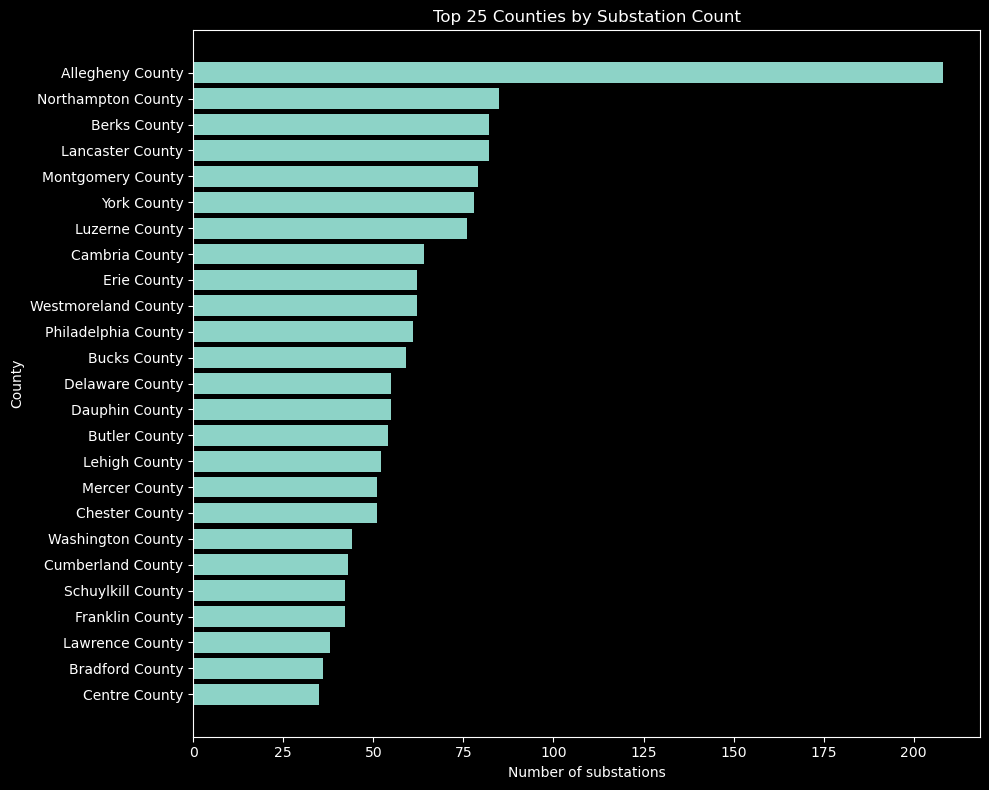


Substation counts by state quadrant:


,state_quadrant,n_substations,percent_total
1,Northwest,292,12.52
0,Northeast,332,14.23
3,Southwest,734,31.46
2,Southeast,975,41.79


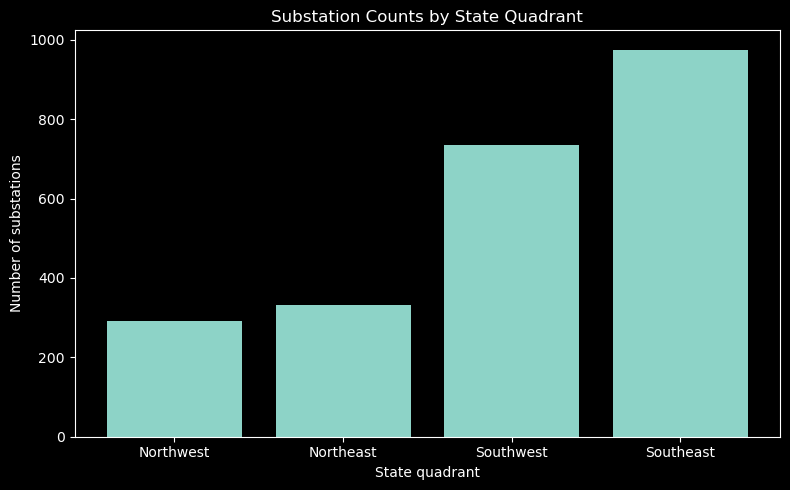


Minimal-risk substations that do not share a boundary with SFHA:
1888

Distance to nearest SFHA for minimal-risk, non-touching substations:


,statistic,distance_to_nearest_sfha_mi
0,count,1888.000000
1,mean,0.324259
2,std,0.327547
3,min,0.000004
4,10%,0.022796
5,25%,0.075847
6,50%,0.229321
7,75%,0.478612
8,90%,0.744562
9,95%,0.913852


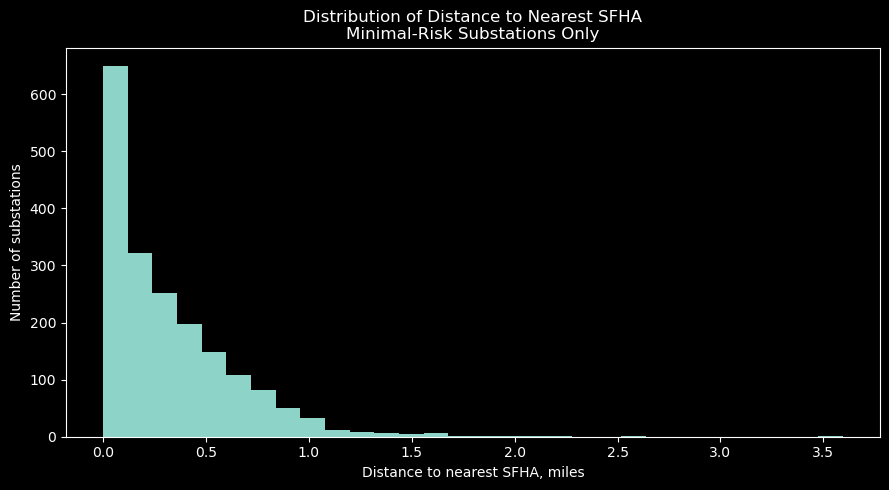

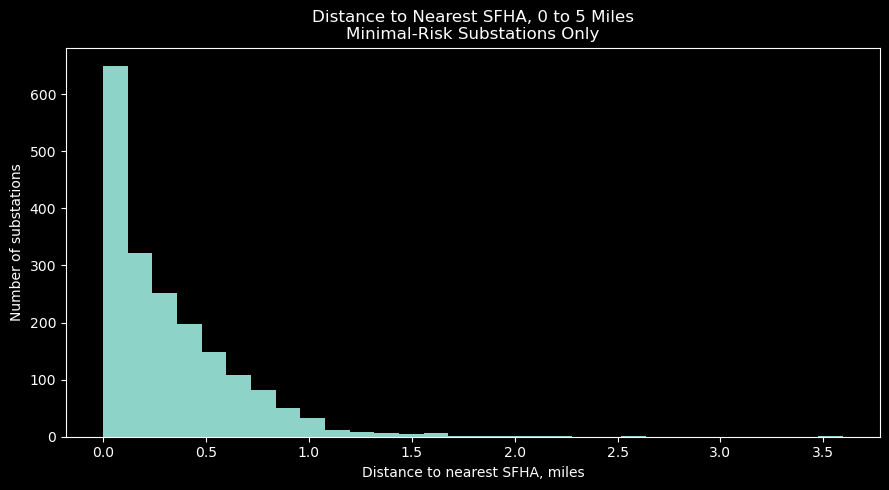


Presentation flood class by BFE flag:


bfe_status_clean,above_bfe,below_bfe
presentation_flood_class,,
Area not included,5,0
Inside SFHA - Floodway,17,4
Inside SFHA - Other,132,19
Outside SFHA - 0.2% annual chance flood hazard,89,9
Outside SFHA - Reduced risk due to levee,12,2
Outside SFHA - Touching SFHA boundary,35,121
Outside mapped flood hazard / minimal flood hazard,1748,140



Presentation flood class by quadrant:


presentation_flood_class,Area not included,Inside SFHA - Floodway,Inside SFHA - Other,Outside SFHA - 0.2% annual chance flood hazard,Outside SFHA - Reduced risk due to levee,Outside SFHA - Touching SFHA boundary,Outside mapped flood hazard / minimal flood hazard
state_quadrant,,,,,,,
Northeast,1,5,30,15,1,17,263
Northwest,1,1,16,16,0,27,231
Southeast,3,9,54,43,11,57,798
Southwest,0,6,51,24,2,55,596



Below-BFE substations by county and presentation flood class:


,county_clean,presentation_flood_class,n_below_bfe
57,Erie County,Outside mapped flood hazard / minimal flood ha...,19
52,Delaware County,Outside mapped flood hazard / minimal flood ha...,8
78,Luzerne County,Outside mapped flood hazard / minimal flood ha...,8
100,Philadelphia County,Outside mapped flood hazard / minimal flood ha...,8
81,Lycoming County,Outside mapped flood hazard / minimal flood ha...,7
17,Berks County,Outside mapped flood hazard / minimal flood ha...,6
27,Bucks County,Outside mapped flood hazard / minimal flood ha...,6
5,Allegheny County,Outside SFHA - Touching SFHA boundary,5
33,Centre County,Outside SFHA - Touching SFHA boundary,5
72,Lawrence County,Outside SFHA - Touching SFHA boundary,5


In [7]:
import arcpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

composite_floodhaz_fixed = "PA_substations_composite_final_floodhaz_fixed"

fields = [
    "OBJECTID",
    "county_name",
    "presentation_flood_class",
    "bfe_flag",
    "dem_minus_bfe",
    "sfha_near_dist_ft",
    "sfha_near_dist_mi",
    "in_sfha",
    "floodway_flag",
    "pct_annual_0_2_flag",
    "levee_reduced_risk_flag"
]

existing_fields = [field.name for field in arcpy.ListFields(composite_floodhaz_fixed)]

fields_use = [
    field for field in fields
    if field in existing_fields
]

records = []

with arcpy.da.SearchCursor(composite_floodhaz_fixed, fields_use + ["SHAPE@XY"]) as cursor:
    for row in cursor:
        attr_values = row[:-1]
        xy_value = row[-1]
        record = dict(zip(fields_use, attr_values))
        record["x_coord"] = xy_value[0]
        record["y_coord"] = xy_value[1]
        records.append(record)

summary_df = pd.DataFrame(records)

# Clean county name
summary_df["county_clean"] = (
    summary_df["county_name"]
    .astype(str)
    .str.replace(", Pennsylvania, USA", "", regex=False)
)

# Numeric cleanup
numeric_fields = [
    "dem_minus_bfe",
    "sfha_near_dist_ft",
    "sfha_near_dist_mi",
    "x_coord",
    "y_coord"
]

for field_name in numeric_fields:
    if field_name in summary_df.columns:
        summary_df[field_name] = pd.to_numeric(summary_df[field_name], errors="coerce")

# --------------------------------------------------
# 1. County table: above and below BFE
# --------------------------------------------------

summary_df["bfe_status_clean"] = summary_df["bfe_flag"].fillna("missing_or_unknown")

bfe_county_table = (
    summary_df
    .groupby(["county_clean", "bfe_status_clean"], dropna=False)
    .size()
    .reset_index(name="n_substations")
    .pivot_table(
        index="county_clean",
        columns="bfe_status_clean",
        values="n_substations",
        fill_value=0,
        aggfunc="sum"
    )
    .reset_index()
)

for col in ["above_bfe", "below_bfe", "missing_or_unknown"]:
    if col not in bfe_county_table.columns:
        bfe_county_table[col] = 0

county_totals = (
    summary_df
    .groupby("county_clean", dropna=False)
    .size()
    .reset_index(name="total_substations")
)

bfe_county_table = county_totals.merge(
    bfe_county_table,
    on="county_clean",
    how="left"
)

bfe_county_table["pct_below_bfe"] = (
    bfe_county_table["below_bfe"] /
    bfe_county_table["total_substations"] *
    100
).round(2)

bfe_county_table["pct_above_bfe"] = (
    bfe_county_table["above_bfe"] /
    bfe_county_table["total_substations"] *
    100
).round(2)

bfe_county_table = bfe_county_table.sort_values(
    by=["below_bfe", "pct_below_bfe", "total_substations"],
    ascending=[False, False, False]
)

print("BFE status by county:")
display(bfe_county_table)

print("\nTop 15 counties by number of substations below BFE:")
display(bfe_county_table.head(15))


# --------------------------------------------------
# 2. Plot: substation counts across counties
# --------------------------------------------------

county_count_plot_df = (
    summary_df
    .groupby("county_clean", dropna=False)
    .size()
    .reset_index(name="n_substations")
    .sort_values("n_substations", ascending=False)
)

top_n_counties = 25

county_count_plot_top = county_count_plot_df.head(top_n_counties).sort_values(
    "n_substations",
    ascending=True
)

plt.figure(figsize=(10, 8))
plt.barh(
    county_count_plot_top["county_clean"],
    county_count_plot_top["n_substations"]
)
plt.xlabel("Number of substations")
plt.ylabel("County")
plt.title(f"Top {top_n_counties} Counties by Substation Count")
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 3. Quadrant classification and plot
# Uses the layer extent midpoint as the state split.
# --------------------------------------------------

layer_extent = arcpy.Describe(composite_floodhaz_fixed).extent

x_mid = (layer_extent.XMin + layer_extent.XMax) / 2
y_mid = (layer_extent.YMin + layer_extent.YMax) / 2

def assign_state_quadrant(row):
    if row["x_coord"] < x_mid and row["y_coord"] >= y_mid:
        return "Northwest"
    elif row["x_coord"] >= x_mid and row["y_coord"] >= y_mid:
        return "Northeast"
    elif row["x_coord"] < x_mid and row["y_coord"] < y_mid:
        return "Southwest"
    elif row["x_coord"] >= x_mid and row["y_coord"] < y_mid:
        return "Southeast"
    else:
        return "Unknown"

summary_df["state_quadrant"] = summary_df.apply(assign_state_quadrant, axis=1)

quadrant_order = ["Northwest", "Northeast", "Southwest", "Southeast"]

quadrant_summary = (
    summary_df
    .groupby("state_quadrant", dropna=False)
    .size()
    .reset_index(name="n_substations")
)

quadrant_summary["percent_total"] = (
    quadrant_summary["n_substations"] / len(summary_df) * 100
).round(2)

quadrant_summary["state_quadrant"] = pd.Categorical(
    quadrant_summary["state_quadrant"],
    categories=quadrant_order,
    ordered=True
)

quadrant_summary = quadrant_summary.sort_values("state_quadrant")

print("\nSubstation counts by state quadrant:")
display(quadrant_summary)

plt.figure(figsize=(8, 5))
plt.bar(
    quadrant_summary["state_quadrant"].astype(str),
    quadrant_summary["n_substations"]
)
plt.xlabel("State quadrant")
plt.ylabel("Number of substations")
plt.title("Substation Counts by State Quadrant")
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 4. Distribution plot:
# minimal-risk substations that do not touch SFHA
# --------------------------------------------------

minimal_no_touch_df = summary_df.loc[
    summary_df["presentation_flood_class"] == "Outside mapped flood hazard / minimal flood hazard"
].copy()

print("\nMinimal-risk substations that do not share a boundary with SFHA:")
print(len(minimal_no_touch_df))

minimal_distance_summary = (
    minimal_no_touch_df["sfha_near_dist_mi"]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .reset_index()
)

minimal_distance_summary.columns = ["statistic", "distance_to_nearest_sfha_mi"]

print("\nDistance to nearest SFHA for minimal-risk, non-touching substations:")
display(minimal_distance_summary)

plt.figure(figsize=(9, 5))
plt.hist(
    minimal_no_touch_df["sfha_near_dist_mi"].dropna(),
    bins=30
)
plt.xlabel("Distance to nearest SFHA, miles")
plt.ylabel("Number of substations")
plt.title("Distribution of Distance to Nearest SFHA\nMinimal-Risk Substations Only")
plt.tight_layout()
plt.show()

# Optional zoomed histogram for the lower-distance range
minimal_distance_zoom_df = minimal_no_touch_df.loc[
    minimal_no_touch_df["sfha_near_dist_mi"].between(0, 5, inclusive="both")
].copy()

plt.figure(figsize=(9, 5))
plt.hist(
    minimal_distance_zoom_df["sfha_near_dist_mi"].dropna(),
    bins=30
)
plt.xlabel("Distance to nearest SFHA, miles")
plt.ylabel("Number of substations")
plt.title("Distance to Nearest SFHA, 0 to 5 Miles\nMinimal-Risk Substations Only")
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 5. Useful extra summaries
# --------------------------------------------------

print("\nPresentation flood class by BFE flag:")
display(
    pd.crosstab(
        summary_df["presentation_flood_class"],
        summary_df["bfe_status_clean"],
        dropna=False
    )
)

print("\nPresentation flood class by quadrant:")
display(
    pd.crosstab(
        summary_df["state_quadrant"],
        summary_df["presentation_flood_class"],
        dropna=False
    )
)

print("\nBelow-BFE substations by county and presentation flood class:")
below_bfe_county_class = (
    summary_df
    .loc[summary_df["bfe_status_clean"] == "below_bfe"]
    .groupby(["county_clean", "presentation_flood_class"], dropna=False)
    .size()
    .reset_index(name="n_below_bfe")
    .sort_values(["n_below_bfe", "county_clean"], ascending=[False, True])
)

display(below_bfe_county_class.head(30))

County-level combined flood exposure and BFE summary:


,county_clean,total_substations,inside_sfha,touching_sfha_boundary,inside_or_touching_sfha,above_bfe,below_bfe,missing_or_unknown_bfe,below_bfe_and_inside_sfha,below_bfe_and_touching_sfha,below_bfe_and_inside_or_touching_sfha,pct_inside_sfha,pct_touching_sfha_boundary,pct_inside_or_touching_sfha,pct_below_bfe,pct_below_bfe_and_inside_or_touching_sfha
1,Allegheny County,208,14,11,25,197,11,0,2,5,7,6.73,5.29,12.02,5.29,3.37
36,Lawrence County,38,5,7,12,30,8,0,1,5,6,13.16,18.42,31.58,21.05,15.79
13,Centre County,35,6,6,12,30,5,0,0,5,5,17.14,17.14,34.29,14.29,14.29
6,Blair County,34,7,5,12,26,8,0,1,3,4,20.59,14.71,35.29,23.53,11.76
64,Westmoreland County,62,6,5,11,52,10,0,2,4,6,9.68,8.06,17.74,16.13,9.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,Juniata County,9,0,0,0,9,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00
49,Perry County,9,0,0,0,8,1,0,0,0,0,0.00,0.00,0.00,11.11,0.00
65,Wyoming County,8,0,0,0,7,1,0,0,0,0,0.00,0.00,0.00,12.50,0.00
26,Forest County,3,0,0,0,3,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00



Top 20 counties by substations inside or touching SFHA:


,county_clean,total_substations,inside_sfha,touching_sfha_boundary,inside_or_touching_sfha,above_bfe,below_bfe,missing_or_unknown_bfe,below_bfe_and_inside_sfha,below_bfe_and_touching_sfha,below_bfe_and_inside_or_touching_sfha,pct_inside_sfha,pct_touching_sfha_boundary,pct_inside_or_touching_sfha,pct_below_bfe,pct_below_bfe_and_inside_or_touching_sfha
1,Allegheny County,208,14,11,25,197,11,0,2,5,7,6.73,5.29,12.02,5.29,3.37
36,Lawrence County,38,5,7,12,30,8,0,1,5,6,13.16,18.42,31.58,21.05,15.79
13,Centre County,35,6,6,12,30,5,0,0,5,5,17.14,17.14,34.29,14.29,14.29
6,Blair County,34,7,5,12,26,8,0,1,3,4,20.59,14.71,35.29,23.53,11.76
64,Westmoreland County,62,6,5,11,52,10,0,2,4,6,9.68,8.06,17.74,16.13,9.68
21,Dauphin County,55,8,3,11,48,7,0,2,2,4,14.55,5.45,20.00,12.73,7.27
47,Northampton County,85,6,5,11,77,8,0,0,4,4,7.06,5.88,12.94,9.41,4.71
39,Luzerne County,76,6,5,11,66,10,0,0,2,2,7.89,6.58,14.47,13.16,2.63
14,Chester County,51,6,4,10,46,5,0,1,3,4,11.76,7.84,19.61,9.80,7.84
50,Philadelphia County,61,4,5,9,47,14,0,0,5,5,6.56,8.20,14.75,22.95,8.20



Top 20 counties by below-BFE substations that are inside or touching SFHA:


,county_clean,total_substations,inside_sfha,touching_sfha_boundary,inside_or_touching_sfha,above_bfe,below_bfe,missing_or_unknown_bfe,below_bfe_and_inside_sfha,below_bfe_and_touching_sfha,below_bfe_and_inside_or_touching_sfha,pct_inside_sfha,pct_touching_sfha_boundary,pct_inside_or_touching_sfha,pct_below_bfe,pct_below_bfe_and_inside_or_touching_sfha
1,Allegheny County,208,14,11,25,197,11,0,2,5,7,6.73,5.29,12.02,5.29,3.37
36,Lawrence County,38,5,7,12,30,8,0,1,5,6,13.16,18.42,31.58,21.05,15.79
64,Westmoreland County,62,6,5,11,52,10,0,2,4,6,9.68,8.06,17.74,16.13,9.68
13,Centre County,35,6,6,12,30,5,0,0,5,5,17.14,17.14,34.29,14.29,14.29
50,Philadelphia County,61,4,5,9,47,14,0,0,5,5,6.56,8.20,14.75,22.95,8.20
43,Mifflin County,18,0,5,5,13,5,0,0,5,5,0.00,27.78,27.78,27.78,27.78
6,Blair County,34,7,5,12,26,8,0,1,3,4,20.59,14.71,35.29,23.53,11.76
47,Northampton County,85,6,5,11,77,8,0,0,4,4,7.06,5.88,12.94,9.41,4.71
21,Dauphin County,55,8,3,11,48,7,0,2,2,4,14.55,5.45,20.00,12.73,7.27
14,Chester County,51,6,4,10,46,5,0,1,3,4,11.76,7.84,19.61,9.80,7.84



Exported county summary table to:
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\county_flood_bfe_summary.csv

Minimal-risk substations that do not share a boundary with SFHA:
1888

Distance to nearest SFHA for minimal-risk, non-touching substations, feet:


,statistic,distance_to_nearest_sfha_ft
0,count,1888.000000
1,mean,1712.088466
2,std,1729.447410
3,min,0.021779
4,10%,120.364245
5,25%,400.471732
6,50%,1210.815538
7,75%,2527.070848
8,90%,3931.286063
9,95%,4825.137626


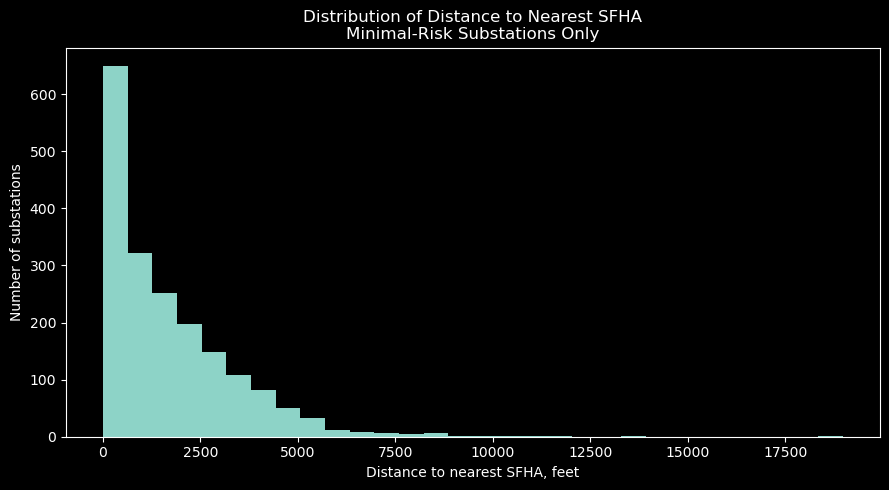

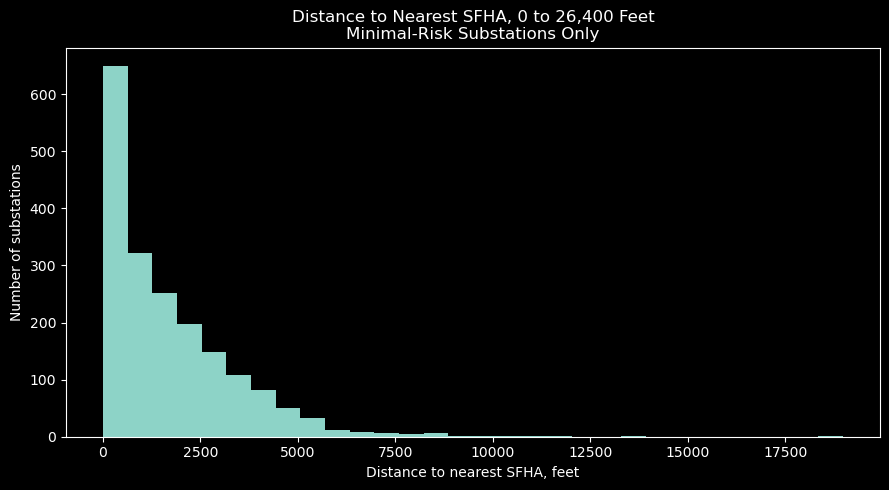


Distance bins in feet for minimal-risk, non-touching substations:


,sfha_distance_bin_ft,n_substations,percent_minimal_hazard_subset,percent_all_substations
0,0-500 ft,555,29.40,23.79
1,"500-1,000 ft",287,15.20,12.30
2,"1,000-2,500 ft",569,30.14,24.39
3,"2,500-5,280 ft",407,21.56,17.45
4,1-2 mi,65,3.44,2.79
5,2-5 mi,5,0.26,0.21
6,5-10 mi,0,0.00,0.00
7,>10 mi,0,0.00,0.00


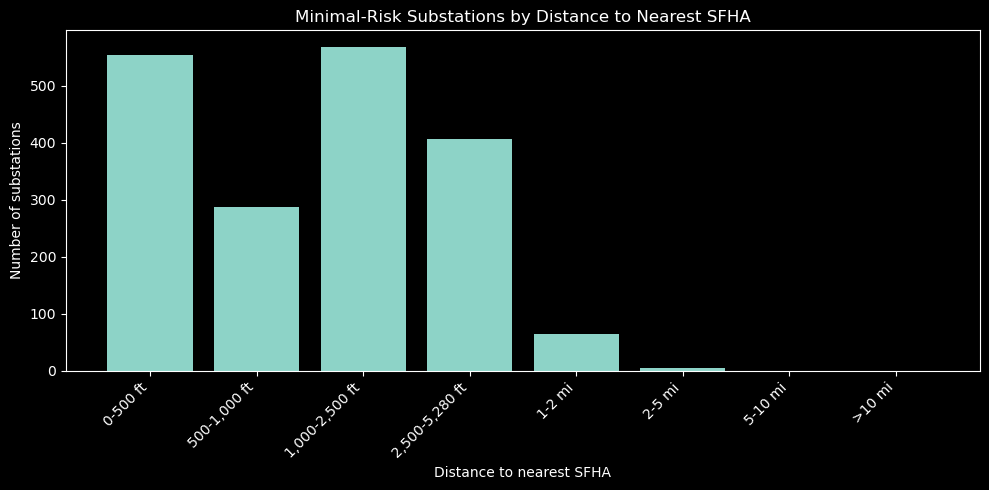

In [8]:
import arcpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

composite_floodhaz_fixed = "PA_substations_composite_final_floodhaz_fixed"

fields = [
    "OBJECTID",
    "county_name",
    "presentation_flood_class",
    "in_sfha",
    "floodway_flag",
    "sfha_near_dist_ft",
    "sfha_near_dist_mi",
    "bfe_flag",
    "dem_minus_bfe",
    "pct_annual_0_2_flag",
    "levee_reduced_risk_flag"
]

existing_fields = [field.name for field in arcpy.ListFields(composite_floodhaz_fixed)]

fields_use = [
    field for field in fields
    if field in existing_fields
]

records = []

with arcpy.da.SearchCursor(composite_floodhaz_fixed, fields_use) as cursor:
    for row in cursor:
        records.append(dict(zip(fields_use, row)))

summary_df = pd.DataFrame(records)

summary_df["county_clean"] = (
    summary_df["county_name"]
    .astype(str)
    .str.replace(", Pennsylvania, USA", "", regex=False)
)

numeric_fields = [
    "in_sfha",
    "floodway_flag",
    "sfha_near_dist_ft",
    "sfha_near_dist_mi",
    "dem_minus_bfe",
    "pct_annual_0_2_flag",
    "levee_reduced_risk_flag"
]

for field_name in numeric_fields:
    if field_name in summary_df.columns:
        summary_df[field_name] = pd.to_numeric(
            summary_df[field_name],
            errors="coerce"
        )

summary_df["bfe_status_clean"] = summary_df["bfe_flag"].fillna("missing_or_unknown")

sfha_touching_classes = [
    "Inside SFHA - Floodway",
    "Inside SFHA - Other",
    "Outside SFHA - Touching SFHA boundary"
]

summary_df["inside_sfha"] = (
    summary_df["presentation_flood_class"]
    .isin(["Inside SFHA - Floodway", "Inside SFHA - Other"])
    .astype(int)
)

summary_df["touching_sfha_boundary"] = (
    summary_df["presentation_flood_class"]
    .eq("Outside SFHA - Touching SFHA boundary")
    .astype(int)
)

summary_df["inside_or_touching_sfha"] = (
    summary_df["presentation_flood_class"]
    .isin(sfha_touching_classes)
    .astype(int)
)

summary_df["below_bfe"] = (
    summary_df["bfe_status_clean"]
    .eq("below_bfe")
    .astype(int)
)

summary_df["above_bfe"] = (
    summary_df["bfe_status_clean"]
    .eq("above_bfe")
    .astype(int)
)

summary_df["missing_or_unknown_bfe"] = (
    ~summary_df["bfe_status_clean"].isin(["above_bfe", "below_bfe"])
).astype(int)

summary_df["below_bfe_and_inside_or_touching_sfha"] = (
    (summary_df["below_bfe"] == 1) &
    (summary_df["inside_or_touching_sfha"] == 1)
).astype(int)

summary_df["below_bfe_and_inside_sfha"] = (
    (summary_df["below_bfe"] == 1) &
    (summary_df["inside_sfha"] == 1)
).astype(int)

summary_df["below_bfe_and_touching_sfha"] = (
    (summary_df["below_bfe"] == 1) &
    (summary_df["touching_sfha_boundary"] == 1)
).astype(int)


# --------------------------------------------------
# Combined county summary table
# --------------------------------------------------

county_combined_table = (
    summary_df
    .groupby("county_clean", dropna=False)
    .agg(
        total_substations=("OBJECTID", "count"),
        inside_sfha=("inside_sfha", "sum"),
        touching_sfha_boundary=("touching_sfha_boundary", "sum"),
        inside_or_touching_sfha=("inside_or_touching_sfha", "sum"),
        above_bfe=("above_bfe", "sum"),
        below_bfe=("below_bfe", "sum"),
        missing_or_unknown_bfe=("missing_or_unknown_bfe", "sum"),
        below_bfe_and_inside_sfha=("below_bfe_and_inside_sfha", "sum"),
        below_bfe_and_touching_sfha=("below_bfe_and_touching_sfha", "sum"),
        below_bfe_and_inside_or_touching_sfha=("below_bfe_and_inside_or_touching_sfha", "sum")
    )
    .reset_index()
)

county_combined_table["pct_inside_sfha"] = (
    county_combined_table["inside_sfha"] /
    county_combined_table["total_substations"] *
    100
).round(2)

county_combined_table["pct_touching_sfha_boundary"] = (
    county_combined_table["touching_sfha_boundary"] /
    county_combined_table["total_substations"] *
    100
).round(2)

county_combined_table["pct_inside_or_touching_sfha"] = (
    county_combined_table["inside_or_touching_sfha"] /
    county_combined_table["total_substations"] *
    100
).round(2)

county_combined_table["pct_below_bfe"] = (
    county_combined_table["below_bfe"] /
    county_combined_table["total_substations"] *
    100
).round(2)

county_combined_table["pct_below_bfe_and_inside_or_touching_sfha"] = (
    county_combined_table["below_bfe_and_inside_or_touching_sfha"] /
    county_combined_table["total_substations"] *
    100
).round(2)

county_combined_table = county_combined_table.sort_values(
    by=[
        "inside_or_touching_sfha",
        "below_bfe_and_inside_or_touching_sfha",
        "pct_inside_or_touching_sfha",
        "total_substations"
    ],
    ascending=[False, False, False, False]
)

print("County-level combined flood exposure and BFE summary:")
display(county_combined_table)

print("\nTop 20 counties by substations inside or touching SFHA:")
display(county_combined_table.head(20))

print("\nTop 20 counties by below-BFE substations that are inside or touching SFHA:")
display(
    county_combined_table
    .sort_values(
        by=[
            "below_bfe_and_inside_or_touching_sfha",
            "inside_or_touching_sfha",
            "below_bfe",
            "total_substations"
        ],
        ascending=[False, False, False, False]
    )
    .head(20)
)


# --------------------------------------------------
# Optional: export county table to CSV
# --------------------------------------------------

output_csv = os.path.join(OUTPUT_DIR, "county_flood_bfe_summary.csv")

county_combined_table.to_csv(output_csv, index=False)

print("\nExported county summary table to:")
print(output_csv)


# --------------------------------------------------
# Distance plots in feet:
# minimal-risk substations that do not touch SFHA
# --------------------------------------------------

minimal_no_touch_df = summary_df.loc[
    summary_df["presentation_flood_class"] == "Outside mapped flood hazard / minimal flood hazard"
].copy()

print("\nMinimal-risk substations that do not share a boundary with SFHA:")
print(len(minimal_no_touch_df))

minimal_distance_summary_ft = (
    minimal_no_touch_df["sfha_near_dist_ft"]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .reset_index()
)

minimal_distance_summary_ft.columns = [
    "statistic",
    "distance_to_nearest_sfha_ft"
]

print("\nDistance to nearest SFHA for minimal-risk, non-touching substations, feet:")
display(minimal_distance_summary_ft)


# Full-range histogram in feet
plt.figure(figsize=(9, 5))
plt.hist(
    minimal_no_touch_df["sfha_near_dist_ft"].dropna(),
    bins=30
)
plt.xlabel("Distance to nearest SFHA, feet")
plt.ylabel("Number of substations")
plt.title("Distribution of Distance to Nearest SFHA\nMinimal-Risk Substations Only")
plt.tight_layout()
plt.show()


# Zoomed histogram: 0 to 5 miles, shown in feet
max_zoom_ft = 5 * 5280

minimal_distance_zoom_df = minimal_no_touch_df.loc[
    minimal_no_touch_df["sfha_near_dist_ft"].between(0, max_zoom_ft, inclusive="both")
].copy()

plt.figure(figsize=(9, 5))
plt.hist(
    minimal_distance_zoom_df["sfha_near_dist_ft"].dropna(),
    bins=30
)
plt.xlabel("Distance to nearest SFHA, feet")
plt.ylabel("Number of substations")
plt.title("Distance to Nearest SFHA, 0 to 26,400 Feet\nMinimal-Risk Substations Only")
plt.tight_layout()
plt.show()


# Distance bins in feet
distance_bins_ft = [
    0,
    500,
    1000,
    2500,
    5280,
    10560,
    26400,
    52800,
    np.inf
]

distance_labels_ft = [
    "0-500 ft",
    "500-1,000 ft",
    "1,000-2,500 ft",
    "2,500-5,280 ft",
    "1-2 mi",
    "2-5 mi",
    "5-10 mi",
    ">10 mi"
]

minimal_no_touch_df["sfha_distance_bin_ft"] = pd.cut(
    minimal_no_touch_df["sfha_near_dist_ft"],
    bins=distance_bins_ft,
    labels=distance_labels_ft,
    include_lowest=True
)

minimal_distance_bin_summary_ft = (
    minimal_no_touch_df
    .groupby("sfha_distance_bin_ft", observed=False)
    .size()
    .reset_index(name="n_substations")
)

minimal_distance_bin_summary_ft["percent_minimal_hazard_subset"] = (
    minimal_distance_bin_summary_ft["n_substations"] /
    len(minimal_no_touch_df) *
    100
).round(2)

minimal_distance_bin_summary_ft["percent_all_substations"] = (
    minimal_distance_bin_summary_ft["n_substations"] /
    len(summary_df) *
    100
).round(2)

print("\nDistance bins in feet for minimal-risk, non-touching substations:")
display(minimal_distance_bin_summary_ft)


# Bar plot for distance bins
plt.figure(figsize=(10, 5))
plt.bar(
    minimal_distance_bin_summary_ft["sfha_distance_bin_ft"].astype(str),
    minimal_distance_bin_summary_ft["n_substations"]
)
plt.xlabel("Distance to nearest SFHA")
plt.ylabel("Number of substations")
plt.title("Minimal-Risk Substations by Distance to Nearest SFHA")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Operator-level exposure summary:


,operator_clean,total_substations,inside_sfha,touching_sfha_boundary,inside_or_touching_sfha,above_bfe,below_bfe,missing_or_unknown_bfe,above_bfe_and_inside_or_touching_sfha,below_bfe_and_inside_or_touching_sfha,pct_inside_or_touching_sfha,pct_below_bfe,pct_below_bfe_and_inside_or_touching_sfha
57,Unknown / missing operator,1153,78,94,172,994,159,0,85,87,14.92,13.79,7.55
34,PPL,410,34,13,47,375,35,0,36,11,11.46,8.54,2.68
32,PECO,147,12,9,21,119,28,0,12,9,14.29,19.05,6.12
35,Penelec,131,10,10,20,105,26,0,11,9,15.27,19.85,6.87
39,Pennsylvania Electric Company,84,11,7,18,74,10,0,12,6,21.43,11.90,7.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...
51,Tri County Rural Electric Cooperative/West Pen...,1,0,0,0,1,0,0,0,0,0.00,0.00,0.00
52,Tri-County Cooperative,1,0,0,0,1,0,0,0,0,0.00,0.00,0.00
54,UGI Corporation,1,0,0,0,1,0,0,0,0,0.00,0.00,0.00
56,US Steel,1,0,0,0,1,0,0,0,0,0.00,0.00,0.00



Top 25 operators by substations inside or touching SFHA:


,operator_clean,total_substations,inside_sfha,touching_sfha_boundary,inside_or_touching_sfha,above_bfe,below_bfe,missing_or_unknown_bfe,above_bfe_and_inside_or_touching_sfha,below_bfe_and_inside_or_touching_sfha,pct_inside_or_touching_sfha,pct_below_bfe,pct_below_bfe_and_inside_or_touching_sfha
57,Unknown / missing operator,1153,78,94,172,994,159,0,85,87,14.92,13.79,7.55
34,PPL,410,34,13,47,375,35,0,36,11,11.46,8.54,2.68
32,PECO,147,12,9,21,119,28,0,12,9,14.29,19.05,6.12
35,Penelec,131,10,10,20,105,26,0,11,9,15.27,19.85,6.87
39,Pennsylvania Electric Company,84,11,7,18,74,10,0,12,6,21.43,11.90,7.14
23,Met-Ed,118,11,6,17,108,10,0,11,6,14.41,8.47,5.08
60,West Penn Power,74,8,7,15,64,10,0,8,7,20.27,13.51,9.46
37,Penn Power,29,1,3,4,25,4,0,1,3,13.79,13.79,10.34
9,Amtrak,22,1,1,2,19,3,0,0,2,9.09,13.64,9.09
40,Philadelphia Electric Company,2,1,1,2,1,1,0,1,1,100.00,50.00,50.00



Top 25 operators by below-BFE substations inside or touching SFHA:


,operator_clean,total_substations,inside_sfha,touching_sfha_boundary,inside_or_touching_sfha,above_bfe,below_bfe,missing_or_unknown_bfe,above_bfe_and_inside_or_touching_sfha,below_bfe_and_inside_or_touching_sfha,pct_inside_or_touching_sfha,pct_below_bfe,pct_below_bfe_and_inside_or_touching_sfha
57,Unknown / missing operator,1153,78,94,172,994,159,0,85,87,14.92,13.79,7.55
34,PPL,410,34,13,47,375,35,0,36,11,11.46,8.54,2.68
32,PECO,147,12,9,21,119,28,0,12,9,14.29,19.05,6.12
35,Penelec,131,10,10,20,105,26,0,11,9,15.27,19.85,6.87
60,West Penn Power,74,8,7,15,64,10,0,8,7,20.27,13.51,9.46
39,Pennsylvania Electric Company,84,11,7,18,74,10,0,12,6,21.43,11.90,7.14
23,Met-Ed,118,11,6,17,108,10,0,11,6,14.41,8.47,5.08
37,Penn Power,29,1,3,4,25,4,0,1,3,13.79,13.79,10.34
9,Amtrak,22,1,1,2,19,3,0,0,2,9.09,13.64,9.09
40,Philadelphia Electric Company,2,1,1,2,1,1,0,1,1,100.00,50.00,50.00



Exported operator exposure table to:
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\operator_flood_bfe_exposure_summary.csv

DEM minus BFE summary by presentation flood class:


,presentation_flood_class,n_substations,min_dem_minus_bfe,p10_dem_minus_bfe,median_dem_minus_bfe,mean_dem_minus_bfe,p90_dem_minus_bfe,max_dem_minus_bfe
0,Inside SFHA - Floodway,21,-60.58,-4.85,88.89,131.35,368.12,471.71
1,Inside SFHA - Other,151,-118.92,-1.79,50.99,118.32,357.44,1005.95
2,Outside SFHA - Touching SFHA boundary,156,-673.35,-13.18,-2.64,1.98,8.46,528.44
3,Outside SFHA - 0.2% annual chance flood hazard,98,-100.44,0.86,45.77,115.76,347.71,1238.00
4,Outside SFHA - Reduced risk due to levee,14,-9.15,-0.57,69.22,70.01,139.66,158.84
5,Outside mapped flood hazard / minimal flood ha...,1888,-2553.50,2.03,57.21,122.97,357.36,1432.81
6,Area not included,5,6.55,72.75,226.37,259.06,465.77,548.24


C:/Users/Owner/AppData/Local/Temp/ArcGISProTemp18556/xpython_18556/3734010060.py:263: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


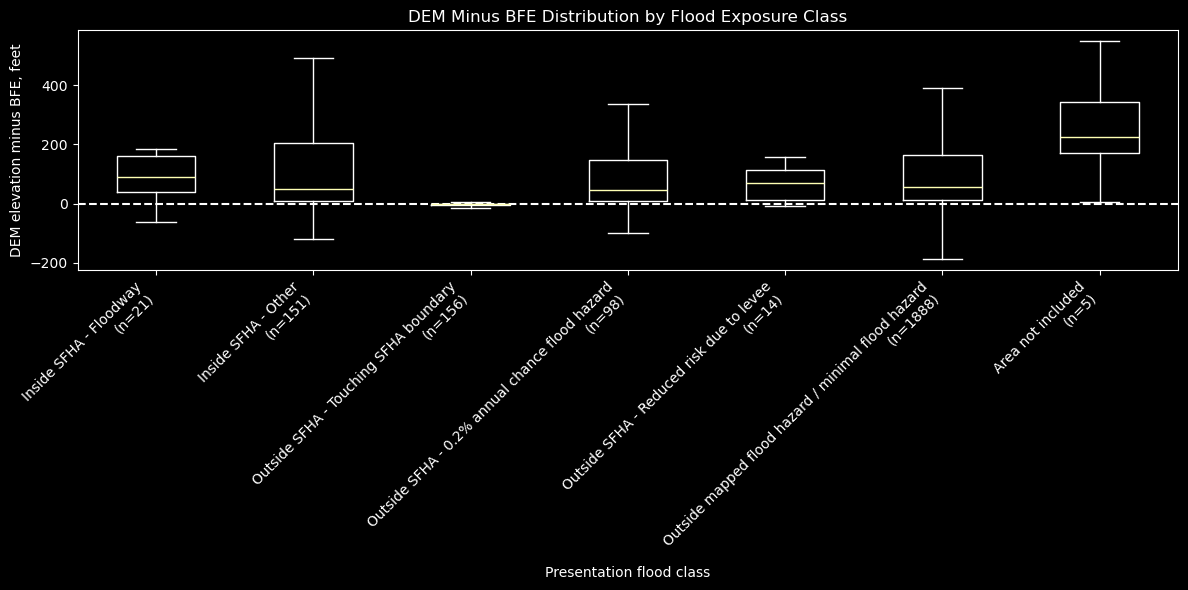

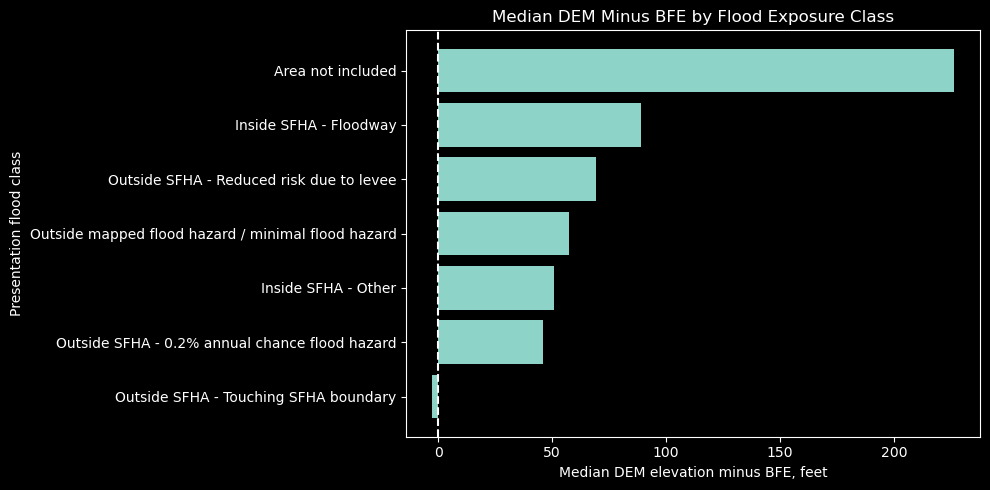

In [9]:
import arcpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

composite_floodhaz_fixed = "PA_substations_composite_final_floodhaz_fixed"

fields = [
    "OBJECTID",
    "operator",
    "presentation_flood_class",
    "in_sfha",
    "sfha_near_dist_ft",
    "bfe_flag",
    "dem_minus_bfe",
    "county_name"
]

existing_fields = [field.name for field in arcpy.ListFields(composite_floodhaz_fixed)]

fields_use = [
    field for field in fields
    if field in existing_fields
]

records = []

with arcpy.da.SearchCursor(composite_floodhaz_fixed, fields_use) as cursor:
    for row in cursor:
        records.append(dict(zip(fields_use, row)))

operator_df = pd.DataFrame(records)

# Clean operator names
operator_df["operator_clean"] = (
    operator_df["operator"]
    .fillna("Unknown / missing operator")
    .astype(str)
    .str.strip()
)

operator_df.loc[
    operator_df["operator_clean"].isin(["", "<Null>", "None", "nan"]),
    "operator_clean"
] = "Unknown / missing operator"

# Force numeric fields
operator_df["dem_minus_bfe"] = pd.to_numeric(
    operator_df["dem_minus_bfe"],
    errors="coerce"
)

operator_df["sfha_near_dist_ft"] = pd.to_numeric(
    operator_df["sfha_near_dist_ft"],
    errors="coerce"
)

# Define in-or-touching SFHA
sfha_touching_classes = [
    "Inside SFHA - Floodway",
    "Inside SFHA - Other",
    "Outside SFHA - Touching SFHA boundary"
]

operator_df["inside_sfha"] = (
    operator_df["presentation_flood_class"]
    .isin(["Inside SFHA - Floodway", "Inside SFHA - Other"])
    .astype(int)
)

operator_df["touching_sfha_boundary"] = (
    operator_df["presentation_flood_class"]
    .eq("Outside SFHA - Touching SFHA boundary")
    .astype(int)
)

operator_df["inside_or_touching_sfha"] = (
    operator_df["presentation_flood_class"]
    .isin(sfha_touching_classes)
    .astype(int)
)

operator_df["below_bfe"] = (
    operator_df["bfe_flag"]
    .eq("below_bfe")
    .astype(int)
)

operator_df["above_bfe"] = (
    operator_df["bfe_flag"]
    .eq("above_bfe")
    .astype(int)
)

operator_df["missing_or_unknown_bfe"] = (
    ~operator_df["bfe_flag"].isin(["above_bfe", "below_bfe"])
).astype(int)

operator_df["below_bfe_and_inside_or_touching_sfha"] = (
    (operator_df["below_bfe"] == 1) &
    (operator_df["inside_or_touching_sfha"] == 1)
).astype(int)

operator_df["above_bfe_and_inside_or_touching_sfha"] = (
    (operator_df["above_bfe"] == 1) &
    (operator_df["inside_or_touching_sfha"] == 1)
).astype(int)


# --------------------------------------------------
# Operator-level exposure table
# --------------------------------------------------

operator_exposure_table = (
    operator_df
    .groupby("operator_clean", dropna=False)
    .agg(
        total_substations=("OBJECTID", "count"),
        inside_sfha=("inside_sfha", "sum"),
        touching_sfha_boundary=("touching_sfha_boundary", "sum"),
        inside_or_touching_sfha=("inside_or_touching_sfha", "sum"),
        above_bfe=("above_bfe", "sum"),
        below_bfe=("below_bfe", "sum"),
        missing_or_unknown_bfe=("missing_or_unknown_bfe", "sum"),
        above_bfe_and_inside_or_touching_sfha=("above_bfe_and_inside_or_touching_sfha", "sum"),
        below_bfe_and_inside_or_touching_sfha=("below_bfe_and_inside_or_touching_sfha", "sum")
    )
    .reset_index()
)

operator_exposure_table["pct_inside_or_touching_sfha"] = (
    operator_exposure_table["inside_or_touching_sfha"] /
    operator_exposure_table["total_substations"] *
    100
).round(2)

operator_exposure_table["pct_below_bfe"] = (
    operator_exposure_table["below_bfe"] /
    operator_exposure_table["total_substations"] *
    100
).round(2)

operator_exposure_table["pct_below_bfe_and_inside_or_touching_sfha"] = (
    operator_exposure_table["below_bfe_and_inside_or_touching_sfha"] /
    operator_exposure_table["total_substations"] *
    100
).round(2)

operator_exposure_table = operator_exposure_table.sort_values(
    by=[
        "inside_or_touching_sfha",
        "below_bfe_and_inside_or_touching_sfha",
        "below_bfe",
        "total_substations"
    ],
    ascending=[False, False, False, False]
)

print("Operator-level exposure summary:")
display(operator_exposure_table)

print("\nTop 25 operators by substations inside or touching SFHA:")
display(operator_exposure_table.head(25))

print("\nTop 25 operators by below-BFE substations inside or touching SFHA:")
display(
    operator_exposure_table
    .sort_values(
        by=[
            "below_bfe_and_inside_or_touching_sfha",
            "inside_or_touching_sfha",
            "below_bfe",
            "total_substations"
        ],
        ascending=[False, False, False, False]
    )
    .head(25)
)


# Optional export
operator_output_csv = os.path.join(OUTPUT_DIR, "operator_flood_bfe_exposure_summary.csv")

operator_exposure_table.to_csv(operator_output_csv, index=False)

print("\nExported operator exposure table to:")
print(operator_output_csv)


# --------------------------------------------------
# DEM minus BFE distribution by presentation_flood_class
# --------------------------------------------------

plot_df = operator_df.loc[
    operator_df["dem_minus_bfe"].notna()
].copy()

class_order = [
    "Inside SFHA - Floodway",
    "Inside SFHA - Other",
    "Outside SFHA - Touching SFHA boundary",
    "Outside SFHA - 0.2% annual chance flood hazard",
    "Outside SFHA - Reduced risk due to levee",
    "Outside mapped flood hazard / minimal flood hazard",
    "Area not included"
]

plot_df["presentation_flood_class"] = pd.Categorical(
    plot_df["presentation_flood_class"],
    categories=class_order,
    ordered=True
)

plot_df = plot_df.sort_values("presentation_flood_class")

# Summary table first
dem_bfe_summary_by_class = (
    plot_df
    .groupby("presentation_flood_class", observed=False)
    .agg(
        n_substations=("OBJECTID", "count"),
        min_dem_minus_bfe=("dem_minus_bfe", "min"),
        p10_dem_minus_bfe=("dem_minus_bfe", lambda x: x.quantile(0.10)),
        median_dem_minus_bfe=("dem_minus_bfe", "median"),
        mean_dem_minus_bfe=("dem_minus_bfe", "mean"),
        p90_dem_minus_bfe=("dem_minus_bfe", lambda x: x.quantile(0.90)),
        max_dem_minus_bfe=("dem_minus_bfe", "max")
    )
    .reset_index()
)

numeric_summary_cols = [
    "min_dem_minus_bfe",
    "p10_dem_minus_bfe",
    "median_dem_minus_bfe",
    "mean_dem_minus_bfe",
    "p90_dem_minus_bfe",
    "max_dem_minus_bfe"
]

for col in numeric_summary_cols:
    dem_bfe_summary_by_class[col] = dem_bfe_summary_by_class[col].round(2)

print("\nDEM minus BFE summary by presentation flood class:")
display(dem_bfe_summary_by_class)


# Boxplot
boxplot_data = [
    plot_df.loc[
        plot_df["presentation_flood_class"] == flood_class,
        "dem_minus_bfe"
    ].dropna()
    for flood_class in class_order
]

boxplot_labels = [
    f"{flood_class}\n(n={len(values)})"
    for flood_class, values in zip(class_order, boxplot_data)
]

plt.figure(figsize=(12, 6))
plt.boxplot(
    boxplot_data,
    labels=boxplot_labels,
    showfliers=False
)
plt.axhline(0, linestyle="--")
plt.ylabel("DEM elevation minus BFE, feet")
plt.xlabel("Presentation flood class")
plt.title("DEM Minus BFE Distribution by Flood Exposure Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Optional zoomed histogram-style comparison using overlapping class summaries is hard to read,
# so this gives a second plot: class medians sorted from lowest to highest.
median_plot_df = (
    dem_bfe_summary_by_class
    .dropna(subset=["median_dem_minus_bfe"])
    .sort_values("median_dem_minus_bfe", ascending=True)
)

plt.figure(figsize=(10, 5))
plt.barh(
    median_plot_df["presentation_flood_class"].astype(str),
    median_plot_df["median_dem_minus_bfe"]
)
plt.axvline(0, linestyle="--")
plt.xlabel("Median DEM elevation minus BFE, feet")
plt.ylabel("Presentation flood class")
plt.title("Median DEM Minus BFE by Flood Exposure Class")
plt.tight_layout()
plt.show()

### Exporting Tables to Excel

In [10]:
import arcpy
import pandas as pd
import numpy as np

composite_floodhaz_fixed = "PA_substations_composite_final_floodhaz_fixed"

fields = [
    "OBJECTID",
    "county_name",
    "operator",
    "presentation_flood_class",
    "in_sfha",
    "floodway_flag",
    "pct_annual_0_2_flag",
    "levee_reduced_risk_flag",
    "sfha_near_dist_ft",
    "sfha_near_dist_mi",
    "haz_SFHA_TF",
    "haz_FLD_ZONE",
    "haz_ZONE_SUBTY",
    "bfe_flag",
    "dem_minus_bfe",
    "bfe_elev_ft",
    "dem_ft",
    "chosen_q_sub_scaled",
    "chosen_flow_tdas",
    "chosen_flow_oid",
    "wb_direct_match",
    "wb_join_count",
    "wb_gnis_name"
]

existing_fields = [field.name for field in arcpy.ListFields(composite_floodhaz_fixed)]

fields_use = [
    field for field in fields
    if field in existing_fields
]

records = []

with arcpy.da.SearchCursor(composite_floodhaz_fixed, fields_use + ["SHAPE@XY"]) as cursor:
    for row in cursor:
        attr_values = row[:-1]
        xy_value = row[-1]

        record = dict(zip(fields_use, attr_values))
        record["x_coord"] = xy_value[0]
        record["y_coord"] = xy_value[1]

        records.append(record)

appendix_df = pd.DataFrame(records)

# Clean county names
appendix_df["county_clean"] = (
    appendix_df["county_name"]
    .astype(str)
    .str.replace(", Pennsylvania, USA", "", regex=False)
)

# Clean operator names
appendix_df["operator_clean"] = (
    appendix_df["operator"]
    .fillna("Unknown / missing operator")
    .astype(str)
    .str.strip()
)

appendix_df.loc[
    appendix_df["operator_clean"].isin(["", "<Null>", "None", "nan"]),
    "operator_clean"
] = "Unknown / missing operator"

# Numeric cleanup
numeric_fields = [
    "in_sfha",
    "floodway_flag",
    "pct_annual_0_2_flag",
    "levee_reduced_risk_flag",
    "sfha_near_dist_ft",
    "sfha_near_dist_mi",
    "dem_minus_bfe",
    "bfe_elev_ft",
    "dem_ft",
    "chosen_q_sub_scaled",
    "chosen_flow_tdas",
    "chosen_flow_oid",
    "wb_direct_match",
    "wb_join_count",
    "x_coord",
    "y_coord"
]

for field_name in numeric_fields:
    if field_name in appendix_df.columns:
        appendix_df[field_name] = pd.to_numeric(
            appendix_df[field_name],
            errors="coerce"
        )

appendix_df["bfe_status_clean"] = appendix_df["bfe_flag"].fillna("missing_or_unknown")

# Helper flags
inside_sfha_classes = [
    "Inside SFHA - Floodway",
    "Inside SFHA - Other"
]

sfha_touching_classes = [
    "Inside SFHA - Floodway",
    "Inside SFHA - Other",
    "Outside SFHA - Touching SFHA boundary"
]

appendix_df["inside_sfha"] = (
    appendix_df["presentation_flood_class"]
    .isin(inside_sfha_classes)
    .astype(int)
)

appendix_df["touching_sfha_boundary"] = (
    appendix_df["presentation_flood_class"]
    .eq("Outside SFHA - Touching SFHA boundary")
    .astype(int)
)

appendix_df["inside_or_touching_sfha"] = (
    appendix_df["presentation_flood_class"]
    .isin(sfha_touching_classes)
    .astype(int)
)

appendix_df["below_bfe"] = (
    appendix_df["bfe_status_clean"]
    .eq("below_bfe")
    .astype(int)
)

appendix_df["above_bfe"] = (
    appendix_df["bfe_status_clean"]
    .eq("above_bfe")
    .astype(int)
)

appendix_df["missing_or_unknown_bfe"] = (
    ~appendix_df["bfe_status_clean"].isin(["above_bfe", "below_bfe"])
).astype(int)

appendix_df["below_bfe_and_inside_sfha"] = (
    (appendix_df["below_bfe"] == 1) &
    (appendix_df["inside_sfha"] == 1)
).astype(int)

appendix_df["below_bfe_and_touching_sfha"] = (
    (appendix_df["below_bfe"] == 1) &
    (appendix_df["touching_sfha_boundary"] == 1)
).astype(int)

appendix_df["below_bfe_and_inside_or_touching_sfha"] = (
    (appendix_df["below_bfe"] == 1) &
    (appendix_df["inside_or_touching_sfha"] == 1)
).astype(int)

appendix_df["above_bfe_and_inside_or_touching_sfha"] = (
    (appendix_df["above_bfe"] == 1) &
    (appendix_df["inside_or_touching_sfha"] == 1)
).astype(int)

In [11]:
class_counts = (
    appendix_df["presentation_flood_class"]
    .value_counts(dropna=False)
    .reset_index()
)

class_counts.columns = [
    "presentation_flood_class",
    "n_substations"
]

class_counts["percent_total"] = (
    class_counts["n_substations"] / len(appendix_df) * 100
).round(2)

display(class_counts)

,presentation_flood_class,n_substations,percent_total
0,Outside mapped flood hazard / minimal flood ha...,1888,80.93
1,Outside SFHA - Touching SFHA boundary,156,6.69
2,Inside SFHA - Other,151,6.47
3,Outside SFHA - 0.2% annual chance flood hazard,98,4.20
4,Inside SFHA - Floodway,21,0.90
5,Outside SFHA - Reduced risk due to levee,14,0.60
6,Area not included,5,0.21


In [12]:
below_bfe_df = appendix_df.loc[
    appendix_df["bfe_status_clean"] == "below_bfe"
].copy()

below_bfe_class_counts = (
    below_bfe_df["presentation_flood_class"]
    .value_counts(dropna=False)
    .reset_index()
)

below_bfe_class_counts.columns = [
    "presentation_flood_class",
    "n_below_bfe"
]

below_bfe_class_counts["percent_below_bfe"] = (
    below_bfe_class_counts["n_below_bfe"] / len(below_bfe_df) * 100
).round(2)

below_bfe_class_counts["percent_all_substations"] = (
    below_bfe_class_counts["n_below_bfe"] / len(appendix_df) * 100
).round(2)

display(below_bfe_class_counts)

,presentation_flood_class,n_below_bfe,percent_below_bfe,percent_all_substations
0,Outside mapped flood hazard / minimal flood ha...,140,47.46,6.00
1,Outside SFHA - Touching SFHA boundary,121,41.02,5.19
2,Inside SFHA - Other,19,6.44,0.81
3,Outside SFHA - 0.2% annual chance flood hazard,9,3.05,0.39
4,Inside SFHA - Floodway,4,1.36,0.17
5,Outside SFHA - Reduced risk due to levee,2,0.68,0.09


In [13]:
county_total_summary = (
    appendix_df
    .groupby("county_clean", dropna=False)
    .agg(
        total_substations=("OBJECTID", "count"),
        in_or_touching_sfha=("inside_or_touching_sfha", "sum")
    )
    .reset_index()
)

county_total_summary["pct_in_or_touching_sfha"] = (
    county_total_summary["in_or_touching_sfha"] /
    county_total_summary["total_substations"] *
    100
).round(2)

county_class_counts = (
    appendix_df
    .groupby(["county_clean", "presentation_flood_class"], dropna=False)
    .size()
    .reset_index(name="n_substations")
)

county_class_wide = (
    county_class_counts
    .pivot_table(
        index="county_clean",
        columns="presentation_flood_class",
        values="n_substations",
        fill_value=0,
        aggfunc="sum"
    )
    .reset_index()
)

county_flood_summary = county_total_summary.merge(
    county_class_wide,
    on="county_clean",
    how="left"
)

expected_class_cols = [
    "Inside SFHA - Floodway",
    "Inside SFHA - Other",
    "Outside SFHA - Touching SFHA boundary",
    "Outside SFHA - 0.2% annual chance flood hazard",
    "Outside SFHA - Reduced risk due to levee",
    "Outside mapped flood hazard / minimal flood hazard",
    "Area not included"
]

for col in expected_class_cols:
    if col not in county_flood_summary.columns:
        county_flood_summary[col] = 0

county_flood_summary = county_flood_summary[
    [
        "county_clean",
        "total_substations",
        "in_or_touching_sfha",
        "pct_in_or_touching_sfha"
    ] + expected_class_cols
].sort_values(
    by=["in_or_touching_sfha", "pct_in_or_touching_sfha", "total_substations"],
    ascending=[False, False, False]
)

display(county_flood_summary)

,county_clean,total_substations,in_or_touching_sfha,pct_in_or_touching_sfha,Inside SFHA - Floodway,Inside SFHA - Other,Outside SFHA - Touching SFHA boundary,Outside SFHA - 0.2% annual chance flood hazard,Outside SFHA - Reduced risk due to levee,Outside mapped flood hazard / minimal flood hazard,Area not included
1,Allegheny County,208,25,12.02,2,12,11,6,0,177,0
6,Blair County,34,12,35.29,1,6,5,1,0,21,0
13,Centre County,35,12,34.29,1,5,6,1,1,21,0
36,Lawrence County,38,12,31.58,0,5,7,2,0,24,0
21,Dauphin County,55,11,20.00,2,6,3,0,0,44,0
...,...,...,...,...,...,...,...,...,...,...,...
33,Juniata County,9,0,0.00,0,0,0,0,0,9,0
49,Perry County,9,0,0.00,0,0,0,0,0,9,0
65,Wyoming County,8,0,0.00,0,0,0,1,0,7,0
26,Forest County,3,0,0.00,0,0,0,0,0,3,0


In [14]:
bfe_county_table = (
    appendix_df
    .groupby(["county_clean", "bfe_status_clean"], dropna=False)
    .size()
    .reset_index(name="n_substations")
    .pivot_table(
        index="county_clean",
        columns="bfe_status_clean",
        values="n_substations",
        fill_value=0,
        aggfunc="sum"
    )
    .reset_index()
)

for col in ["above_bfe", "below_bfe", "missing_or_unknown"]:
    if col not in bfe_county_table.columns:
        bfe_county_table[col] = 0

county_totals = (
    appendix_df
    .groupby("county_clean", dropna=False)
    .size()
    .reset_index(name="total_substations")
)

bfe_county_table = county_totals.merge(
    bfe_county_table,
    on="county_clean",
    how="left"
)

bfe_county_table["pct_below_bfe"] = (
    bfe_county_table["below_bfe"] /
    bfe_county_table["total_substations"] *
    100
).round(2)

bfe_county_table["pct_above_bfe"] = (
    bfe_county_table["above_bfe"] /
    bfe_county_table["total_substations"] *
    100
).round(2)

bfe_county_table = bfe_county_table.sort_values(
    by=["below_bfe", "pct_below_bfe", "total_substations"],
    ascending=[False, False, False]
)

display(bfe_county_table)

,county_clean,total_substations,above_bfe,below_bfe,missing_or_unknown,pct_below_bfe,pct_above_bfe
24,Erie County,62,41,21,0,33.87,66.13
50,Philadelphia County,61,47,14,0,22.95,77.05
22,Delaware County,55,42,13,0,23.64,76.36
5,Berks County,82,70,12,0,14.63,85.37
40,Lycoming County,29,18,11,0,37.93,62.07
...,...,...,...,...,...,...,...
63,Wayne County,14,14,0,0,0.00,100.00
15,Clarion County,12,12,0,0,0.00,100.00
33,Juniata County,9,9,0,0,0.00,100.00
56,Sullivan County,6,6,0,0,0.00,100.00


In [15]:
layer_extent = arcpy.Describe(composite_floodhaz_fixed).extent

x_mid = (layer_extent.XMin + layer_extent.XMax) / 2
y_mid = (layer_extent.YMin + layer_extent.YMax) / 2

def assign_state_quadrant(row):
    if row["x_coord"] < x_mid and row["y_coord"] >= y_mid:
        return "Northwest"
    elif row["x_coord"] >= x_mid and row["y_coord"] >= y_mid:
        return "Northeast"
    elif row["x_coord"] < x_mid and row["y_coord"] < y_mid:
        return "Southwest"
    elif row["x_coord"] >= x_mid and row["y_coord"] < y_mid:
        return "Southeast"
    else:
        return "Unknown"

appendix_df["state_quadrant"] = appendix_df.apply(assign_state_quadrant, axis=1)

quadrant_order = ["Northwest", "Northeast", "Southwest", "Southeast"]

quadrant_summary = (
    appendix_df
    .groupby("state_quadrant", dropna=False)
    .size()
    .reset_index(name="n_substations")
)

quadrant_summary["percent_total"] = (
    quadrant_summary["n_substations"] / len(appendix_df) * 100
).round(2)

quadrant_summary["state_quadrant"] = pd.Categorical(
    quadrant_summary["state_quadrant"],
    categories=quadrant_order,
    ordered=True
)

quadrant_summary = quadrant_summary.sort_values("state_quadrant")

display(quadrant_summary)

,state_quadrant,n_substations,percent_total
1,Northwest,292,12.52
0,Northeast,332,14.23
3,Southwest,734,31.46
2,Southeast,975,41.79


In [16]:
distance_bins_ft = [
    0,
    500,
    1000,
    2500,
    5280,
    10560,
    26400,
    52800,
    np.inf
]

distance_labels_ft = [
    "0-500 ft",
    "500-1,000 ft",
    "1,000-2,500 ft",
    "2,500-5,280 ft",
    "1-2 mi",
    "2-5 mi",
    "5-10 mi",
    ">10 mi"
]

minimal_no_touch_df["sfha_distance_bin_ft"] = pd.cut(
    minimal_no_touch_df["sfha_near_dist_ft"],
    bins=distance_bins_ft,
    labels=distance_labels_ft,
    include_lowest=True
)

minimal_distance_bin_summary_ft = (
    minimal_no_touch_df
    .groupby("sfha_distance_bin_ft", observed=False)
    .size()
    .reset_index(name="n_substations")
)

minimal_distance_bin_summary_ft["percent_minimal_hazard_subset"] = (
    minimal_distance_bin_summary_ft["n_substations"] /
    len(minimal_no_touch_df) *
    100
).round(2)

minimal_distance_bin_summary_ft["percent_all_substations"] = (
    minimal_distance_bin_summary_ft["n_substations"] /
    len(appendix_df) *
    100
).round(2)

display(minimal_distance_bin_summary_ft)

,sfha_distance_bin_ft,n_substations,percent_minimal_hazard_subset,percent_all_substations
0,0-500 ft,555,29.40,23.79
1,"500-1,000 ft",287,15.20,12.30
2,"1,000-2,500 ft",569,30.14,24.39
3,"2,500-5,280 ft",407,21.56,17.45
4,1-2 mi,65,3.44,2.79
5,2-5 mi,5,0.26,0.21
6,5-10 mi,0,0.00,0.00
7,>10 mi,0,0.00,0.00


In [17]:
operator_exposure_table = (
    appendix_df
    .groupby("operator_clean", dropna=False)
    .agg(
        total_substations=("OBJECTID", "count"),
        inside_sfha=("inside_sfha", "sum"),
        touching_sfha_boundary=("touching_sfha_boundary", "sum"),
        inside_or_touching_sfha=("inside_or_touching_sfha", "sum"),
        above_bfe=("above_bfe", "sum"),
        below_bfe=("below_bfe", "sum"),
        missing_or_unknown_bfe=("missing_or_unknown_bfe", "sum"),
        above_bfe_and_inside_or_touching_sfha=("above_bfe_and_inside_or_touching_sfha", "sum"),
        below_bfe_and_inside_or_touching_sfha=("below_bfe_and_inside_or_touching_sfha", "sum")
    )
    .reset_index()
)

operator_exposure_table["pct_inside_or_touching_sfha"] = (
    operator_exposure_table["inside_or_touching_sfha"] /
    operator_exposure_table["total_substations"] *
    100
).round(2)

operator_exposure_table["pct_below_bfe"] = (
    operator_exposure_table["below_bfe"] /
    operator_exposure_table["total_substations"] *
    100
).round(2)

operator_exposure_table["pct_below_bfe_and_inside_or_touching_sfha"] = (
    operator_exposure_table["below_bfe_and_inside_or_touching_sfha"] /
    operator_exposure_table["total_substations"] *
    100
).round(2)

operator_exposure_table = operator_exposure_table.sort_values(
    by=[
        "inside_or_touching_sfha",
        "below_bfe_and_inside_or_touching_sfha",
        "below_bfe",
        "total_substations"
    ],
    ascending=[False, False, False, False]
)

display(operator_exposure_table)

,operator_clean,total_substations,inside_sfha,touching_sfha_boundary,inside_or_touching_sfha,above_bfe,below_bfe,missing_or_unknown_bfe,above_bfe_and_inside_or_touching_sfha,below_bfe_and_inside_or_touching_sfha,pct_inside_or_touching_sfha,pct_below_bfe,pct_below_bfe_and_inside_or_touching_sfha
57,Unknown / missing operator,1153,78,94,172,994,159,0,85,87,14.92,13.79,7.55
34,PPL,410,34,13,47,375,35,0,36,11,11.46,8.54,2.68
32,PECO,147,12,9,21,119,28,0,12,9,14.29,19.05,6.12
35,Penelec,131,10,10,20,105,26,0,11,9,15.27,19.85,6.87
39,Pennsylvania Electric Company,84,11,7,18,74,10,0,12,6,21.43,11.90,7.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...
51,Tri County Rural Electric Cooperative/West Pen...,1,0,0,0,1,0,0,0,0,0.00,0.00,0.00
52,Tri-County Cooperative,1,0,0,0,1,0,0,0,0,0.00,0.00,0.00
54,UGI Corporation,1,0,0,0,1,0,0,0,0,0.00,0.00,0.00
56,US Steel,1,0,0,0,1,0,0,0,0,0.00,0.00,0.00


In [18]:
presentation_class_by_quadrant = pd.crosstab(
    appendix_df["state_quadrant"],
    appendix_df["presentation_flood_class"],
    dropna=False
).reset_index()

display(presentation_class_by_quadrant)

presentation_flood_class,state_quadrant,Area not included,Inside SFHA - Floodway,Inside SFHA - Other,Outside SFHA - 0.2% annual chance flood hazard,Outside SFHA - Reduced risk due to levee,Outside SFHA - Touching SFHA boundary,Outside mapped flood hazard / minimal flood hazard
0,Northeast,1,5,30,15,1,17,263
1,Northwest,1,1,16,16,0,27,231
2,Southeast,3,9,54,43,11,57,798
3,Southwest,0,6,51,24,2,55,596


In [19]:
output_excel = os.path.join(OUTPUT_DIR, "appendix_results_tables_selected.xlsx")

tables_to_export = {
    "01 Flood Class Counts": class_counts,
    "05 Below BFE by Class": below_bfe_class_counts,
    "08 County Flood Summary": county_flood_summary,
    "09 County BFE Summary": bfe_county_table,
    "11 Quadrant Summary": quadrant_summary,
    "12 Class by Quadrant": presentation_class_by_quadrant,
    "14 Minimal Dist Bins": minimal_distance_bin_summary_ft,
    "15 Operator Exposure": operator_exposure_table
}

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    for sheet_name, table_df in tables_to_export.items():
        safe_sheet_name = sheet_name[:31]
        table_df.to_excel(
            writer,
            sheet_name=safe_sheet_name,
            index=False
        )

print("Exported selected appendix tables to:")
print(output_excel)

Exported selected appendix tables to:
C:\Users\Owner\Documents\ArcGIS\Projects\PA Flood Risk GIS\appendix_results_tables_selected.xlsx
